In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

print("Drive exists:", drive_root.exists())
print("SIH 2026 exists:", (drive_root / "SIH 2026").exists())

Drive exists: True
SIH 2026 exists: True


In [ ]:
from pathlib import Path

base = Path("/content/drive/MyDrive/SIH 2026")

for p in base.iterdir():
    print(p)

/content/drive/MyDrive/SIH 2026/runs
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D


In [ ]:
from pathlib import Path

base = Path("/content/drive/MyDrive/SIH 2026")

data3d = base / "InstanceBuilding_3D"
data3d.mkdir(parents=True, exist_ok=True)

print(data3d)

/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D


In [ ]:
from pathlib import Path

data3d = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D")

print("Files found:")
for p in data3d.iterdir():
    print(p.name, " | ", p.stat().st_size / (1024**2), "MB")

Files found:
photos-rgbh-001.rar  |  2108.584506034851 MB
scene4  |  0.00390625 MB
scene3  |  0.00390625 MB
scene2  |  0.00390625 MB
scene1  |  0.00390625 MB


In [ ]:
import subprocess
from pathlib import Path

scene_files = list(data3d.iterdir())

for f in scene_files:
    print("\nFILE:", f.name)

    result = subprocess.run(
        ["file", str(f)],
        capture_output=True,
        text=True
    )

    print(result.stdout)


FILE: photos-rgbh-001.rar
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/photos-rgbh-001.rar: RAR archive data, v5


FILE: scene4
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene4: directory


FILE: scene3
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3: directory


FILE: scene2
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene2: directory


FILE: scene1
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene1: directory



In [ ]:
from pathlib import Path

scene1 = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene1")

print("=" * 60)
print("SCENE 1")
print("=" * 60)

if not scene1.exists():
    print("ERROR: scene1 does not exist")
else:
    files = list(scene1.rglob("*"))

    print("Total items:", len(files))
    print()

    for p in files:
        if p.is_file():
            size_mb = p.stat().st_size / (1024 * 1024)
            print(f"FILE  | {p.relative_to(scene1)} | {size_mb:.2f} MB")
        else:
            print(f"DIR   | {p.relative_to(scene1)}/")

SCENE 1
Total items: 4

FILE  | photos-info-pyr.xml | 0.03 MB
FILE  | roofs_gt.txt | 8.72 MB
FILE  | buildings_gt.txt | 8.94 MB
FILE  | scene1.obj | 87.98 MB


In [ ]:
from pathlib import Path
from collections import Counter

scene1 = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene1")

extensions = Counter()

for p in scene1.rglob("*"):
    if p.is_file():
        ext = p.suffix.lower() if p.suffix else "[no extension]"
        extensions[ext] += 1

print("File types in scene1:")
print("-" * 40)

for ext, count in extensions.most_common():
    print(f"{ext:15} {count}")

File types in scene1:
----------------------------------------
.txt            2
.xml            1
.obj            1


In [ ]:
from pathlib import Path

scene1 = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene1")

for filename in ["buildings_gt.txt", "roofs_gt.txt"]:
    path = scene1 / filename

    print("\n" + "=" * 70)
    print(filename)
    print("=" * 70)

    with open(path, "r", errors="ignore") as f:
        lines = f.readlines()

    print("Total lines:", len(lines))
    print("\nFirst 20 lines:\n")

    for line in lines[:20]:
        print(line.rstrip())


buildings_gt.txt
Total lines: 2260422

First 20 lines:

-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
146
-1
-1
-1
-1
-1

roofs_gt.txt
Total lines: 2260422

First 20 lines:

-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
-1
146
-1
-1
-1
-1
-1


In [ ]:
obj = scene1 / "scene1.obj"

print("=" * 70)
print("OBJ FILE")
print("=" * 70)

with open(obj, "r", errors="ignore") as f:
    lines = f.readlines()

vertices = 0
faces = 0
textures = 0
normals = 0

for line in lines:
    if line.startswith("v "):
        vertices += 1
    elif line.startswith("f "):
        faces += 1
    elif line.startswith("vt "):
        textures += 1
    elif line.startswith("vn "):
        normals += 1

print("File size:", obj.stat().st_size / (1024**2), "MB")
print("Vertices :", vertices)
print("Faces    :", faces)
print("Textures :", textures)
print("Normals  :", normals)

print("\nFirst 10 OBJ lines:\n")

for line in lines[:10]:
    print(line.rstrip())

OBJ FILE
File size: 87.97523880004883 MB
Vertices : 1131575
Faces    : 2260422
Textures : 0
Normals  : 0

First 10 OBJ lines:

####
#
# OBJ File Generated by Meshlab
#
####
# Object scene1.obj
#
# Vertices: 1131575
# Faces: 2260422
#


In [ ]:
from pathlib import Path

base = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D")

for i in range(1, 5):
    scene = base / f"scene{i}"

    print("=" * 70)
    print(f"SCENE {i}")
    print("=" * 70)

    for f in scene.iterdir():
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"{f.name:25s} {size_mb:.2f} MB")

    print()

SCENE 1
photos-info-pyr.xml       0.03 MB
roofs_gt.txt              8.72 MB
buildings_gt.txt          8.94 MB
scene1.obj                87.98 MB

SCENE 2
buildings_gt.txt          6.59 MB
roofs_gt.txt              6.60 MB
photos-info-pyr.xml       0.02 MB
scene2.obj                68.55 MB

SCENE 3
roofs_gt.txt              9.00 MB
photos-rgbh.rar           836.92 MB
scene3.obj.mtl            0.00 MB
buildings_gt.txt          9.61 MB
photos-info-pyr.json      0.18 MB
scene3.jpg                8.00 MB
scene3.obj                163.52 MB

SCENE 4
scene4.obj.mtl            0.00 MB
roofs_gt.txt              4.69 MB
buildings_gt.txt          4.93 MB
photos-info-pyr.json      0.15 MB
Tile_1_1.jpg              4.17 MB
Tile_1_0.jpg              10.93 MB
scene4.obj                86.03 MB
photos-rgbh.rar           672.62 MB



In [ ]:
from pathlib import Path
from collections import Counter
import csv

BASE = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D")

scenes = ["scene1", "scene2", "scene3", "scene4"]


def inspect_scene(scene_name):

    scene_dir = BASE / scene_name

    obj_file = scene_dir / f"{scene_name}.obj"
    building_file = scene_dir / "buildings_gt.txt"
    roof_file = scene_dir / "roofs_gt.txt"

    print("\n" + "="*70)
    print(f" {scene_name.upper()}")
    print("="*70)

    # --------------------------------------------------
    # 1. Count OBJ vertices and faces
    # --------------------------------------------------

    vertices = 0
    faces = 0

    print("Reading OBJ...")

    with open(obj_file, "r", errors="ignore") as f:

        for line in f:

            if line.startswith("v "):
                vertices += 1

            elif line.startswith("f "):
                faces += 1

    print(f"Vertices : {vertices:,}")
    print(f"Faces    : {faces:,}")

    # --------------------------------------------------
    # 2. Read GT
    # --------------------------------------------------

    with open(building_file, "r") as f:
        building_labels = [int(x.strip()) for x in f if x.strip()]

    with open(roof_file, "r") as f:
        roof_labels = [int(x.strip()) for x in f if x.strip()]

    print(f"\nBuilding GT lines : {len(building_labels):,}")
    print(f"Roof GT lines     : {len(roof_labels):,}")

    # --------------------------------------------------
    # 3. Verify correspondence
    # --------------------------------------------------

    print("\n--- FACE / GT CORRESPONDENCE ---")

    print("OBJ faces == building GT:",
          faces == len(building_labels))

    print("OBJ faces == roof GT:",
          faces == len(roof_labels))

    if faces == len(building_labels) == len(roof_labels):
        print("✓ PERFECT: one GT label exists for every OBJ face")
    else:
        print("⚠ MISMATCH — DO NOT TRAIN YET")

    # --------------------------------------------------
    # 4. Label statistics
    # --------------------------------------------------

    building_counter = Counter(building_labels)
    roof_counter = Counter(roof_labels)

    print("\n--- BUILDING GT ---")

    print("Total unique values:",
          len(building_counter))

    print("-1 count:",
          building_counter.get(-1, 0))

    print("Positive labels:",
          sum(v for k, v in building_counter.items() if k >= 0))

    print("\nMost common values:")

    for label, count in building_counter.most_common(20):
        print(f"{label:8} -> {count:,} faces")

    print("\n--- ROOF GT ---")

    print("Total unique values:",
          len(roof_counter))

    print("-1 count:",
          roof_counter.get(-1, 0))

    print("Positive labels:",
          sum(v for k, v in roof_counter.items() if k >= 0))

    print("\nMost common values:")

    for label, count in roof_counter.most_common(20):
        print(f"{label:8} -> {count:,} faces")

    # --------------------------------------------------
    # 5. Compare building vs roof labels
    # --------------------------------------------------

    print("\n--- BUILDING vs ROOF ---")

    same = 0
    different = 0

    for b, r in zip(building_labels, roof_labels):

        if b == r:
            same += 1
        else:
            different += 1

    print("Same label:", f"{same:,}")
    print("Different :", f"{different:,}")

    # --------------------------------------------------
    # 6. Show first 30 face mappings
    # --------------------------------------------------

    print("\n--- FIRST 30 FACE MAPPINGS ---")

    print(
        f"{'Face':>8} "
        f"{'Building_ID':>15} "
        f"{'Roof_ID':>15}"
    )

    print("-" * 42)

    for i in range(min(30, faces)):

        print(
            f"{i:8} "
            f"{building_labels[i]:15} "
            f"{roof_labels[i]:15}"
        )

    # --------------------------------------------------
    # 7. Save mapping CSV
    # --------------------------------------------------

    output = scene_dir / f"{scene_name}_face_gt_mapping.csv"

    with open(output, "w", newline="") as f:

        writer = csv.writer(f)

        writer.writerow([
            "face_index",
            "building_id",
            "roof_id"
        ])

        for i, (b, r) in enumerate(
            zip(building_labels, roof_labels)
        ):

            writer.writerow([
                i,
                b,
                r
            ])

    print("\nMapping saved to:")
    print(output)

    return {
        "scene": scene_name,
        "vertices": vertices,
        "faces": faces,
        "building_labels": building_labels,
        "roof_labels": roof_labels
    }


# ======================================================
# RUN ALL SCENES
# ======================================================

results = {}

for scene in scenes:

    try:

        results[scene] = inspect_scene(scene)

    except Exception as e:

        print(f"\nERROR in {scene}:")
        print(e)


 SCENE1
Reading OBJ...
Vertices : 1,131,575
Faces    : 2,260,422

Building GT lines : 2,260,422
Roof GT lines     : 2,260,422

--- FACE / GT CORRESPONDENCE ---
OBJ faces == building GT: True
OBJ faces == roof GT: True
✓ PERFECT: one GT label exists for every OBJ face

--- BUILDING GT ---
Total unique values: 186
-1 count: 1407551
Positive labels: 852871

Most common values:
      -1 -> 1,407,551 faces
      75 -> 15,606 faces
      95 -> 14,915 faces
     122 -> 13,823 faces
     117 -> 13,546 faces
     144 -> 13,375 faces
     141 -> 12,959 faces
     115 -> 12,715 faces
      36 -> 12,450 faces
     121 -> 11,870 faces
      11 -> 11,558 faces
      93 -> 11,458 faces
      96 -> 11,159 faces
      49 -> 11,056 faces
     145 -> 10,999 faces
      51 -> 10,693 faces
     124 -> 10,496 faces
      59 -> 10,437 faces
     103 -> 10,406 faces
      47 -> 10,270 faces

--- ROOF GT ---
Total unique values: 186
-1 count: 1988158
Positive labels: 272264

Most common values:
      -1 -> 1,

In [ ]:
from pathlib import Path
from collections import defaultdict

BASE = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D")

for scene_name in ["scene1", "scene2", "scene3", "scene4"]:

    scene_dir = BASE / scene_name

    building_file = scene_dir / "buildings_gt.txt"
    roof_file = scene_dir / "roofs_gt.txt"

    with open(building_file) as f:
        building = [int(x.strip()) for x in f if x.strip()]

    with open(roof_file) as f:
        roof = [int(x.strip()) for x in f if x.strip()]

    print("\n" + "="*60)
    print(scene_name.upper())
    print("="*60)

    # Pick first few actual building IDs
    building_ids = sorted(set(x for x in building if x != -1))

    print("First 10 building instances:")

    for bid in building_ids[:10]:

        b_faces = sum(x == bid for x in building)
        r_faces = sum(x == bid for x in roof)

        print(
            f"ID {bid:4} | "
            f"Building faces: {b_faces:8,} | "
            f"Roof faces: {r_faces:8,}"
        )


SCENE1
First 10 building instances:
ID    0 | Building faces:    2,696 | Roof faces:    1,290
ID    1 | Building faces:    1,734 | Roof faces:      773
ID    2 | Building faces:    7,294 | Roof faces:    3,728
ID    3 | Building faces:    3,715 | Roof faces:      936
ID    4 | Building faces:    2,495 | Roof faces:    1,316
ID    5 | Building faces:    1,790 | Roof faces:      409
ID    6 | Building faces:    2,011 | Roof faces:    1,043
ID    7 | Building faces:    1,536 | Roof faces:      601
ID    8 | Building faces:    2,166 | Roof faces:      978
ID    9 | Building faces:      775 | Roof faces:      352

SCENE2
First 10 building instances:
ID    0 | Building faces:   10,495 | Roof faces:    4,329
ID    1 | Building faces:   12,661 | Roof faces:    5,794
ID    2 | Building faces:   15,176 | Roof faces:    4,973
ID    3 | Building faces:   14,962 | Roof faces:    7,946
ID    4 | Building faces:   13,964 | Roof faces:    6,526
ID    5 | Building faces:   20,358 | Roof faces:    5,87

In [ ]:
from pathlib import Path
import numpy as np

BASE = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D")
SCENE = BASE / "scene1"

obj_file = SCENE / "scene1.obj"
building_file = SCENE / "buildings_gt.txt"
roof_file = SCENE / "roofs_gt.txt"

print("OBJ:", obj_file)
print("Building GT:", building_file)
print("Roof GT:", roof_file)

# ---------------------------------------------------------
# 1. Read OBJ vertices and triangular faces
# ---------------------------------------------------------

vertices = []
faces = []

print("\nReading OBJ...")

with open(obj_file, "r", errors="ignore") as f:
    for line in f:

        if line.startswith("v "):
            parts = line.split()
            vertices.append([
                float(parts[1]),
                float(parts[2]),
                float(parts[3])
            ])

        elif line.startswith("f "):
            parts = line.split()[1:]

            # Handle formats:
            # f v
            # f v/vt
            # f v/vt/vn
            # f v//vn

            idx = []

            for p in parts:
                idx.append(int(p.split("/")[0]) - 1)

            # OBJ may contain polygons.
            # Triangulate polygon if necessary.
            if len(idx) == 3:
                faces.append(idx)

            elif len(idx) > 3:
                for i in range(1, len(idx) - 1):
                    faces.append([
                        idx[0],
                        idx[i],
                        idx[i + 1]
                    ])

vertices = np.asarray(vertices, dtype=np.float32)
faces = np.asarray(faces, dtype=np.int64)

print("\nLoaded:")
print("Vertices:", len(vertices))
print("Faces:", len(faces))

OBJ: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene1/scene1.obj
Building GT: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene1/buildings_gt.txt
Roof GT: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene1/roofs_gt.txt

Reading OBJ...

Loaded:
Vertices: 1131575
Faces: 2260422


In [ ]:
# ---------------------------------------------------------
# 2. Load face-level GT
# ---------------------------------------------------------

with open(building_file) as f:
    building_gt = np.array(
        [int(x.strip()) for x in f if x.strip()],
        dtype=np.int32
    )

with open(roof_file) as f:
    roof_gt = np.array(
        [int(x.strip()) for x in f if x.strip()],
        dtype=np.int32
    )

print("Building GT:", len(building_gt))
print("Roof GT:", len(roof_gt))

print("\nVerification:")
print("OBJ faces :", len(faces))
print("Building  :", len(building_gt))
print("Roof      :", len(roof_gt))

assert len(faces) == len(building_gt)
assert len(faces) == len(roof_gt)

print("\n✅ PERFECT ALIGNMENT")

Building GT: 2260422
Roof GT: 2260422

Verification:
OBJ faces : 2260422
Building  : 2260422
Roof      : 2260422

✅ PERFECT ALIGNMENT


In [ ]:
import numpy as np
from pathlib import Path

# ============================================================
# STEP 3 — SAMPLE 3D POINTS FROM SCENE 1
# ============================================================

# We already have:
# vertices
# faces
# building_gt
# roof_gt

print("Vertices:", vertices.shape)
print("Faces:", faces.shape)

# ------------------------------------------------------------
# 1. Calculate face centers
# ------------------------------------------------------------

print("\nCalculating face centers...")

face_vertices = vertices[faces]

face_centers = face_vertices.mean(axis=1)

print("Face centers:", face_centers.shape)

# ------------------------------------------------------------
# 2. Create labels
#
# Building GT:
#   -1 = unlabeled
#   >=0 = building instance
#
# Roof GT:
#   -1 = not roof
#   >=0 = roof instance
# ------------------------------------------------------------

building_mask = building_gt != -1
roof_mask = roof_gt != -1

print("\nFace statistics:")
print("Total faces       :", len(faces))
print("Building faces    :", building_mask.sum())
print("Roof faces        :", roof_mask.sum())
print("Unlabeled faces   :", (~building_mask).sum())

# ------------------------------------------------------------
# 3. Sample building faces
# ------------------------------------------------------------

building_indices = np.where(building_mask)[0]

# Maximum number of points
MAX_BUILDING_POINTS = 500_000

if len(building_indices) > MAX_BUILDING_POINTS:

    rng = np.random.default_rng(42)

    selected = rng.choice(
        building_indices,
        size=MAX_BUILDING_POINTS,
        replace=False
    )

else:
    selected = building_indices

points = face_centers[selected]

building_labels = building_gt[selected]
roof_labels = roof_gt[selected]

print("\nSampled:")
print("Points:", len(points))

# ------------------------------------------------------------
# 4. Convert instance labels into semantic labels
#
# 0 = other
# 1 = building
# 2 = roof
# ------------------------------------------------------------

semantic_labels = np.zeros(len(points), dtype=np.uint8)

semantic_labels[building_labels != -1] = 1
semantic_labels[roof_labels != -1] = 2

print("\nSemantic label counts:")

unique, counts = np.unique(
    semantic_labels,
    return_counts=True
)

for u, c in zip(unique, counts):
    print(f"Label {u}: {c:,}")

# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

output_dir = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/processed"
)

output_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    output_dir / "scene1_points.npz",
    points=points.astype(np.float32),
    building_instance=building_labels.astype(np.int32),
    roof_instance=roof_labels.astype(np.int32),
    semantic_label=semantic_labels
)

print("\n========================================")
print("SAVED")
print("========================================")
print(output_dir / "scene1_points.npz")

Vertices: (1131575, 3)
Faces: (2260422, 3)

Calculating face centers...
Face centers: (2260422, 3)

Face statistics:
Total faces       : 2260422
Building faces    : 852871
Roof faces        : 272264
Unlabeled faces   : 1407551

Sampled:
Points: 500000

Semantic label counts:
Label 1: 340,540
Label 2: 159,460

SAVED
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/processed/scene1_points.npz


In [ ]:
from pathlib import Path
import numpy as np

# ============================================================
# STEP 4 — PROCESS ALL 4 SCENES
# ============================================================

BASE = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D")
OUTPUT = BASE / "processed"
OUTPUT.mkdir(parents=True, exist_ok=True)

MAX_POINTS = 500_000
rng = np.random.default_rng(42)


def load_obj(obj_file):

    vertices = []
    faces = []

    with open(obj_file, "r", errors="ignore") as f:

        for line in f:

            if line.startswith("v "):

                parts = line.split()

                vertices.append([
                    float(parts[1]),
                    float(parts[2]),
                    float(parts[3])
                ])

            elif line.startswith("f "):

                parts = line.split()[1:]

                idx = [
                    int(p.split("/")[0]) - 1
                    for p in parts
                ]

                if len(idx) == 3:

                    faces.append(idx)

                elif len(idx) > 3:

                    # Triangulate polygon
                    for i in range(1, len(idx) - 1):

                        faces.append([
                            idx[0],
                            idx[i],
                            idx[i + 1]
                        ])

    return (
        np.asarray(vertices, dtype=np.float32),
        np.asarray(faces, dtype=np.int64)
    )


for scene_num in range(1, 5):

    scene_name = f"scene{scene_num}"

    print("\n" + "=" * 70)
    print(scene_name.upper())
    print("=" * 70)

    scene_dir = BASE / scene_name

    obj_file = scene_dir / f"{scene_name}.obj"
    building_file = scene_dir / "buildings_gt.txt"
    roof_file = scene_dir / "roofs_gt.txt"

    # --------------------------------------------------------
    # Check files
    # --------------------------------------------------------

    print("Checking files...")

    for f in [obj_file, building_file, roof_file]:

        print(f.name, ":", f.exists())

    # --------------------------------------------------------
    # Load OBJ
    # --------------------------------------------------------

    print("\nLoading OBJ...")

    vertices, faces = load_obj(obj_file)

    print("Vertices:", len(vertices))
    print("Faces   :", len(faces))

    # --------------------------------------------------------
    # Load GT
    # --------------------------------------------------------

    print("\nLoading GT...")

    with open(building_file) as f:
        building_gt = np.array(
            [int(x.strip()) for x in f if x.strip()],
            dtype=np.int32
        )

    with open(roof_file) as f:
        roof_gt = np.array(
            [int(x.strip()) for x in f if x.strip()],
            dtype=np.int32
        )

    print("Building GT:", len(building_gt))
    print("Roof GT    :", len(roof_gt))

    # --------------------------------------------------------
    # Verify alignment
    # --------------------------------------------------------

    assert len(faces) == len(building_gt), \
        f"Building GT mismatch in {scene_name}"

    assert len(faces) == len(roof_gt), \
        f"Roof GT mismatch in {scene_name}"

    print("✅ Face/GT alignment verified")

    # --------------------------------------------------------
    # Face centers
    # --------------------------------------------------------

    print("\nCalculating face centers...")

    face_centers = vertices[faces].mean(axis=1)

    # --------------------------------------------------------
    # Keep only building faces
    # --------------------------------------------------------

    building_mask = building_gt != -1

    building_indices = np.where(building_mask)[0]

    print("Building faces:", len(building_indices))

    # --------------------------------------------------------
    # Sample
    # --------------------------------------------------------

    if len(building_indices) > MAX_POINTS:

        selected = rng.choice(
            building_indices,
            size=MAX_POINTS,
            replace=False
        )

    else:

        selected = building_indices

    points = face_centers[selected]

    building_labels = building_gt[selected]
    roof_labels = roof_gt[selected]

    # --------------------------------------------------------
    # Semantic labels
    #
    # 1 = building
    # 2 = roof
    # --------------------------------------------------------

    semantic_labels = np.ones(
        len(points),
        dtype=np.uint8
    )

    semantic_labels[roof_labels != -1] = 2

    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------

    roof_count = np.sum(roof_labels != -1)
    building_only_count = np.sum(roof_labels == -1)

    print("\nSampled points:", len(points))
    print("Building-only :", building_only_count)
    print("Roof          :", roof_count)

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    output_file = OUTPUT / f"{scene_name}_points.npz"

    np.savez_compressed(
        output_file,
        points=points.astype(np.float32),
        building_instance=building_labels.astype(np.int32),
        roof_instance=roof_labels.astype(np.int32),
        semantic_label=semantic_labels
    )

    print("\nSaved:")
    print(output_file)

print("\n" + "=" * 70)
print("✅ ALL SCENES PROCESSED")
print("=" * 70)

print("\nProcessed files:")

for f in sorted(OUTPUT.glob("scene*_points.npz")):

    size_mb = f.stat().st_size / (1024 ** 2)

    print(f"{f.name:25} {size_mb:.2f} MB")


SCENE1
Checking files...
scene1.obj : True
buildings_gt.txt : True
roofs_gt.txt : True

Loading OBJ...
Vertices: 1131575
Faces   : 2260422

Loading GT...
Building GT: 2260422
Roof GT    : 2260422
✅ Face/GT alignment verified

Calculating face centers...
Building faces: 852871

Sampled points: 500000
Building-only : 340540
Roof          : 159460

Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/processed/scene1_points.npz

SCENE2
Checking files...
scene2.obj : True
buildings_gt.txt : True
roofs_gt.txt : True

Loading OBJ...
Vertices: 865063
Faces   : 1726491

Loading GT...
Building GT: 1726491
Roof GT    : 1726491
✅ Face/GT alignment verified

Calculating face centers...
Building faces: 1064298

Sampled points: 500000
Building-only : 290817
Roof          : 209183

Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/processed/scene2_points.npz

SCENE3
Checking files...
scene3.obj : True
buildings_gt.txt : True
roofs_gt.txt : True

Loading OBJ...
Vertices: 1141410
Faces 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

file = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/processed/scene1_points.npz"

data = np.load(file)

points = data["points"]
building_instance = data["building_instance"]
roof_instance = data["roof_instance"]
semantic_label = data["semantic_label"]

print("Points:", points.shape)
print("Building instances:", building_instance.shape)
print("Roof instances:", roof_instance.shape)

print("\nCoordinate ranges:")
print("X:", points[:, 0].min(), "to", points[:, 0].max())
print("Y:", points[:, 1].min(), "to", points[:, 1].max())
print("Z:", points[:, 2].min(), "to", points[:, 2].max())

print("\nSemantic labels:")

for label in np.unique(semantic_label):
    print(
        "Label",
        label,
        ":",
        np.sum(semantic_label == label)
    )

Points: (500000, 3)
Building instances: (500000,)
Roof instances: (500000,)

Coordinate ranges:
X: -89.23379 to 127.283134
Y: -160.77055 to 147.98497
Z: -1.6813604 to 20.29391

Semantic labels:
Label 1 : 340540
Label 2 : 159460


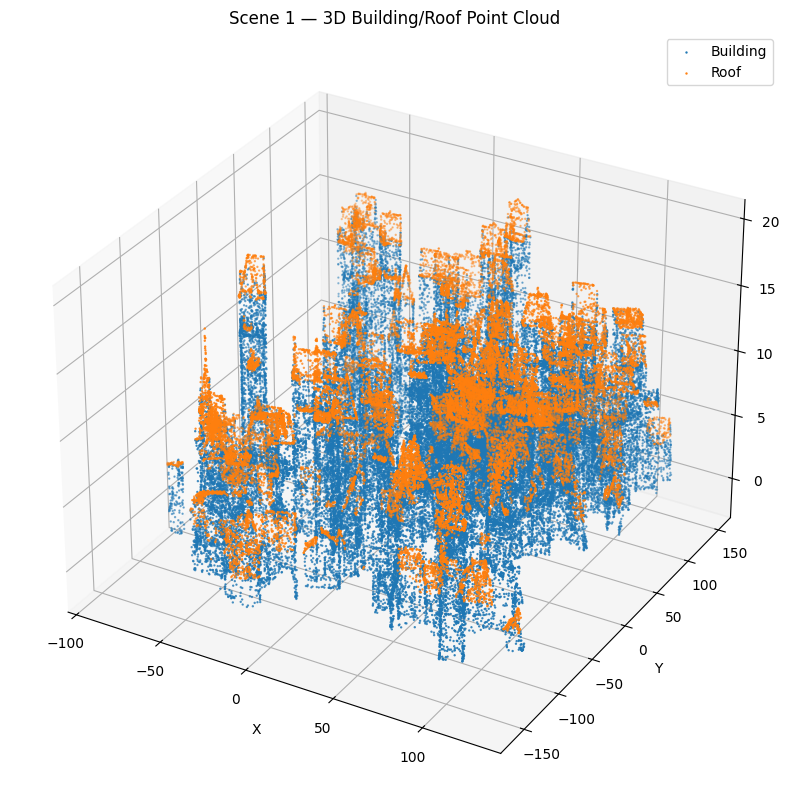

In [ ]:
# ============================================================
# 3D VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(12, 10))

ax = fig.add_subplot(111, projection="3d")

# Subsample only for visualization
N = min(100000, len(points))

rng = np.random.default_rng(42)

idx = rng.choice(
    len(points),
    N,
    replace=False
)

p = points[idx]
l = semantic_label[idx]

# Plot buildings and roofs separately
building = l == 1
roof = l == 2

ax.scatter(
    p[building, 0],
    p[building, 1],
    p[building, 2],
    s=0.5,
    label="Building"
)

ax.scatter(
    p[roof, 0],
    p[roof, 1],
    p[roof, 2],
    s=0.5,
    label="Roof"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Scene 1 — 3D Building/Roof Point Cloud")

ax.legend()

plt.show()

In [ ]:
import numpy as np
from pathlib import Path

processed = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/processed")

for f in sorted(processed.glob("*.npz")):
    data = np.load(f)

    print("=" * 60)
    print(f.name)
    print("=" * 60)

    for key in data.files:
        arr = data[key]
        print(f"{key:15} shape={arr.shape}, dtype={arr.dtype}")

    print()

scene1_points.npz
points          shape=(500000, 3), dtype=float32
building_instance shape=(500000,), dtype=int32
roof_instance   shape=(500000,), dtype=int32
semantic_label  shape=(500000,), dtype=uint8

scene2_points.npz
points          shape=(500000, 3), dtype=float32
building_instance shape=(500000,), dtype=int32
roof_instance   shape=(500000,), dtype=int32
semantic_label  shape=(500000,), dtype=uint8

scene3_points.npz
points          shape=(500000, 3), dtype=float32
building_instance shape=(500000,), dtype=int32
roof_instance   shape=(500000,), dtype=int32
semantic_label  shape=(500000,), dtype=uint8

scene4_points.npz
points          shape=(500000, 3), dtype=float32
building_instance shape=(500000,), dtype=int32
roof_instance   shape=(500000,), dtype=int32
semantic_label  shape=(500000,), dtype=uint8



In [ ]:
import numpy as np
from pathlib import Path

processed = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/processed"
)

for scene in range(1, 5):

    file = processed / f"scene{scene}_points.npz"

    data = np.load(file)

    points = data["points"]
    building_instance = data["building_instance"]
    roof_instance = data["roof_instance"]
    semantic_label = data["semantic_label"]

    print("=" * 70)
    print(f"SCENE {scene}")
    print("=" * 70)

    print("Points:", points.shape)

    print("\nSemantic labels:")
    labels, counts = np.unique(semantic_label, return_counts=True)

    for label, count in zip(labels, counts):
        print(f"  Label {label}: {count:,}")

    print("\nBuilding instances:")
    building_ids = np.unique(building_instance)
    print("  Total unique IDs:", len(building_ids))
    print("  First IDs:", building_ids[:20])

    print("\nRoof instances:")
    roof_ids = np.unique(roof_instance)
    print("  Total unique IDs:", len(roof_ids))
    print("  First IDs:", roof_ids[:20])

SCENE 1
Points: (500000, 3)

Semantic labels:
  Label 1: 340,540
  Label 2: 159,460

Building instances:
  Total unique IDs: 185
  First IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

Roof instances:
  Total unique IDs: 185
  First IDs: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
SCENE 2
Points: (500000, 3)

Semantic labels:
  Label 1: 290,817
  Label 2: 209,183

Building instances:
  Total unique IDs: 119
  First IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

Roof instances:
  Total unique IDs: 120
  First IDs: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
SCENE 3
Points: (500000, 3)

Semantic labels:
  Label 1: 327,975
  Label 2: 172,025

Building instances:
  Total unique IDs: 322
  First IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

Roof instances:
  Total unique IDs: 323
  First IDs: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
SCENE 4
Points: (500000, 3)

Semantic la

In [ ]:
import numpy as np
from pathlib import Path

processed = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/processed"
)

output = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training"
)

output.mkdir(parents=True, exist_ok=True)

# Number of points per training sample
NUM_POINTS = 4096

# Number of samples generated from each scene
SAMPLES_PER_SCENE = 300


def create_samples(scene_id):

    file = processed / f"scene{scene_id}_points.npz"

    data = np.load(file)

    points = data["points"]
    semantic = data["semantic_label"]
    building_instance = data["building_instance"]
    roof_instance = data["roof_instance"]

    print(f"\nScene {scene_id}")
    print("Original points:", len(points))

    samples = []
    labels = []
    buildings = []
    roofs = []

    rng = np.random.default_rng(42 + scene_id)

    for i in range(SAMPLES_PER_SCENE):

        # Randomly choose a center point
        center_idx = rng.integers(0, len(points))
        center = points[center_idx]

        # Calculate distance from center
        distances = np.sum(
            (points - center) ** 2,
            axis=1
        )

        # Select nearest points
        nearest = np.argpartition(
            distances,
            NUM_POINTS
        )[:NUM_POINTS]

        p = points[nearest].copy()

        # Local coordinate normalization
        p -= center

        samples.append(p)
        labels.append(semantic[nearest])
        buildings.append(building_instance[nearest])
        roofs.append(roof_instance[nearest])

    samples = np.asarray(samples, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.uint8)
    buildings = np.asarray(buildings, dtype=np.int32)
    roofs = np.asarray(roofs, dtype=np.int32)

    save_path = output / f"scene{scene_id}_samples.npz"

    np.savez_compressed(
        save_path,
        points=samples,
        semantic_label=labels,
        building_instance=buildings,
        roof_instance=roofs
    )

    print("Created:", samples.shape)
    print("Labels:", labels.shape)
    print("Saved:", save_path)


# Training scenes
for scene in [1, 2, 3]:
    create_samples(scene)

# Validation scene
create_samples(4)

print("\n" + "=" * 70)
print("DATASET CREATION COMPLETE")
print("=" * 70)


Scene 1
Original points: 500000
Created: (300, 4096, 3)
Labels: (300, 4096)
Saved: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training/scene1_samples.npz

Scene 2
Original points: 500000
Created: (300, 4096, 3)
Labels: (300, 4096)
Saved: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training/scene2_samples.npz

Scene 3
Original points: 500000
Created: (300, 4096, 3)
Labels: (300, 4096)
Saved: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training/scene3_samples.npz

Scene 4
Original points: 500000
Created: (300, 4096, 3)
Labels: (300, 4096)
Saved: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training/scene4_samples.npz

DATASET CREATION COMPLETE


In [ ]:
import numpy as np
from pathlib import Path

training = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training"
)

for scene in [1, 2, 3, 4]:

    file = training / f"scene{scene}_samples.npz"

    data = np.load(file)

    print("=" * 60)
    print(f"SCENE {scene}")
    print("=" * 60)

    for key in data.files:
        print(f"{key:20s}", data[key].shape, data[key].dtype)

    print("Semantic labels:",
          np.unique(data["semantic_label"],
                    return_counts=True))


SCENE 1
points               (300, 4096, 3) float32
semantic_label       (300, 4096) uint8
building_instance    (300, 4096) int32
roof_instance        (300, 4096) int32
Semantic labels: (array([1, 2], dtype=uint8), array([863921, 364879]))
SCENE 2
points               (300, 4096, 3) float32
semantic_label       (300, 4096) uint8
building_instance    (300, 4096) int32
roof_instance        (300, 4096) int32
Semantic labels: (array([1, 2], dtype=uint8), array([708263, 520537]))
SCENE 3
points               (300, 4096, 3) float32
semantic_label       (300, 4096) uint8
building_instance    (300, 4096) int32
roof_instance        (300, 4096) int32
Semantic labels: (array([1, 2], dtype=uint8), array([822785, 406015]))
SCENE 4
points               (300, 4096, 3) float32
semantic_label       (300, 4096) uint8
building_instance    (300, 4096) int32
roof_instance        (300, 4096) int32
Semantic labels: (array([1, 2], dtype=uint8), array([802289, 426511]))


In [ ]:
!pip install -q torch-geometric
!pip install -q open3d

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.4 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement open3d (from versions: none)
ERROR: No matching distribution found for open3d


In [ ]:
import torch
import torch_geometric

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch Geometric:", torch_geometric.__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
Torch Geometric: 2.8.0.post1
GPU: Tesla T4


In [ ]:
from pathlib import Path

project = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

(project / "models").mkdir(exist_ok=True)

print("Models directory:")
print(project / "models")

Models directory:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/models


In [ ]:
from pathlib import Path

model_file = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/models/pointnet_model.py"
)

model_file.parent.mkdir(parents=True, exist_ok=True)

model_code = '''
import torch
import torch.nn as nn
import torch.nn.functional as F


class PointNetSegmentation(nn.Module):

    def __init__(self, num_classes=2):
        super().__init__()

        self.conv1 = nn.Conv1d(3, 64, 1)
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(64, 128, 1)
        self.bn2 = nn.BatchNorm1d(128)

        self.conv3 = nn.Conv1d(128, 256, 1)
        self.bn3 = nn.BatchNorm1d(256)

        self.conv4 = nn.Conv1d(256, 512, 1)
        self.bn4 = nn.BatchNorm1d(512)

        self.seg1 = nn.Conv1d(768, 256, 1)
        self.bn_seg1 = nn.BatchNorm1d(256)

        self.seg2 = nn.Conv1d(256, 128, 1)
        self.bn_seg2 = nn.BatchNorm1d(128)

        self.seg3 = nn.Conv1d(128, num_classes, 1)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):

        x1 = F.relu(self.bn1(self.conv1(x)))
        x2 = F.relu(self.bn2(self.conv2(x1)))
        x3 = F.relu(self.bn3(self.conv3(x2)))

        x4 = F.relu(self.bn4(self.conv4(x3)))

        global_feature = torch.max(
            x4,
            dim=2,
            keepdim=True
        )[0]

        global_feature = global_feature.repeat(
            1,
            1,
            x3.shape[2]
        )

        features = torch.cat(
            [x3, global_feature],
            dim=1
        )

        x = F.relu(
            self.bn_seg1(
                self.seg1(features)
            )
        )

        x = self.dropout(x)

        x = F.relu(
            self.bn_seg2(
                self.seg2(x)
            )
        )

        x = self.seg3(x)

        return x
'''

model_file.write_text(model_code)

print("Model saved successfully:")
print(model_file)
print("Exists:", model_file.exists())

Model saved successfully:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/models/pointnet_model.py
Exists: True


In [ ]:
import sys
import torch

sys.path.insert(
    0,
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/models"
)

from pointnet_model import PointNetSegmentation

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = PointNetSegmentation(num_classes=2).to(device)

x = torch.randn(2, 3, 4096).to(device)

with torch.no_grad():
    y = model(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)
print("Device      :", device)

Input shape : torch.Size([2, 3, 4096])
Output shape: torch.Size([2, 2, 4096])
Device      : cuda


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path


class PointCloudDataset(Dataset):

    def __init__(self, files):

        self.samples = []

        for file in files:

            data = np.load(file)

            points = data["points"]
            labels = data["semantic_label"]

            # Convert labels:
            # 1 = building → 0
            # 2 = roof     → 1
            labels = labels - 1

            for i in range(len(points)):

                self.samples.append(
                    (
                        points[i].astype(np.float32),
                        labels[i].astype(np.int64)
                    )
                )

        print("Loaded samples:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        points, labels = self.samples[idx]

        # [4096, 3] → [3, 4096]
        points = torch.from_numpy(points).transpose(0, 1)

        labels = torch.from_numpy(labels)

        return points, labels


training_dir = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training"
)

train_files = [
    training_dir / "scene1_samples.npz",
    training_dir / "scene2_samples.npz",
    training_dir / "scene3_samples.npz"
]

val_files = [
    training_dir / "scene4_samples.npz"
]


train_dataset = PointCloudDataset(train_files)
val_dataset = PointCloudDataset(val_files)


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("\n==============================")
print("DATASET READY")
print("==============================")

print("Training samples  :", len(train_dataset))
print("Validation samples:", len(val_dataset))

points, labels = next(iter(train_loader))

print("\nBatch:")
print("Points:", points.shape)
print("Labels:", labels.shape)
print("Label values:", torch.unique(labels))

Loaded samples: 900
Loaded samples: 300

DATASET READY
Training samples  : 900
Validation samples: 300

Batch:
Points: torch.Size([8, 3, 4096])
Labels: torch.Size([8, 4096])
Label values: tensor([0, 1])


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path

# ============================================================
# IMPORT MODEL
# ============================================================

import sys

sys.path.insert(
    0,
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/models"
)

from pointnet_model import PointNetSegmentation


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# MODEL
# ============================================================

model = PointNetSegmentation(
    num_classes=2
).to(device)

print("\nModel created.")


# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss()


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# ============================================================
# LR SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=15,
    gamma=0.5
)


# ============================================================
# SAVE DIRECTORY
# ============================================================

save_dir = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/models"
)

save_dir.mkdir(
    parents=True,
    exist_ok=True
)

best_model_path = save_dir / "best_3d.pt"


# ============================================================
# METRIC FUNCTION
# ============================================================

def calculate_iou(pred, target, num_classes=2):

    ious = []

    for cls in range(num_classes):

        pred_cls = pred == cls
        target_cls = target == cls

        intersection = (
            pred_cls & target_cls
        ).sum()

        union = (
            pred_cls | target_cls
        ).sum()

        if union == 0:
            iou = float("nan")
        else:
            iou = (
                intersection / union
            ).item()

        ious.append(iou)

    valid_ious = [
        x for x in ious
        if not np.isnan(x)
    ]

    miou = np.mean(valid_ious)

    return ious, miou


# ============================================================
# TRAINING
# ============================================================

EPOCHS = 50

best_miou = -1

history = []


for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    train_loss = 0.0
    train_points = 0

    for points, labels in train_loader:

        points = points.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(points)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += (
            loss.item() * points.size(0)
        )

        train_points += points.size(0)


    train_loss /= train_points


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_loss = 0.0
    val_samples = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():

        for points, labels in val_loader:

            points = points.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(points)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += (
                loss.item() * points.size(0)
            )

            val_samples += points.size(0)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_preds.append(
                predictions.cpu()
            )

            all_targets.append(
                labels.cpu()
            )


    val_loss /= val_samples


    # --------------------------------------------------------
    # IOU
    # --------------------------------------------------------

    all_preds = torch.cat(
        all_preds,
        dim=0
    )

    all_targets = torch.cat(
        all_targets,
        dim=0
    )

    class_iou, miou = calculate_iou(
        all_preds,
        all_targets
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if miou > best_miou:

        best_miou = miou

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_miou": best_miou
            },
            best_model_path
        )

        saved = " ⭐ BEST"


    else:

        saved = ""


    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Building IoU: {class_iou[0]:.4f} | "
        f"Roof IoU: {class_iou[1]:.4f} | "
        f"mIoU: {miou:.4f}"
        f"{saved}"
    )


    history.append(
        {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "building_iou": class_iou[0],
            "roof_iou": class_iou[1],
            "miou": miou
        }
    )


    scheduler.step()


# ============================================================
# SAVE HISTORY
# ============================================================

history_path = save_dir / "training_history.npy"

np.save(
    history_path,
    history,
    allow_pickle=True
)


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print("Best mIoU:", best_miou)

print("\nBest model:")
print(best_model_path)

print("Exists:", best_model_path.exists())

print("\nTraining history:")
print(history_path)

Device: cuda
GPU: Tesla T4

Model created.
Epoch [01/50] Train Loss: 0.5165 | Val Loss: 0.5889 | Building IoU: 0.7004 | Roof IoU: 0.2671 | mIoU: 0.4838 ⭐ BEST
Epoch [02/50] Train Loss: 0.4877 | Val Loss: 0.5229 | Building IoU: 0.7067 | Roof IoU: 0.3876 | mIoU: 0.5471 ⭐ BEST
Epoch [03/50] Train Loss: 0.4740 | Val Loss: 0.5323 | Building IoU: 0.7001 | Roof IoU: 0.3470 | mIoU: 0.5235
Epoch [04/50] Train Loss: 0.4653 | Val Loss: 0.5276 | Building IoU: 0.7229 | Roof IoU: 0.4318 | mIoU: 0.5773 ⭐ BEST
Epoch [05/50] Train Loss: 0.4593 | Val Loss: 0.4797 | Building IoU: 0.7239 | Roof IoU: 0.4744 | mIoU: 0.5991 ⭐ BEST
Epoch [06/50] Train Loss: 0.4521 | Val Loss: 0.5303 | Building IoU: 0.7202 | Roof IoU: 0.4123 | mIoU: 0.5662
Epoch [07/50] Train Loss: 0.4458 | Val Loss: 0.4853 | Building IoU: 0.7305 | Roof IoU: 0.4372 | mIoU: 0.5838
Epoch [08/50] Train Loss: 0.4415 | Val Loss: 0.5038 | Building IoU: 0.7283 | Roof IoU: 0.4233 | mIoU: 0.5758
Epoch [09/50] Train Loss: 0.4412 | Val Loss: 0.4907 | Bui

In [ ]:
import torch
import numpy as np
from pathlib import Path

MODEL_PATH = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/models/best_3d.pt"

print("Loading:", MODEL_PATH)
print("Exists:", Path(MODEL_PATH).exists())

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu",
    weights_only=False
)

print("\nCheckpoint loaded successfully!")
print("Type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Keys:")
    for k in checkpoint.keys():
        print(" -", k)

Loading: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/models/best_3d.pt
Exists: True

Checkpoint loaded successfully!
Type: <class 'dict'>
Keys:
 - epoch
 - model_state_dict
 - optimizer_state_dict
 - best_miou


In [ ]:
if isinstance(checkpoint, dict):
    for key, value in checkpoint.items():
        print(
            f"{key}: "
            f"type={type(value)}, "
            f"shape={getattr(value, 'shape', None)}"
        )

epoch: type=<class 'int'>, shape=None
model_state_dict: type=<class 'collections.OrderedDict'>, shape=None
optimizer_state_dict: type=<class 'dict'>, shape=None
best_miou: type=<class 'numpy.float64'>, shape=()


In [ ]:
import torch
import numpy as np
from pathlib import Path

MODEL_PATH = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/models/best_3d.pt"

print("Model exists:", Path(MODEL_PATH).exists())

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cuda" if torch.cuda.is_available() else "cpu",
    weights_only=False
)

print("Checkpoint loaded successfully!")
print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    print(checkpoint.keys())

Model exists: True
Checkpoint loaded successfully!
Checkpoint type: <class 'dict'>

Checkpoint keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'best_miou'])


In [ ]:
import torch
import numpy as np
from pathlib import Path

# ============================================================
# LOAD BEST MODEL
# ============================================================

MODEL_PATH = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/models/best_3d.pt"
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

print("Best model loaded")
print("Epoch:", checkpoint["epoch"])
print("Saved mIoU:", checkpoint["best_miou"])
print("Device:", device)


# ============================================================
# CONFUSION MATRIX
# Rows    = Ground Truth
# Columns = Prediction
# ============================================================

confusion = np.zeros((2, 2), dtype=np.int64)

total_correct = 0
total_points = 0


# ============================================================
# VALIDATION
# ============================================================

with torch.no_grad():

    for points, labels in val_loader:

        points = points.to(device)
        labels = labels.to(device)

        outputs = model(points)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        pred = predictions.cpu().numpy().flatten()
        true = labels.cpu().numpy().flatten()

        for t, p in zip(true, pred):
            confusion[t, p] += 1


# ============================================================
# METRICS
# ============================================================

print("\n" + "=" * 70)
print("3D MODEL EVALUATION")
print("=" * 70)

print("\nConfusion Matrix:")
print(confusion)

for cls, name in enumerate(["Building", "Roof"]):

    TP = confusion[cls, cls]

    FP = confusion[:, cls].sum() - TP

    FN = confusion[cls, :].sum() - TP

    precision = (
        TP / (TP + FP)
        if (TP + FP) > 0
        else 0
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    iou = (
        TP / (TP + FP + FN)
        if (TP + FP + FN) > 0
        else 0
    )

    total_correct += TP
    total_points += confusion[cls, :].sum()

    print(f"\n{name}")
    print("-" * 30)
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"IoU       : {iou:.4f}")


# ============================================================
# OVERALL
# ============================================================

ious = []

for cls in range(2):

    TP = confusion[cls, cls]
    FP = confusion[:, cls].sum() - TP
    FN = confusion[cls, :].sum() - TP

    iou = TP / (TP + FP + FN)

    ious.append(iou)

miou = np.mean(ious)

accuracy = (
    np.trace(confusion) /
    confusion.sum()
)

print("\n" + "=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Building IoU : {ious[0]:.4f}")
print(f"Roof IoU     : {ious[1]:.4f}")
print(f"mIoU         : {miou:.4f}")

print("=" * 70)

Best model loaded
Epoch: 43
Saved mIoU: 0.6440825164318085
Device: cuda

3D MODEL EVALUATION

Confusion Matrix:
[[679722 122567]
 [122696 303815]]

Building
------------------------------
Precision : 0.8471
Recall    : 0.8472
F1 Score  : 0.8472
IoU       : 0.7348

Roof
------------------------------
Precision : 0.7125
Recall    : 0.7123
F1 Score  : 0.7124
IoU       : 0.5533

FINAL RESULTS
Accuracy : 0.8004
Building IoU : 0.7348
Roof IoU     : 0.5533
mIoU         : 0.6441


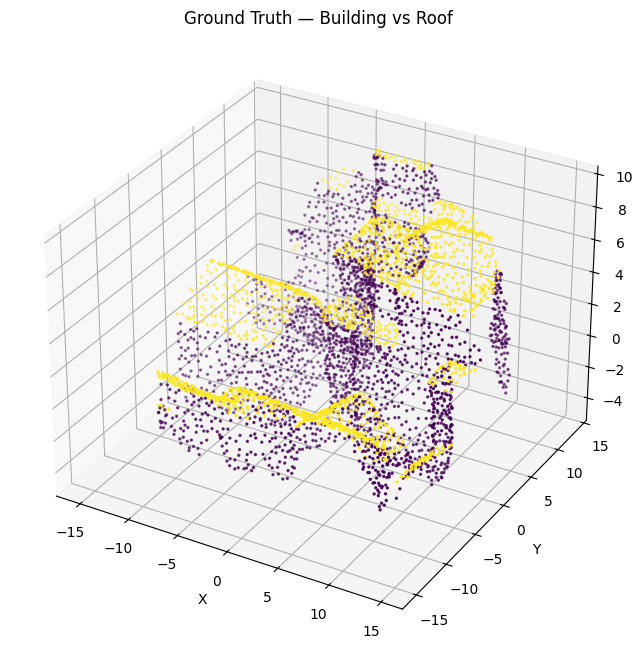

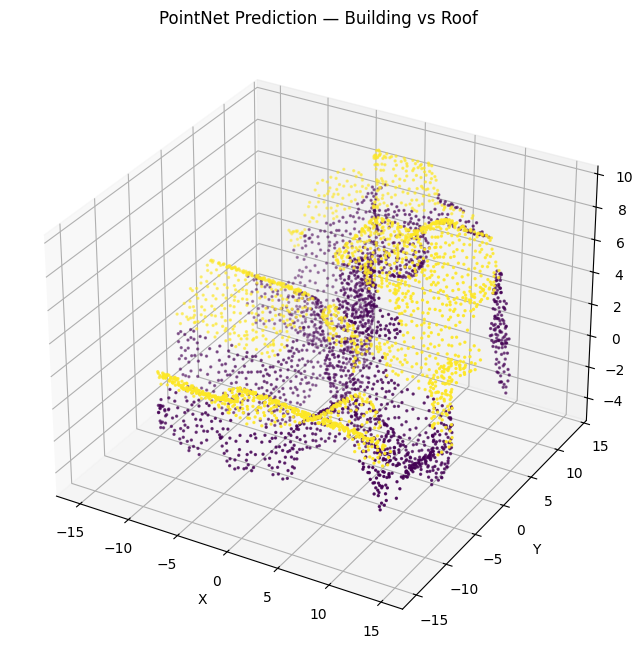

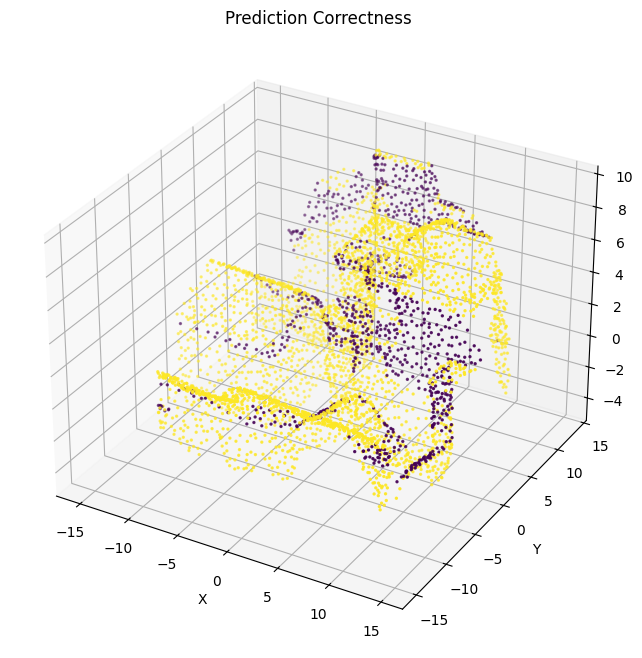

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# GET ONE VALIDATION SAMPLE
# ============================================================

points, labels = val_dataset[0]

# points currently: [3, 4096]
points_input = points.unsqueeze(0).to(device)

# Ground truth
gt = labels.numpy()

# ============================================================
# PREDICTION
# ============================================================

model.eval()

with torch.no_grad():

    output = model(points_input)

    prediction = torch.argmax(
        output,
        dim=1
    )[0].cpu().numpy()

# ============================================================
# CONVERT POINTS
# ============================================================

points_np = points.numpy().T

x = points_np[:, 0]
y = points_np[:, 1]
z = points_np[:, 2]

# ============================================================
# GROUND TRUTH
# ============================================================

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    x,
    y,
    z,
    c=gt,
    s=2
)

ax.set_title(
    "Ground Truth — Building vs Roof"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()


# ============================================================
# PREDICTION
# ============================================================

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    x,
    y,
    z,
    c=prediction,
    s=2
)

ax.set_title(
    "PointNet Prediction — Building vs Roof"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()


# ============================================================
# ERROR MAP
# ============================================================

correct = prediction == gt

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    x,
    y,
    z,
    c=correct,
    s=2
)

ax.set_title(
    "Prediction Correctness"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [ ]:
import numpy as np
from pathlib import Path

TRAIN_DIR = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training"
)

print("=" * 70)
print("CHECKING TRAINING FILE KEYS")
print("=" * 70)

for scene in range(1, 5):

    path = TRAIN_DIR / f"scene{scene}_samples.npz"

    print(f"\nScene {scene}")
    print("File:", path)
    print("Exists:", path.exists())

    if path.exists():

        data = np.load(path)

        print("Keys:", data.files)

        for key in data.files:
            print(
                f"  {key}: "
                f"shape={data[key].shape}, "
                f"dtype={data[key].dtype}"
            )

        data.close()

CHECKING TRAINING FILE KEYS

Scene 1
File: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training/scene1_samples.npz
Exists: True
Keys: ['points', 'semantic_label', 'building_instance', 'roof_instance']
  points: shape=(300, 4096, 3), dtype=float32
  semantic_label: shape=(300, 4096), dtype=uint8
  building_instance: shape=(300, 4096), dtype=int32
  roof_instance: shape=(300, 4096), dtype=int32

Scene 2
File: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training/scene2_samples.npz
Exists: True
Keys: ['points', 'semantic_label', 'building_instance', 'roof_instance']
  points: shape=(300, 4096, 3), dtype=float32
  semantic_label: shape=(300, 4096), dtype=uint8
  building_instance: shape=(300, 4096), dtype=int32
  roof_instance: shape=(300, 4096), dtype=int32

Scene 3
File: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training/scene3_samples.npz
Exists: True
Keys: ['points', 'semantic_label', 'building_instance', 'roof_instance']
  points: shape=(300, 4096, 3), dtype=f

In [ ]:
import numpy as np
from pathlib import Path

TRAIN_DIR = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training"
)

print("=" * 70)
print("TRAINING CLASS DISTRIBUTION")
print("=" * 70)

total_points = 0
building_points = 0
roof_points = 0

for scene in range(1, 5):

    path = TRAIN_DIR / f"scene{scene}_samples.npz"

    data = np.load(path)

    labels = data["semantic_label"]

    building = np.sum(labels == 0)
    roof = np.sum(labels == 1)
    total = labels.size

    print(f"\nScene {scene}")
    print("-" * 40)

    print(f"Total points : {total:,}")
    print(
        f"Building     : {building:,} "
        f"({building / total * 100:.2f}%)"
    )
    print(
        f"Roof         : {roof:,} "
        f"({roof / total * 100:.2f}%)"
    )

    total_points += total
    building_points += building
    roof_points += roof

    data.close()


print("\n" + "=" * 70)
print("OVERALL TRAINING DISTRIBUTION")
print("=" * 70)

print(f"Total points : {total_points:,}")
print(
    f"Building     : {building_points:,} "
    f"({building_points / total_points * 100:.2f}%)"
)
print(
    f"Roof         : {roof_points:,} "
    f"({roof_points / total_points * 100:.2f}%)"
)

print("=" * 70)

TRAINING CLASS DISTRIBUTION

Scene 1
----------------------------------------
Total points : 1,228,800
Building     : 0 (0.00%)
Roof         : 863,921 (70.31%)

Scene 2
----------------------------------------
Total points : 1,228,800
Building     : 0 (0.00%)
Roof         : 708,263 (57.64%)

Scene 3
----------------------------------------
Total points : 1,228,800
Building     : 0 (0.00%)
Roof         : 822,785 (66.96%)

Scene 4
----------------------------------------
Total points : 1,228,800
Building     : 0 (0.00%)
Roof         : 802,289 (65.29%)

OVERALL TRAINING DISTRIBUTION
Total points : 4,915,200
Building     : 0 (0.00%)
Roof         : 3,197,258 (65.05%)


In [ ]:
import numpy as np
from pathlib import Path

TRAIN_DIR = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training"
)

print("=" * 70)
print("ACTUAL SEMANTIC LABEL VALUES")
print("=" * 70)

for scene in range(1, 5):

    path = TRAIN_DIR / f"scene{scene}_samples.npz"

    data = np.load(path)

    labels = data["semantic_label"]

    unique, counts = np.unique(labels, return_counts=True)

    print(f"\nScene {scene}")

    for label, count in zip(unique, counts):

        print(
            f"Label {label}: "
            f"{count:,} "
            f"({count / labels.size * 100:.2f}%)"
        )

    data.close()

ACTUAL SEMANTIC LABEL VALUES

Scene 1
Label 1: 863,921 (70.31%)
Label 2: 364,879 (29.69%)

Scene 2
Label 1: 708,263 (57.64%)
Label 2: 520,537 (42.36%)

Scene 3
Label 1: 822,785 (66.96%)
Label 2: 406,015 (33.04%)

Scene 4
Label 1: 802,289 (65.29%)
Label 2: 426,511 (34.71%)


In [ ]:
# Inspect one sample from the Dataset

points, labels = train_dataset[0]

print("=" * 60)
print("DATASET LABEL VERIFICATION")
print("=" * 60)

print("Points shape:", points.shape)
print("Labels shape:", labels.shape)

unique, counts = torch.unique(
    labels,
    return_counts=True
)

print("\nLabels returned by train_dataset:")

for label, count in zip(unique, counts):
    print(
        f"Model label {label.item()}: "
        f"{count.item():,} points"
    )

print("\nExpected:")
print("0 = Building")
print("1 = Roof")

DATASET LABEL VERIFICATION
Points shape: torch.Size([3, 4096])
Labels shape: torch.Size([4096])

Labels returned by train_dataset:
Model label 0: 2,592 points
Model label 1: 1,504 points

Expected:
0 = Building
1 = Roof


In [ ]:
import numpy as np
import torch
from pathlib import Path

# --------------------------------------------------
# PATHS
# --------------------------------------------------

MODEL_PATH = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/models/best_3d.pt"
)

DATA_PATH = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training/scene1_samples.npz"
)

OUTPUT_PATH = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/predictions"
)

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# LOAD MODEL
# --------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

model = PointNetSegmentation(num_classes=2).to(device)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Model loaded")
print("Device:", device)

# --------------------------------------------------
# LOAD SCENE
# --------------------------------------------------

data = np.load(DATA_PATH)

points = data["points"]
ground_truth = data["semantic_label"]

print("\nScene loaded")
print("Points:", points.shape)
print("Ground truth:", ground_truth.shape)

# --------------------------------------------------
# CONVERT LABELS
# Original:
# 1 = Building
# 2 = Roof
#
# Model:
# 0 = Building
# 1 = Roof
# --------------------------------------------------

ground_truth = ground_truth - 1

# --------------------------------------------------
# PREDICTION
# --------------------------------------------------

all_predictions = []

with torch.no_grad():

    for i in range(len(points)):

        sample = torch.tensor(
            points[i],
            dtype=torch.float32
        )

        sample = sample.transpose(0, 1)
        sample = sample.unsqueeze(0).to(device)

        output = model(sample)

        prediction = torch.argmax(
            output,
            dim=1
        )

        prediction = prediction.squeeze(0).cpu().numpy()

        all_predictions.append(prediction)

predictions = np.array(all_predictions)

print("\nPrediction complete")
print("Predictions:", predictions.shape)

# --------------------------------------------------
# SAVE
# --------------------------------------------------

save_path = OUTPUT_PATH / "scene1_predictions.npz"

np.savez_compressed(
    save_path,
    points=points,
    ground_truth=ground_truth,
    predictions=predictions
)

print("\nSaved:")
print(save_path)

# --------------------------------------------------
# DISTRIBUTION
# --------------------------------------------------

unique, counts = np.unique(
    predictions,
    return_counts=True
)

print("\nPrediction distribution")

for label, count in zip(unique, counts):

    name = "Building" if label == 0 else "Roof"

    print(
        f"{name}: {count:,} "
        f"({count / predictions.size * 100:.2f}%)"
    )

Model loaded
Device: cuda

Scene loaded
Points: (300, 4096, 3)
Ground truth: (300, 4096)

Prediction complete
Predictions: (300, 4096)

Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/predictions/scene1_predictions.npz

Prediction distribution
Building: 805,589 (65.56%)
Roof: 423,211 (34.44%)


Points: (1228800, 3)
Predictions: (1228800,)


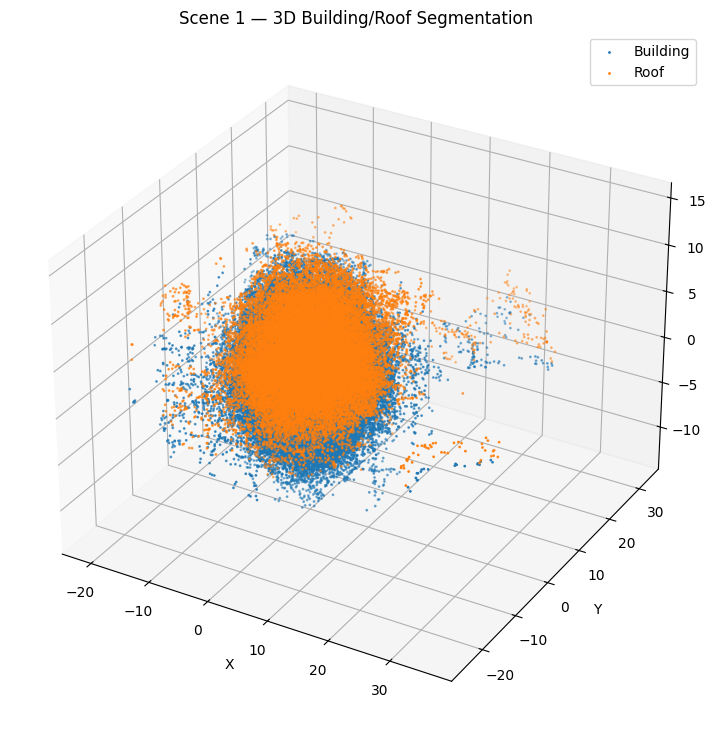

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

path = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/predictions/scene1_predictions.npz"

data = np.load(path)

points = data["points"].reshape(-1, 3)
predictions = data["predictions"].reshape(-1)

print("Points:", points.shape)
print("Predictions:", predictions.shape)

# Limit points for faster visualization
N = min(100000, len(points))

idx = np.random.choice(
    len(points),
    N,
    replace=False
)

p = points[idx]
y = predictions[idx]

# --------------------------------------------------
# 3D PREDICTION
# --------------------------------------------------

fig = plt.figure(figsize=(12, 9))

ax = fig.add_subplot(111, projection="3d")

building = y == 0
roof = y == 1

ax.scatter(
    p[building, 0],
    p[building, 1],
    p[building, 2],
    s=1,
    label="Building"
)

ax.scatter(
    p[roof, 0],
    p[roof, 1],
    p[roof, 2],
    s=1,
    label="Roof"
)

ax.set_title("Scene 1 — 3D Building/Roof Segmentation")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.legend()

plt.show()

In [ ]:
import numpy as np
from pathlib import Path

DATA_PATH = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training/scene1_samples.npz"
)

data = np.load(DATA_PATH)

points = data["points"].reshape(-1, 3)
semantic = data["semantic_label"].reshape(-1)
building_ids = data["building_instance"].reshape(-1)
roof_ids = data["roof_instance"].reshape(-1)

print("=" * 70)
print("3D INSTANCE EXTRACTION — SCENE 1")
print("=" * 70)

print("Points:", points.shape)

# --------------------------------------------------
# BUILDING INSTANCE IDs
# --------------------------------------------------

valid_buildings = building_ids[building_ids >= 0]

unique_buildings = np.unique(valid_buildings)

print("\nBuilding instances:", len(unique_buildings))

# --------------------------------------------------
# CALCULATE PROPERTIES
# --------------------------------------------------

building_stats = []

for building_id in unique_buildings:

    mask = building_ids == building_id

    pts = points[mask]

    if len(pts) < 20:
        continue

    x_min, y_min, z_min = pts.min(axis=0)
    x_max, y_max, z_max = pts.max(axis=0)

    width = x_max - x_min
    depth = y_max - y_min
    height = z_max - z_min

    # Ground footprint approximation
    footprint_area = width * depth

    # Bounding-box volume
    volume = footprint_area * height

    building_stats.append({
        "building_id": int(building_id),
        "points": len(pts),
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max,
        "z_min": z_min,
        "z_max": z_max,
        "width": width,
        "depth": depth,
        "height": height,
        "footprint_area": footprint_area,
        "volume": volume
    })

print("\nBuildings extracted:", len(building_stats))

# --------------------------------------------------
# SHOW FIRST 10
# --------------------------------------------------

print("\n" + "=" * 70)
print("FIRST 10 BUILDINGS")
print("=" * 70)

for b in building_stats[:10]:

    print(
        f"ID {b['building_id']:3d} | "
        f"Points: {b['points']:6d} | "
        f"Width: {b['width']:7.2f} | "
        f"Depth: {b['depth']:7.2f} | "
        f"Height: {b['height']:7.2f} | "
        f"Footprint: {b['footprint_area']:9.2f}"
    )

3D INSTANCE EXTRACTION — SCENE 1
Points: (1228800, 3)

Building instances: 182

Buildings extracted: 182

FIRST 10 BUILDINGS
ID   0 | Points:   3312 | Width:   16.56 | Depth:   24.02 | Height:   12.45 | Footprint:    397.75
ID   1 | Points:   1381 | Width:   19.68 | Depth:   21.98 | Height:    9.60 | Footprint:    432.63
ID   2 | Points:  15208 | Width:   30.74 | Depth:   37.48 | Height:   15.84 | Footprint:   1152.24
ID   3 | Points:   4354 | Width:   26.24 | Depth:   32.11 | Height:    7.11 | Footprint:    842.44
ID   4 | Points:   1663 | Width:   20.59 | Depth:   21.98 | Height:   10.79 | Footprint:    452.66
ID   5 | Points:   3099 | Width:   35.01 | Depth:   36.62 | Height:    6.39 | Footprint:   1282.22
ID   6 | Points:   3160 | Width:   34.81 | Depth:   40.26 | Height:    6.99 | Footprint:   1401.37
ID   7 | Points:    907 | Width:   21.37 | Depth:   13.35 | Height:    7.06 | Footprint:    285.41
ID   8 | Points:   8243 | Width:   20.48 | Depth:   23.69 | Height:   12.99 | Footp

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.DataFrame(building_stats)

csv_path = OUTPUT_DIR / "scene1_building_inventory.csv"

df.to_csv(csv_path, index=False)

print("=" * 70)
print("3D BUILDING INVENTORY SAVED")
print("=" * 70)

print("Buildings:", len(df))
print("Columns:", list(df.columns))

print("\nSaved:")
print(csv_path)

print("\nSummary:")
print(df[[
    "height",
    "footprint_area",
    "volume"
]].describe())

3D BUILDING INVENTORY SAVED
Buildings: 182
Columns: ['building_id', 'points', 'x_min', 'x_max', 'y_min', 'y_max', 'z_min', 'z_max', 'width', 'depth', 'height', 'footprint_area', 'volume']

Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene1_building_inventory.csv

Summary:
           height  footprint_area        volume
count  182.000000      182.000000    182.000000
mean    13.312120      435.359711   6251.773926
std      5.661041      291.233185   4940.217773
min      2.878173       29.835772    145.351974
25%      8.926793      249.079468   2303.108704
50%     12.629317      407.877182   5179.998535
75%     18.110375      517.050529   8683.651611
max     25.464909     2411.270508  25114.332031


In [ ]:
# ============================================================
# STEP 22 — 3D BUILDING FOOTPRINT POLYGONS
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial import ConvexHull
import json

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

DATA_PATH = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/training/scene1_samples.npz"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

data = np.load(DATA_PATH)

points = data["points"].reshape(-1, 3)
building_ids = data["building_instance"].reshape(-1)

print("=" * 70)
print("3D BUILDING FOOTPRINT EXTRACTION")
print("=" * 70)

print("Points:", points.shape)

# ------------------------------------------------------------
# GET BUILDING IDs
# ------------------------------------------------------------

valid_ids = building_ids[building_ids >= 0]
unique_ids = np.unique(valid_ids)

print("Building instances:", len(unique_ids))

# ------------------------------------------------------------
# EXTRACT FOOTPRINTS
# ------------------------------------------------------------

footprints = []

for building_id in unique_ids:

    mask = building_ids == building_id

    pts = points[mask]

    # Need enough points for a polygon
    if len(pts) < 3:
        continue

    # Project 3D points onto XY plane
    xy = pts[:, :2]

    # Remove duplicate XY points
    xy = np.unique(xy, axis=0)

    if len(xy) < 3:
        continue

    try:

        hull = ConvexHull(xy)

        polygon = xy[hull.vertices]

        # Close polygon
        polygon_closed = np.vstack([
            polygon,
            polygon[0]
        ])

        # Shoelace area
        x = polygon[:, 0]
        y = polygon[:, 1]

        area = 0.5 * abs(
            np.sum(
                x * np.roll(y, -1)
                -
                y * np.roll(x, -1)
            )
        )

        # Height
        z_min = pts[:, 2].min()
        z_max = pts[:, 2].max()

        height = z_max - z_min

        footprints.append({
            "building_id": int(building_id),
            "num_points": int(len(pts)),
            "height": float(height),
            "footprint_area": float(area),
            "z_min": float(z_min),
            "z_max": float(z_max),
            "polygon_xy": polygon_closed.tolist()
        })

    except Exception as e:

        print(
            f"Skipping building {building_id}: {e}"
        )

# ------------------------------------------------------------
# SAVE JSON
# ------------------------------------------------------------

json_path = OUTPUT_DIR / "scene1_building_footprints.json"

with open(json_path, "w") as f:
    json.dump(
        footprints,
        f,
        indent=2
    )

# ------------------------------------------------------------
# SAVE CSV WITHOUT POLYGON
# ------------------------------------------------------------

table = []

for b in footprints:

    table.append({
        "building_id": b["building_id"],
        "num_points": b["num_points"],
        "height": b["height"],
        "footprint_area": b["footprint_area"],
        "z_min": b["z_min"],
        "z_max": b["z_max"]
    })

df = pd.DataFrame(table)

csv_path = OUTPUT_DIR / "scene1_building_footprints.csv"

df.to_csv(
    csv_path,
    index=False
)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RESULT")
print("=" * 70)

print("Footprints created:", len(footprints))

print("\nFirst 10 buildings:")

for b in footprints[:10]:

    print(
        f"ID {b['building_id']:3d} | "
        f"Points: {b['num_points']:6d} | "
        f"Height: {b['height']:7.2f} | "
        f"Area: {b['footprint_area']:9.2f} | "
        f"Polygon vertices: {len(b['polygon_xy']) - 1}"
    )

print("\nSaved JSON:")
print(json_path)

print("\nSaved CSV:")
print(csv_path)

print("\n" + "=" * 70)
print("STEP 22 COMPLETE")
print("=" * 70)

3D BUILDING FOOTPRINT EXTRACTION
Points: (1228800, 3)
Building instances: 182

RESULT
Footprints created: 182

First 10 buildings:
ID   0 | Points:   3312 | Height:   12.45 | Area:    269.14 | Polygon vertices: 19
ID   1 | Points:   1381 | Height:    9.60 | Area:    245.84 | Polygon vertices: 19
ID   2 | Points:  15208 | Height:   15.84 | Area:    816.06 | Polygon vertices: 31
ID   3 | Points:   4354 | Height:    7.11 | Area:    601.94 | Polygon vertices: 25
ID   4 | Points:   1663 | Height:   10.79 | Area:    272.67 | Polygon vertices: 25
ID   5 | Points:   3099 | Height:    6.39 | Area:    684.70 | Polygon vertices: 25
ID   6 | Points:   3160 | Height:    6.99 | Area:    742.01 | Polygon vertices: 24
ID   7 | Points:    907 | Height:    7.06 | Area:    175.91 | Polygon vertices: 17
ID   8 | Points:   8243 | Height:   12.99 | Area:    369.58 | Polygon vertices: 30
ID   9 | Points:   1510 | Height:   10.89 | Area:    426.52 | Polygon vertices: 21

Saved JSON:
/content/drive/MyDrive/SIH

3D BUILDING FOOTPRINT VISUALIZATION
Buildings: 182


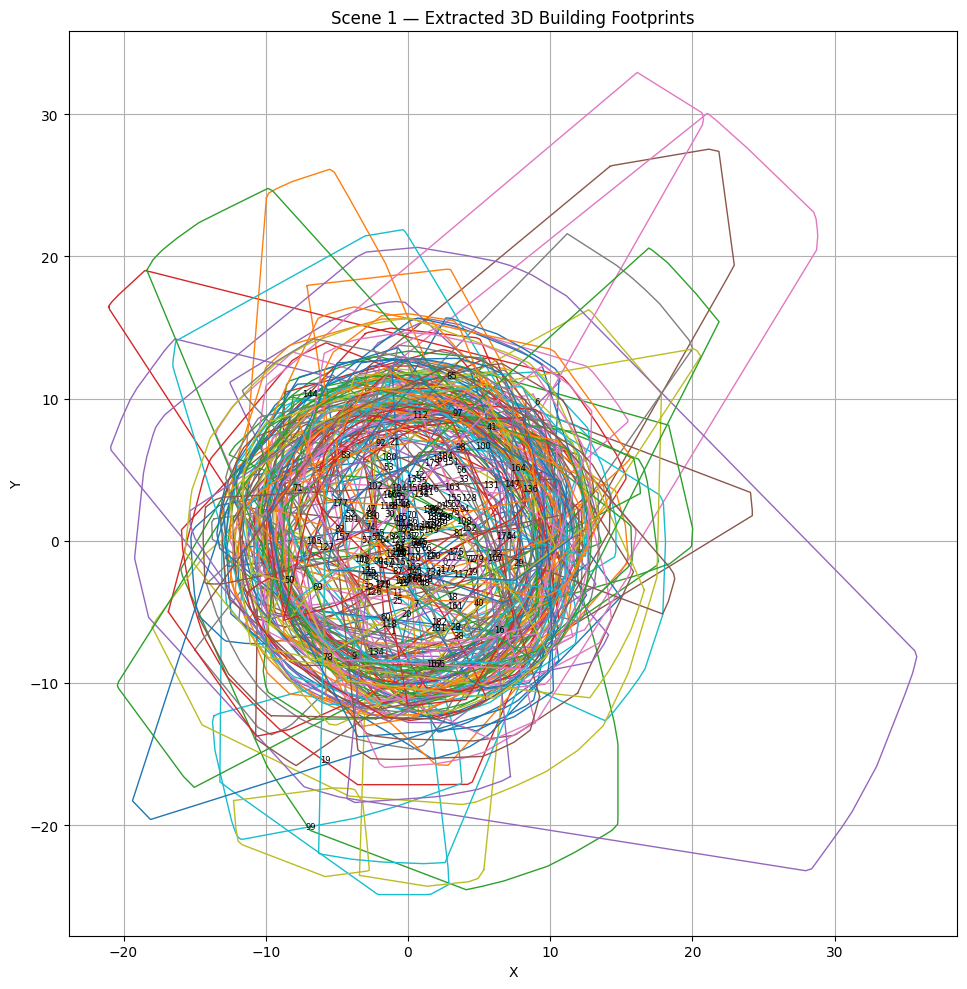


Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene1_building_footprints.png


In [ ]:
# ============================================================
# STEP 23 — VISUALIZE 3D BUILDING FOOTPRINTS
# ============================================================

import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

JSON_PATH = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/"
    "scene1_building_footprints.json"
)

# ------------------------------------------------------------
# LOAD FOOTPRINTS
# ------------------------------------------------------------

with open(JSON_PATH, "r") as f:
    footprints = json.load(f)

print("=" * 70)
print("3D BUILDING FOOTPRINT VISUALIZATION")
print("=" * 70)

print("Buildings:", len(footprints))

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 10))

for building in footprints:

    polygon = np.array(building["polygon_xy"])

    x = polygon[:, 0]
    y = polygon[:, 1]

    ax.plot(
        x,
        y,
        linewidth=1
    )

    # Building ID at centroid
    centroid_x = np.mean(x[:-1])
    centroid_y = np.mean(y[:-1])

    ax.text(
        centroid_x,
        centroid_y,
        str(building["building_id"]),
        fontsize=6,
        ha="center",
        va="center"
    )

ax.set_title(
    "Scene 1 — Extracted 3D Building Footprints"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_aspect("equal")

ax.grid(True)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

output_path = (
    "/content/drive/MyDrive/SIH 2026/"
    "InstanceBuilding_3D/outputs/"
    "scene1_building_footprints.png"
)

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(output_path)

In [ ]:
# ============================================================
# STEP 23 — CORRECT 3D BUILDING FOOTPRINT EXTRACTION
# Use ORIGINAL scene points, NOT training samples
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from pathlib import Path
import json

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

DATA_PATH = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/processed/"
    "scene1_points.npz"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD ORIGINAL SCENE
# ------------------------------------------------------------

data = np.load(DATA_PATH)

points = data["points"]
building_ids = data["building_instance"]

print("=" * 70)
print("CORRECT 3D BUILDING FOOTPRINT EXTRACTION")
print("=" * 70)

print("Points:", points.shape)
print("Building IDs:", building_ids.shape)

# ------------------------------------------------------------
# VALID BUILDINGS
# ------------------------------------------------------------

valid = building_ids >= 0

points = points[valid]
building_ids = building_ids[valid]

unique_ids = np.unique(building_ids)

print("Building instances:", len(unique_ids))

# ------------------------------------------------------------
# EXTRACT FOOTPRINTS
# ------------------------------------------------------------

footprints = []

for building_id in unique_ids:

    mask = building_ids == building_id

    pts = points[mask]

    if len(pts) < 20:
        continue

    # --------------------------------------------------------
    # XY PROJECTION
    # --------------------------------------------------------

    xy = pts[:, :2]

    xy = np.unique(xy, axis=0)

    if len(xy) < 3:
        continue

    try:

        hull = ConvexHull(xy)

        polygon = xy[hull.vertices]

        # Close polygon
        polygon_closed = np.vstack([
            polygon,
            polygon[0]
        ])

        # ----------------------------------------------------
        # AREA
        # ----------------------------------------------------

        x = polygon[:, 0]
        y = polygon[:, 1]

        area = 0.5 * abs(
            np.sum(
                x * np.roll(y, -1)
                -
                y * np.roll(x, -1)
            )
        )

        # ----------------------------------------------------
        # HEIGHT
        # ----------------------------------------------------

        z_min = pts[:, 2].min()
        z_max = pts[:, 2].max()

        height = z_max - z_min

        # ----------------------------------------------------
        # CENTROID
        # ----------------------------------------------------

        centroid_x = np.mean(xy[:, 0])
        centroid_y = np.mean(xy[:, 1])

        footprints.append({

            "building_id": int(building_id),

            "num_points": int(len(pts)),

            "height": float(height),

            "footprint_area": float(area),

            "z_min": float(z_min),

            "z_max": float(z_max),

            "centroid_x": float(centroid_x),

            "centroid_y": float(centroid_y),

            "polygon_xy": polygon_closed.tolist()
        })

    except Exception as e:

        print(
            f"Building {building_id} skipped: {e}"
        )

# ------------------------------------------------------------
# SAVE JSON
# ------------------------------------------------------------

json_path = (
    OUTPUT_DIR /
    "scene1_building_footprints_corrected.json"
)

with open(json_path, "w") as f:

    json.dump(
        footprints,
        f,
        indent=2
    )

# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

rows = []

for b in footprints:

    rows.append({

        "building_id": b["building_id"],

        "num_points": b["num_points"],

        "height": b["height"],

        "footprint_area": b["footprint_area"],

        "z_min": b["z_min"],

        "z_max": b["z_max"],

        "centroid_x": b["centroid_x"],

        "centroid_y": b["centroid_y"]
    })

df = pd.DataFrame(rows)

csv_path = (
    OUTPUT_DIR /
    "scene1_building_footprints_corrected.csv"
)

df.to_csv(
    csv_path,
    index=False
)

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RESULT")
print("=" * 70)

print(
    "Valid building footprints:",
    len(footprints)
)

print("\nFirst 10:")

for b in footprints[:10]:

    print(
        f"ID {b['building_id']:3d} | "
        f"Points: {b['num_points']:6d} | "
        f"Height: {b['height']:7.2f} | "
        f"Area: {b['footprint_area']:9.2f} | "
        f"Vertices: {len(b['polygon_xy']) - 1}"
    )

print("\nSaved:")
print(json_path)

print(csv_path)

CORRECT 3D BUILDING FOOTPRINT EXTRACTION
Points: (500000, 3)
Building IDs: (500000,)
Building instances: 185

RESULT
Valid building footprints: 185

First 10:
ID   0 | Points:   1558 | Height:    5.53 | Area:    102.72 | Vertices: 32
ID   1 | Points:   1013 | Height:    4.28 | Area:     72.27 | Vertices: 16
ID   2 | Points:   4263 | Height:    9.23 | Area:    427.03 | Vertices: 29
ID   3 | Points:   2197 | Height:    5.39 | Area:    180.97 | Vertices: 29
ID   4 | Points:   1481 | Height:    4.98 | Area:    148.35 | Vertices: 18
ID   5 | Points:   1033 | Height:    5.56 | Area:     75.97 | Vertices: 22
ID   6 | Points:   1176 | Height:    5.24 | Area:     90.38 | Vertices: 26
ID   7 | Points:    885 | Height:    4.52 | Area:     98.77 | Vertices: 25
ID   8 | Points:   1276 | Height:    4.87 | Area:    117.83 | Vertices: 28
ID   9 | Points:    446 | Height:    3.30 | Area:     51.71 | Vertices: 16

Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene1_building_footpri

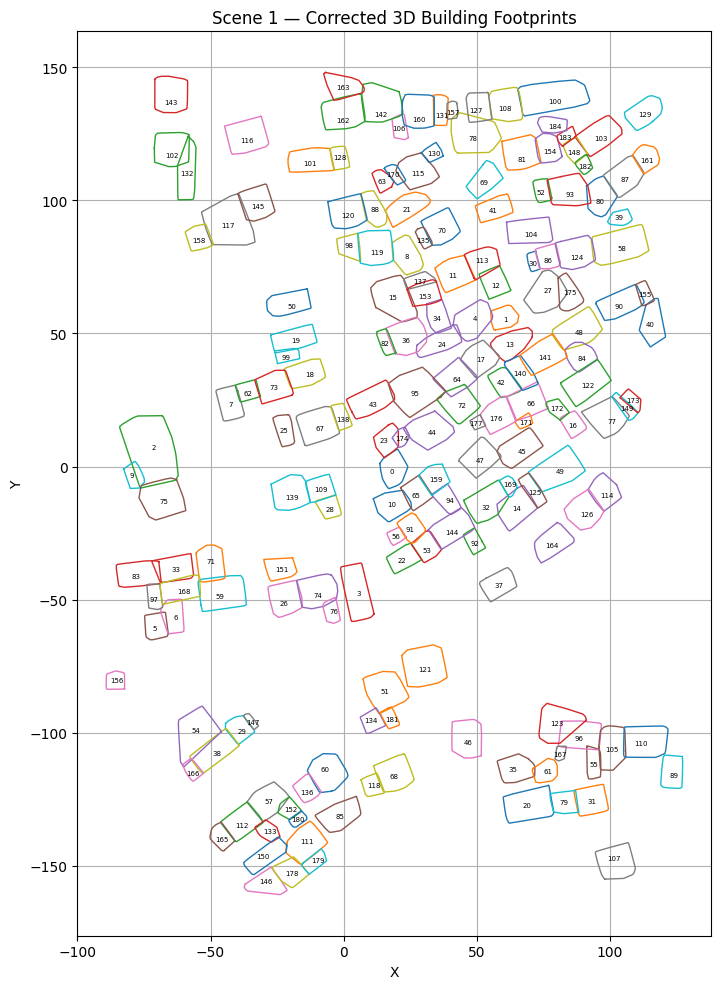

Saved: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene1_corrected_footprints.png


In [ ]:
# ============================================================
# STEP 24 — VISUALIZE CORRECTED FOOTPRINTS
# ============================================================

import json
import numpy as np
import matplotlib.pyplot as plt

JSON_PATH = (
    "/content/drive/MyDrive/SIH 2026/"
    "InstanceBuilding_3D/outputs/"
    "scene1_building_footprints_corrected.json"
)

with open(JSON_PATH, "r") as f:
    footprints = json.load(f)

fig, ax = plt.subplots(figsize=(12, 10))

for b in footprints:

    polygon = np.array(
        b["polygon_xy"]
    )

    ax.plot(
        polygon[:, 0],
        polygon[:, 1],
        linewidth=1
    )

    # ID
    ax.text(
        b["centroid_x"],
        b["centroid_y"],
        str(b["building_id"]),
        fontsize=5,
        ha="center",
        va="center"
    )

ax.set_title(
    "Scene 1 — Corrected 3D Building Footprints"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_aspect("equal")

ax.grid(True)

plt.tight_layout()

output = (
    "/content/drive/MyDrive/SIH 2026/"
    "InstanceBuilding_3D/outputs/"
    "scene1_corrected_footprints.png"
)

plt.savefig(
    output,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output)

In [ ]:
# ============================================================
# STEP 25 — BUILDING GEOMETRY & 3D ATTRIBUTES
# ============================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path

BASE = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

INPUT = BASE / "outputs/scene1_building_footprints_corrected.json"

OUTPUT = BASE / "outputs/scene1_building_geometry.csv"

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

with open(INPUT, "r") as f:
    buildings = json.load(f)

print("=" * 70)
print("BUILDING GEOMETRY EXTRACTION")
print("=" * 70)

print("Buildings:", len(buildings))

results = []

for b in buildings:

    polygon = np.array(b["polygon_xy"])

    x = polygon[:, 0]
    y = polygon[:, 1]

    # Bounding box
    width = x.max() - x.min()
    depth = y.max() - y.min()

    # Footprint area
    area = b["footprint_area"]

    # Height
    height = b["height"]

    # Approximate volume
    volume = area * height

    results.append({
        "building_id": b["building_id"],
        "points": b["num_points"],
        "footprint_area_m2": area,
        "width_m": width,
        "depth_m": depth,
        "height_m": height,
        "volume_m3": volume,
        "centroid_x": b["centroid_x"],
        "centroid_y": b["centroid_y"],
        "z_min": b["z_min"],
        "z_max": b["z_max"]
    })

df = pd.DataFrame(results)

# ------------------------------------------------------------
# SORT BY BUILDING ID
# ------------------------------------------------------------

df = df.sort_values("building_id")

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

df.to_csv(
    OUTPUT,
    index=False
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("\nFirst 15 buildings:")
display(df.head(15))

print("\nStatistics:")
display(
    df[
        [
            "footprint_area_m2",
            "height_m",
            "volume_m3"
        ]
    ].describe()
)

print("\nSaved:")
print(OUTPUT)

BUILDING GEOMETRY EXTRACTION
Buildings: 185

First 15 buildings:


,building_id,points,footprint_area_m2,width_m,depth_m,height_m,volume_m3,centroid_x,centroid_y,z_min,z_max
0,0,1558,102.719315,10.476085,14.835524,5.525206,567.545333,18.041080,-1.756996,-0.390328,5.134878
1,1,1013,72.268677,10.535816,9.278015,4.280601,309.353337,60.609261,55.507927,0.889136,5.169736
2,2,4263,427.033447,22.001217,27.219183,9.227685,3940.530125,-71.296349,7.191072,-0.833789,8.393896
3,3,2197,180.969666,12.558764,21.876492,5.386900,974.865482,5.464813,-47.448196,-0.748567,4.638333
4,4,1481,148.349182,14.887245,15.617722,4.982471,739.145567,49.196922,55.886669,0.589989,5.572460
5,5,1033,75.968506,8.902534,10.372112,5.560629,422.432705,-71.132744,-60.459789,-0.310586,5.250043
6,6,1176,90.381104,8.694920,12.979050,5.236463,473.277311,-62.986515,-56.649734,-0.180790,5.055673
7,7,885,98.768219,10.623795,13.354206,4.523369,446.765084,-42.467178,23.554710,-1.001875,3.521494
8,8,1276,117.828674,11.765762,14.825455,4.869121,573.722081,23.642773,79.213181,0.193845,5.062966
9,9,446,51.710556,7.765709,10.072623,3.302372,170.767491,-79.619095,-3.214851,-0.165815,3.136557



Statistics:


,footprint_area_m2,height_m,volume_m3
count,185.000000,185.000000,185.000000
mean,108.979445,8.535134,1095.937241
std,58.954443,4.716009,967.475660
min,15.062134,2.650558,52.248644
25%,59.456787,4.869121,313.321611
50%,111.784538,6.118693,698.391763
75%,145.679688,12.913630,1895.107784
max,427.033447,19.807713,4068.366655



Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene1_building_geometry.csv


In [ ]:
# ============================================================
# STEP 26 — ROOF GEOMETRY PER BUILDING
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

BASE = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

DATA_PATH = BASE / "processed/scene1_points.npz"

OUTPUT_PATH = BASE / "outputs/scene1_roof_geometry.csv"

# ------------------------------------------------------------
# LOAD ORIGINAL 3D DATA
# ------------------------------------------------------------

data = np.load(DATA_PATH)

points = data["points"]
building_ids = data["building_instance"]
roof_ids = data["roof_instance"]
semantic = data["semantic_label"]

print("=" * 70)
print("ROOF GEOMETRY EXTRACTION")
print("=" * 70)

print("Points:", points.shape)

# ------------------------------------------------------------
# FIND BUILDINGS
# ------------------------------------------------------------

building_ids_unique = np.unique(
    building_ids[building_ids >= 0]
)

print(
    "Building instances:",
    len(building_ids_unique)
)

# ------------------------------------------------------------
# EXTRACT ROOF INFORMATION
# ------------------------------------------------------------

results = []

for building_id in building_ids_unique:

    # Points belonging to this building
    building_mask = (
        building_ids == building_id
    )

    building_points = points[building_mask]

    # Roof points belonging to this building
    roof_mask = (
        building_mask &
        (roof_ids >= 0)
    )

    roof_points = points[roof_mask]

    # If no roof points
    if len(roof_points) == 0:

        results.append({
            "building_id": int(building_id),
            "roof_points": 0,
            "roof_area_xy": 0.0,
            "roof_z_min": np.nan,
            "roof_z_max": np.nan,
            "roof_height": np.nan,
            "roof_centroid_x": np.nan,
            "roof_centroid_y": np.nan
        })

        continue

    # --------------------------------------------------------
    # ROOF XY AREA
    # --------------------------------------------------------

    xy = roof_points[:, :2]

    xy = np.unique(
        xy,
        axis=0
    )

    roof_area = 0.0

    if len(xy) >= 3:

        from scipy.spatial import ConvexHull

        try:

            hull = ConvexHull(xy)

            polygon = xy[hull.vertices]

            x = polygon[:, 0]
            y = polygon[:, 1]

            roof_area = 0.5 * abs(
                np.sum(
                    x * np.roll(y, -1)
                    -
                    y * np.roll(x, -1)
                )
            )

        except Exception:
            roof_area = 0.0

    # --------------------------------------------------------
    # ROOF HEIGHT
    # --------------------------------------------------------

    roof_z_min = roof_points[:, 2].min()
    roof_z_max = roof_points[:, 2].max()

    roof_height = (
        roof_z_max -
        roof_z_min
    )

    # --------------------------------------------------------
    # ROOF CENTROID
    # --------------------------------------------------------

    centroid_x = roof_points[:, 0].mean()
    centroid_y = roof_points[:, 1].mean()

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    results.append({

        "building_id": int(building_id),

        "roof_points": int(
            len(roof_points)
        ),

        "roof_area_xy": float(
            roof_area
        ),

        "roof_z_min": float(
            roof_z_min
        ),

        "roof_z_max": float(
            roof_z_max
        ),

        "roof_height": float(
            roof_height
        ),

        "roof_centroid_x": float(
            centroid_x
        ),

        "roof_centroid_y": float(
            centroid_y
        )
    })

# ------------------------------------------------------------
# DATAFRAME
# ------------------------------------------------------------

roof_df = pd.DataFrame(
    results
)

roof_df = roof_df.sort_values(
    "building_id"
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

roof_df.to_csv(
    OUTPUT_PATH,
    index=False
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("\nFirst 15 buildings:")
display(
    roof_df.head(15)
)

print("\nRoof statistics:")
display(
    roof_df[
        [
            "roof_points",
            "roof_area_xy",
            "roof_height"
        ]
    ].describe()
)

print("\nSaved:")
print(OUTPUT_PATH)

print("\n" + "=" * 70)
print("STEP 26 COMPLETE")
print("=" * 70)

ROOF GEOMETRY EXTRACTION
Points: (500000, 3)
Building instances: 185

First 15 buildings:


,building_id,roof_points,roof_area_xy,roof_z_min,roof_z_max,roof_height,roof_centroid_x,roof_centroid_y
0,0,754,96.193031,1.922961,5.134878,3.211917,18.261810,-1.473571
1,1,455,65.015625,3.310656,5.165172,1.854516,60.196236,55.692421
2,2,2197,373.573242,2.356587,5.676182,3.319595,-71.941849,6.000575
3,3,564,169.122009,2.630709,4.638333,2.007623,4.863285,-47.128120
4,4,803,136.678467,2.255975,5.572460,3.316486,48.715485,55.388844
5,5,238,68.904053,3.115108,5.250043,2.134935,-70.430855,-59.698505
6,6,614,76.765503,2.715146,5.055673,2.340527,-63.252735,-57.183582
7,7,341,94.246735,2.732595,3.521494,0.788899,-42.204044,24.267982
8,8,596,110.575928,2.880362,5.062966,2.182604,22.699543,80.338379
9,9,210,46.992867,2.216010,3.136557,0.920548,-78.667465,-3.674272



Roof statistics:


,roof_points,roof_area_xy,roof_height
count,185.000000,185.000000,184.000000
mean,861.945946,95.298325,3.011281
std,625.160081,53.614817,2.268284
min,0.000000,0.000000,0.364394
25%,351.000000,51.193390,1.829209
50%,614.000000,94.625977,2.517154
75%,1368.000000,129.762833,3.654386
max,3362.000000,373.573242,18.329359



Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene1_roof_geometry.csv

STEP 26 COMPLETE


In [ ]:
# ============================================================
# STEP 27 — BUILDING + ROOF GEOMETRY FOR SCENES 2–4
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial import ConvexHull

BASE = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

PROCESSED = BASE / "processed"
OUTPUTS = BASE / "outputs"

OUTPUTS.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# FUNCTION: EXTRACT GEOMETRY
# ------------------------------------------------------------

def extract_scene_geometry(scene_num):

    print("\n" + "=" * 70)
    print(f"SCENE {scene_num} — GEOMETRY EXTRACTION")
    print("=" * 70)

    data_path = PROCESSED / f"scene{scene_num}_points.npz"

    print("Loading:")
    print(data_path)

    data = np.load(data_path)

    points = data["points"]
    building_ids = data["building_instance"]
    roof_ids = data["roof_instance"]

    print("Points:", points.shape)

    # --------------------------------------------------------
    # BUILDING IDS
    # --------------------------------------------------------

    unique_buildings = np.unique(
        building_ids[building_ids >= 0]
    )

    print(
        "Building instances:",
        len(unique_buildings)
    )

    building_results = []
    roof_results = []

    # --------------------------------------------------------
    # PROCESS EACH BUILDING
    # --------------------------------------------------------

    for building_id in unique_buildings:

        building_mask = (
            building_ids == building_id
        )

        building_points = points[building_mask]

        if len(building_points) == 0:
            continue

        # ----------------------------------------------------
        # BUILDING BOUNDING BOX
        # ----------------------------------------------------

        x = building_points[:, 0]
        y = building_points[:, 1]
        z = building_points[:, 2]

        x_min, x_max = x.min(), x.max()
        y_min, y_max = y.min(), y.max()
        z_min, z_max = z.min(), z.max()

        width = x_max - x_min
        depth = y_max - y_min
        height = z_max - z_min

        # ----------------------------------------------------
        # BUILDING FOOTPRINT
        # ----------------------------------------------------

        xy = np.unique(
            building_points[:, :2],
            axis=0
        )

        footprint_area = 0.0

        if len(xy) >= 3:

            try:

                hull = ConvexHull(xy)

                polygon = xy[hull.vertices]

                px = polygon[:, 0]
                py = polygon[:, 1]

                footprint_area = 0.5 * abs(
                    np.sum(
                        px * np.roll(py, -1)
                        -
                        py * np.roll(px, -1)
                    )
                )

            except Exception:
                footprint_area = 0.0

        # ----------------------------------------------------
        # VOLUME
        # ----------------------------------------------------

        volume = footprint_area * height

        # ----------------------------------------------------
        # CENTROID
        # ----------------------------------------------------

        centroid_x = x.mean()
        centroid_y = y.mean()

        building_results.append({

            "building_id": int(building_id),

            "points": int(
                len(building_points)
            ),

            "footprint_area_m2": float(
                footprint_area
            ),

            "width_m": float(
                width
            ),

            "depth_m": float(
                depth
            ),

            "height_m": float(
                height
            ),

            "volume_m3": float(
                volume
            ),

            "centroid_x": float(
                centroid_x
            ),

            "centroid_y": float(
                centroid_y
            ),

            "z_min": float(
                z_min
            ),

            "z_max": float(
                z_max
            )
        })

        # ====================================================
        # ROOF GEOMETRY
        # ====================================================

        roof_mask = (
            building_mask &
            (roof_ids >= 0)
        )

        roof_points = points[roof_mask]

        if len(roof_points) == 0:

            roof_results.append({

                "building_id": int(building_id),
                "roof_points": 0,
                "roof_area_xy": 0.0,
                "roof_z_min": np.nan,
                "roof_z_max": np.nan,
                "roof_height": np.nan,
                "roof_centroid_x": np.nan,
                "roof_centroid_y": np.nan

            })

            continue

        # ----------------------------------------------------
        # ROOF AREA
        # ----------------------------------------------------

        roof_xy = np.unique(
            roof_points[:, :2],
            axis=0
        )

        roof_area = 0.0

        if len(roof_xy) >= 3:

            try:

                hull = ConvexHull(roof_xy)

                polygon = roof_xy[hull.vertices]

                rx = polygon[:, 0]
                ry = polygon[:, 1]

                roof_area = 0.5 * abs(
                    np.sum(
                        rx * np.roll(ry, -1)
                        -
                        ry * np.roll(rx, -1)
                    )
                )

            except Exception:
                roof_area = 0.0

        # ----------------------------------------------------
        # ROOF HEIGHT
        # ----------------------------------------------------

        rz = roof_points[:, 2]

        roof_z_min = rz.min()
        roof_z_max = rz.max()

        roof_height = (
            roof_z_max -
            roof_z_min
        )

        # ----------------------------------------------------
        # ROOF CENTROID
        # ----------------------------------------------------

        roof_centroid_x = (
            roof_points[:, 0].mean()
        )

        roof_centroid_y = (
            roof_points[:, 1].mean()
        )

        roof_results.append({

            "building_id": int(building_id),

            "roof_points": int(
                len(roof_points)
            ),

            "roof_area_xy": float(
                roof_area
            ),

            "roof_z_min": float(
                roof_z_min
            ),

            "roof_z_max": float(
                roof_z_max
            ),

            "roof_height": float(
                roof_height
            ),

            "roof_centroid_x": float(
                roof_centroid_x
            ),

            "roof_centroid_y": float(
                roof_centroid_y
            )
        })

    # --------------------------------------------------------
    # DATAFRAMES
    # --------------------------------------------------------

    building_df = pd.DataFrame(
        building_results
    )

    roof_df = pd.DataFrame(
        roof_results
    )

    building_df = building_df.sort_values(
        "building_id"
    )

    roof_df = roof_df.sort_values(
        "building_id"
    )

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    building_path = (
        OUTPUTS /
        f"scene{scene_num}_building_geometry.csv"
    )

    roof_path = (
        OUTPUTS /
        f"scene{scene_num}_roof_geometry.csv"
    )

    building_df.to_csv(
        building_path,
        index=False
    )

    roof_df.to_csv(
        roof_path,
        index=False
    )

    # --------------------------------------------------------
    # RESULTS
    # --------------------------------------------------------

    print("\nBuilding geometry:")
    print(
        "Buildings:",
        len(building_df)
    )

    print("\nFirst 5:")
    display(
        building_df.head()
    )

    print("\nRoof geometry:")
    print(
        "Buildings:",
        len(roof_df)
    )

    print("\nFirst 5:")
    display(
        roof_df.head()
    )

    print("\nSaved:")
    print(building_path)
    print(roof_path)

    return building_df, roof_df


# ============================================================
# PROCESS SCENES 2, 3, 4
# ============================================================

all_results = {}

for scene_num in [2, 3, 4]:

    building_df, roof_df = extract_scene_geometry(
        scene_num
    )

    all_results[scene_num] = {
        "building": building_df,
        "roof": roof_df
    }


# ============================================================
# FINAL CHECK
# ============================================================

print("\n")
print("=" * 70)
print("SCENES 2–4 COMPLETE")
print("=" * 70)

for scene_num in [2, 3, 4]:

    b = all_results[scene_num]["building"]
    r = all_results[scene_num]["roof"]

    print(
        f"Scene {scene_num}: "
        f"{len(b)} buildings | "
        f"{len(r)} roof records"
    )

print("\nOutput directory:")
print(OUTPUTS)


SCENE 2 — GEOMETRY EXTRACTION
Loading:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/processed/scene2_points.npz
Points: (500000, 3)
Building instances: 119

Building geometry:
Buildings: 119

First 5:


,building_id,points,footprint_area_m2,width_m,depth_m,height_m,volume_m3,centroid_x,centroid_y,z_min,z_max
0,0,4893,204.618286,18.929585,17.689804,15.039185,3077.292236,-24.420404,-147.773636,109.775093,124.814278
1,1,6048,166.233276,16.831072,16.642517,13.013130,2163.215332,-15.322474,-112.100098,110.347534,123.360664
2,2,7062,198.722900,18.082483,18.826691,14.028473,2787.778809,37.264675,-143.146500,109.708458,123.736931
3,3,6961,196.080322,18.529831,18.313255,13.505539,2648.170410,-54.243004,-111.997002,110.649940,124.155479
4,4,6525,185.738892,19.179239,17.826744,14.477516,2689.037842,-22.444458,-127.748207,109.793732,124.271248



Roof geometry:
Buildings: 119

First 5:


,building_id,roof_points,roof_area_xy,roof_z_min,roof_z_max,roof_height,roof_centroid_x,roof_centroid_y
0,0,2056,169.224731,119.992043,124.814278,4.822235,-23.108532,-147.395584
1,1,2755,139.922699,120.422020,123.360664,2.938644,-14.841665,-111.510956
2,2,2287,163.122070,121.043976,123.736931,2.692955,37.349503,-144.136856
3,3,3660,157.354248,120.979210,124.155479,3.176270,-54.461842,-112.152191
4,4,3048,164.152710,120.700340,124.271248,3.570908,-22.400877,-127.830093



Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene2_building_geometry.csv
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene2_roof_geometry.csv

SCENE 3 — GEOMETRY EXTRACTION
Loading:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/processed/scene3_points.npz
Points: (500000, 3)
Building instances: 322

Building geometry:
Buildings: 322

First 5:


...


Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene3_building_geometry.csv
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene3_roof_geometry.csv

SCENE 4 — GEOMETRY EXTRACTION
Loading:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/processed/scene4_points.npz
Points: (500000, 3)
Building instances: 266

Building geometry:
Buildings: 266

First 5:


,building_id,points,footprint_area_m2,width_m,depth_m,height_m,volume_m3,centroid_x,centroid_y,z_min,z_max
0,0,760,119.012268,9.687906,13.422096,6.231659,741.643860,22.509087,-81.700272,215.303940,221.535599
1,1,1564,164.967896,16.689301,10.725288,8.587463,1416.655762,23.464680,-102.566040,215.422592,224.010056
2,2,537,74.349854,7.504284,10.909679,5.777054,429.523102,54.996590,-55.087997,215.689819,221.466873
3,3,555,77.099487,12.757795,7.935989,4.543579,350.307617,21.745153,-150.811905,216.564529,221.108109
4,4,747,109.027100,10.021076,12.441742,6.493546,707.972412,44.101929,-84.890579,215.359604,221.853149



Roof geometry:
Buildings: 266

First 5:


,building_id,roof_points,roof_area_xy,roof_z_min,roof_z_max,roof_height,roof_centroid_x,roof_centroid_y
0,0,414,109.952332,218.763229,221.535599,2.772369,22.973543,-82.459259
1,1,571,150.574341,221.450562,224.010056,2.559494,23.417477,-102.272491
2,2,294,67.709839,219.199707,221.466873,2.267166,54.948112,-54.436016
3,3,281,72.386963,219.465698,221.108109,1.642410,21.241871,-151.058945
4,4,391,103.207642,219.151123,221.853149,2.702026,43.518379,-85.771553



Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene4_building_geometry.csv
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene4_roof_geometry.csv


SCENES 2–4 COMPLETE
Scene 2: 119 buildings | 119 roof records
Scene 3: 322 buildings | 322 roof records
Scene 4: 266 buildings | 266 roof records

Output directory:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs


In [ ]:
# ============================================================
# STEP 28 — CREATE MASTER 3D BUILDING INVENTORY
# ============================================================

import pandas as pd
from pathlib import Path

BASE = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

OUTPUTS = BASE / "outputs"

all_buildings = []

for scene_num in [1, 2, 3, 4]:

    building_path = (
        OUTPUTS /
        f"scene{scene_num}_building_geometry.csv"
    )

    roof_path = (
        OUTPUTS /
        f"scene{scene_num}_roof_geometry.csv"
    )

    print(f"\nProcessing Scene {scene_num}...")

    building_df = pd.read_csv(building_path)
    roof_df = pd.read_csv(roof_path)

    # Add scene identifier
    building_df["scene_id"] = scene_num

    # Merge roof information
    merged = building_df.merge(
        roof_df,
        on="building_id",
        how="left"
    )

    # Create globally unique building ID
    merged["global_building_id"] = (
        "S" +
        merged["scene_id"].astype(str) +
        "_B" +
        merged["building_id"].astype(str)
    )

    all_buildings.append(merged)

    print(
        f"Buildings loaded: {len(merged)}"
    )


# ============================================================
# COMBINE ALL SCENES
# ============================================================

master_df = pd.concat(
    all_buildings,
    ignore_index=True
)

# Reorder important columns
columns = [
    "global_building_id",
    "scene_id",
    "building_id",

    "points",

    "footprint_area_m2",
    "width_m",
    "depth_m",
    "height_m",
    "volume_m3",

    "centroid_x",
    "centroid_y",
    "z_min",
    "z_max",

    "roof_points",
    "roof_area_xy",
    "roof_z_min",
    "roof_z_max",
    "roof_height",
    "roof_centroid_x",
    "roof_centroid_y"
]

master_df = master_df[columns]


# ============================================================
# SAVE MASTER DATASET
# ============================================================

master_path = (
    OUTPUTS /
    "master_3d_building_inventory.csv"
)

master_df.to_csv(
    master_path,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("MASTER 3D BUILDING INVENTORY")
print("=" * 70)

print(
    "Total buildings:",
    len(master_df)
)

print(
    "Total scenes:",
    master_df["scene_id"].nunique()
)

print("\nBuildings per scene:")

print(
    master_df.groupby("scene_id")
    .size()
)


print("\nFirst 10 buildings:")

display(
    master_df.head(10)
)


print("\nStatistics:")

display(
    master_df[
        [
            "footprint_area_m2",
            "height_m",
            "volume_m3",
            "roof_area_xy",
            "roof_height"
        ]
    ].describe()
)


print("\nSaved:")
print(master_path)

print("\nFile size:")
print(
    round(
        master_path.stat().st_size / (1024**2),
        2
    ),
    "MB"
)


Processing Scene 1...
Buildings loaded: 185

Processing Scene 2...
Buildings loaded: 119

Processing Scene 3...
Buildings loaded: 322

Processing Scene 4...
Buildings loaded: 266


MASTER 3D BUILDING INVENTORY
Total buildings: 892
Total scenes: 4

Buildings per scene:
scene_id
1    185
2    119
3    322
4    266
dtype: int64

First 10 buildings:


,global_building_id,scene_id,building_id,points,footprint_area_m2,width_m,depth_m,height_m,volume_m3,centroid_x,centroid_y,z_min,z_max,roof_points,roof_area_xy,roof_z_min,roof_z_max,roof_height,roof_centroid_x,roof_centroid_y
0,S1_B0,1,0,1558,102.719315,10.476085,14.835524,5.525206,567.545333,18.041080,-1.756996,-0.390328,5.134878,754,96.193031,1.922961,5.134878,3.211917,18.261810,-1.473571
1,S1_B1,1,1,1013,72.268677,10.535816,9.278015,4.280601,309.353337,60.609261,55.507927,0.889136,5.169736,455,65.015625,3.310656,5.165172,1.854516,60.196236,55.692421
2,S1_B2,1,2,4263,427.033447,22.001217,27.219183,9.227685,3940.530125,-71.296349,7.191072,-0.833789,8.393896,2197,373.573242,2.356587,5.676182,3.319595,-71.941849,6.000575
3,S1_B3,1,3,2197,180.969666,12.558764,21.876492,5.386900,974.865482,5.464813,-47.448196,-0.748567,4.638333,564,169.122009,2.630709,4.638333,2.007623,4.863285,-47.128120
4,S1_B4,1,4,1481,148.349182,14.887245,15.617722,4.982471,739.145567,49.196922,55.886669,0.589989,5.572460,803,136.678467,2.255975,5.572460,3.316486,48.715485,55.388844
5,S1_B5,1,5,1033,75.968506,8.902534,10.372112,5.560629,422.432705,-71.132744,-60.459789,-0.310586,5.250043,238,68.904053,3.115108,5.250043,2.134935,-70.430855,-59.698505
6,S1_B6,1,6,1176,90.381104,8.694920,12.979050,5.236463,473.277311,-62.986515,-56.649734,-0.180790,5.055673,614,76.765503,2.715146,5.055673,2.340527,-63.252735,-57.183582
7,S1_B7,1,7,885,98.768219,10.623795,13.354206,4.523369,446.765084,-42.467178,23.554710,-1.001875,3.521494,341,94.246735,2.732595,3.521494,0.788899,-42.204044,24.267982
8,S1_B8,1,8,1276,117.828674,11.765762,14.825455,4.869121,573.722081,23.642773,79.213181,0.193845,5.062966,596,110.575928,2.880362,5.062966,2.182604,22.699543,80.338379
9,S1_B9,1,9,446,51.710556,7.765709,10.072623,3.302372,170.767491,-79.619095,-3.214851,-0.165815,3.136557,210,46.992867,2.216010,3.136557,0.920548,-78.667465,-3.674272



Statistics:


,footprint_area_m2,height_m,volume_m3,roof_area_xy,roof_height
count,892.000000,892.000000,892.000000,892.000000,891.000000
mean,146.862542,10.539537,1805.074497,124.586675,4.354842
std,117.037597,4.548572,2244.282851,107.027584,3.147631
min,10.736084,1.984650,28.775904,0.000000,0.364394
25%,88.121164,6.237055,582.114038,72.722931,2.381454
50%,136.700272,11.590874,1479.945129,114.734924,3.346199
75%,173.010666,14.197056,2411.217590,145.756531,5.051231
max,1600.902832,22.337738,31032.710938,1455.792969,18.599266



Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/master_3d_building_inventory.csv

File size:
0.25 MB


In [ ]:
# ============================================================
# STEP 29 — CREATE ULPIN-STYLE PROPERTY RECORDS
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

INPUT = (
    BASE /
    "outputs/master_3d_building_inventory.csv"
)

OUTPUT = (
    BASE /
    "outputs/ULPIN_3D_property_records.csv"
)

# ------------------------------------------------------------
# LOAD MASTER INVENTORY
# ------------------------------------------------------------

df = pd.read_csv(INPUT)

print("=" * 70)
print("3D ULPIN PROPERTY RECORD GENERATION")
print("=" * 70)

print("Buildings:", len(df))

# ------------------------------------------------------------
# CREATE ULPIN-LIKE ID
# ------------------------------------------------------------

df["ULPIN_ID"] = (
    "IN3D-" +
    df["scene_id"].astype(str).str.zfill(2) +
    "-" +
    df["building_id"].astype(str).str.zfill(4)
)

# ------------------------------------------------------------
# CREATE PROPERTY TABLE
# ------------------------------------------------------------

property_df = pd.DataFrame({

    "ULPIN_ID":
        df["ULPIN_ID"],

    "Scene_ID":
        df["scene_id"],

    "Building_ID":
        df["building_id"],

    "Centroid_X":
        df["centroid_x"].round(3),

    "Centroid_Y":
        df["centroid_y"].round(3),

    "Footprint_Area_m2":
        df["footprint_area_m2"].round(2),

    "Building_Height_m":
        df["height_m"].round(2),

    "Building_Volume_m3":
        df["volume_m3"].round(2),

    "Roof_Area_m2":
        df["roof_area_xy"].round(2),

    "Roof_Height_m":
        df["roof_height"].round(2),

    "Roof_Centroid_X":
        df["roof_centroid_x"].round(3),

    "Roof_Centroid_Y":
        df["roof_centroid_y"].round(3),

    "Point_Count":
        df["points"],

    "Roof_Point_Count":
        df["roof_points"]
})

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

property_df.to_csv(
    OUTPUT,
    index=False
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("\nFirst 15 property records:")

display(
    property_df.head(15)
)

print("\nColumns:")
for c in property_df.columns:
    print(" ", c)

print("\nTotal properties:")
print(len(property_df))

print("\nUnique ULPIN IDs:")
print(property_df["ULPIN_ID"].nunique())

print("\nSaved:")
print(OUTPUT)

print("\n" + "=" * 70)
print("STEP 29 COMPLETE")
print("=" * 70)

3D ULPIN PROPERTY RECORD GENERATION
Buildings: 892

First 15 property records:


,ULPIN_ID,Scene_ID,Building_ID,Centroid_X,Centroid_Y,Footprint_Area_m2,Building_Height_m,Building_Volume_m3,Roof_Area_m2,Roof_Height_m,Roof_Centroid_X,Roof_Centroid_Y,Point_Count,Roof_Point_Count
0,IN3D-01-0000,1,0,18.041,-1.757,102.72,5.53,567.55,96.19,3.21,18.262,-1.474,1558,754
1,IN3D-01-0001,1,1,60.609,55.508,72.27,4.28,309.35,65.02,1.85,60.196,55.692,1013,455
2,IN3D-01-0002,1,2,-71.296,7.191,427.03,9.23,3940.53,373.57,3.32,-71.942,6.001,4263,2197
3,IN3D-01-0003,1,3,5.465,-47.448,180.97,5.39,974.87,169.12,2.01,4.863,-47.128,2197,564
4,IN3D-01-0004,1,4,49.197,55.887,148.35,4.98,739.15,136.68,3.32,48.715,55.389,1481,803
5,IN3D-01-0005,1,5,-71.133,-60.460,75.97,5.56,422.43,68.90,2.13,-70.431,-59.699,1033,238
6,IN3D-01-0006,1,6,-62.987,-56.650,90.38,5.24,473.28,76.77,2.34,-63.253,-57.184,1176,614
7,IN3D-01-0007,1,7,-42.467,23.555,98.77,4.52,446.77,94.25,0.79,-42.204,24.268,885,341
8,IN3D-01-0008,1,8,23.643,79.213,117.83,4.87,573.72,110.58,2.18,22.700,80.338,1276,596
9,IN3D-01-0009,1,9,-79.619,-3.215,51.71,3.30,170.77,46.99,0.92,-78.667,-3.674,446,210



Columns:
  ULPIN_ID
  Scene_ID
  Building_ID
  Centroid_X
  Centroid_Y
  Footprint_Area_m2
  Building_Height_m
  Building_Volume_m3
  Roof_Area_m2
  Roof_Height_m
  Roof_Centroid_X
  Roof_Centroid_Y
  Point_Count
  Roof_Point_Count

Total properties:
892

Unique ULPIN IDs:
892

Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/ULPIN_3D_property_records.csv

STEP 29 COMPLETE


In [ ]:
# ============================================================
# STEP 29 — CREATE ULPIN-STYLE PROPERTY RECORDS
# ============================================================

import pandas as pd
from pathlib import Path

BASE = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

INPUT = BASE / "outputs/master_3d_building_inventory.csv"
OUTPUT = BASE / "outputs/ULPIN_3D_property_records.csv"

df = pd.read_csv(INPUT)

print("=" * 70)
print("3D ULPIN PROPERTY RECORD GENERATION")
print("=" * 70)

print("Input buildings:", len(df))

# ------------------------------------------------------------
# CREATE PROTOTYPE ULPIN ID
# ------------------------------------------------------------

df["ULPIN_ID"] = (
    "IN3D-" +
    df["scene_id"].astype(str).str.zfill(2) +
    "-" +
    df["building_id"].astype(str).str.zfill(4)
)

# ------------------------------------------------------------
# PROPERTY RECORD
# ------------------------------------------------------------

property_df = pd.DataFrame({

    "ULPIN_ID": df["ULPIN_ID"],

    "Scene_ID": df["scene_id"],

    "Building_ID": df["building_id"],

    "Centroid_X": df["centroid_x"].round(3),

    "Centroid_Y": df["centroid_y"].round(3),

    "Footprint_Area_m2":
        df["footprint_area_m2"].round(2),

    "Building_Height_m":
        df["height_m"].round(2),

    "Building_Volume_m3":
        df["volume_m3"].round(2),

    "Roof_Area_m2":
        df["roof_area_xy"].round(2),

    "Roof_Height_m":
        df["roof_height"].round(2),

    "Roof_Centroid_X":
        df["roof_centroid_x"].round(3),

    "Roof_Centroid_Y":
        df["roof_centroid_y"].round(3),

    "Point_Count":
        df["points"],

    "Roof_Point_Count":
        df["roof_points"]
})

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

property_df.to_csv(
    OUTPUT,
    index=False
)

# ------------------------------------------------------------
# VERIFICATION
# ------------------------------------------------------------

print("\nTotal property records:",
      len(property_df))

print("Unique ULPIN IDs:",
      property_df["ULPIN_ID"].nunique())

print("\nFirst 10 records:")
display(property_df.head(10))

print("\nSaved:")
print(OUTPUT)

print("\n" + "=" * 70)
print("STEP 29 COMPLETE")
print("=" * 70)

3D ULPIN PROPERTY RECORD GENERATION
Input buildings: 892

Total property records: 892
Unique ULPIN IDs: 892

First 10 records:


,ULPIN_ID,Scene_ID,Building_ID,Centroid_X,Centroid_Y,Footprint_Area_m2,Building_Height_m,Building_Volume_m3,Roof_Area_m2,Roof_Height_m,Roof_Centroid_X,Roof_Centroid_Y,Point_Count,Roof_Point_Count
0,IN3D-01-0000,1,0,18.041,-1.757,102.72,5.53,567.55,96.19,3.21,18.262,-1.474,1558,754
1,IN3D-01-0001,1,1,60.609,55.508,72.27,4.28,309.35,65.02,1.85,60.196,55.692,1013,455
2,IN3D-01-0002,1,2,-71.296,7.191,427.03,9.23,3940.53,373.57,3.32,-71.942,6.001,4263,2197
3,IN3D-01-0003,1,3,5.465,-47.448,180.97,5.39,974.87,169.12,2.01,4.863,-47.128,2197,564
4,IN3D-01-0004,1,4,49.197,55.887,148.35,4.98,739.15,136.68,3.32,48.715,55.389,1481,803
5,IN3D-01-0005,1,5,-71.133,-60.460,75.97,5.56,422.43,68.90,2.13,-70.431,-59.699,1033,238
6,IN3D-01-0006,1,6,-62.987,-56.650,90.38,5.24,473.28,76.77,2.34,-63.253,-57.184,1176,614
7,IN3D-01-0007,1,7,-42.467,23.555,98.77,4.52,446.77,94.25,0.79,-42.204,24.268,885,341
8,IN3D-01-0008,1,8,23.643,79.213,117.83,4.87,573.72,110.58,2.18,22.700,80.338,1276,596
9,IN3D-01-0009,1,9,-79.619,-3.215,51.71,3.30,170.77,46.99,0.92,-78.667,-3.674,446,210



Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/ULPIN_3D_property_records.csv

STEP 29 COMPLETE


In [ ]:
# ============================================================
# STEP 30 — ENRICH 3D PROPERTY DATABASE
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

INPUT = BASE / "outputs/ULPIN_3D_property_records.csv"

OUTPUT = BASE / "outputs/ULPIN_3D_enriched_inventory.csv"

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

df = pd.read_csv(INPUT)

print("=" * 70)
print("STEP 30 — ENRICHING 3D PROPERTY DATABASE")
print("=" * 70)

print("Input records:", len(df))


# ------------------------------------------------------------
# 1. ROOF / BUILDING AREA RATIO
# ------------------------------------------------------------

df["Roof_Footprint_Ratio"] = (
    df["Roof_Area_m2"] /
    df["Footprint_Area_m2"].replace(0, np.nan)
)

df["Roof_Footprint_Ratio"] = (
    df["Roof_Footprint_Ratio"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .clip(upper=1.5)
    .round(3)
)


# ------------------------------------------------------------
# 2. ESTIMATED NUMBER OF FLOORS
# ------------------------------------------------------------
#
# Approximate floor height = 3 m.
# This is an ESTIMATE, not ground-truth cadastral information.
#

df["Estimated_Floors"] = np.maximum(
    1,
    np.round(df["Building_Height_m"] / 3)
).astype(int)


# ------------------------------------------------------------
# 3. BUILDING HEIGHT CATEGORY
# ------------------------------------------------------------

def classify_building(height):

    if height < 4:
        return "Single-storey"

    elif height < 8:
        return "Low-rise"

    elif height < 15:
        return "Mid-rise"

    else:
        return "High-rise"


df["Building_Type"] = (
    df["Building_Height_m"]
    .apply(classify_building)
)


# ------------------------------------------------------------
# 4. USABLE ROOF AREA
# ------------------------------------------------------------
#
# Assume 75% of roof area is potentially usable.
# This is a project assumption.
#

df["Usable_Roof_Area_m2"] = (
    df["Roof_Area_m2"] * 0.75
).round(2)


# ------------------------------------------------------------
# 5. ESTIMATED SOLAR CAPACITY
# ------------------------------------------------------------
#
# Assumption:
# 1 kW requires approximately 10 m².
#
# This is an estimate for the prototype.
#

df["Estimated_Solar_Capacity_kW"] = (
    df["Usable_Roof_Area_m2"] / 10
).round(2)


# ------------------------------------------------------------
# 6. PROPERTY 3D STATUS
# ------------------------------------------------------------

df["Has_3D_Geometry"] = (
    (df["Footprint_Area_m2"] > 0) &
    (df["Building_Height_m"] > 0)
)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

df.to_csv(
    OUTPUT,
    index=False
)


# ------------------------------------------------------------
# VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ENRICHED PROPERTY DATABASE")
print("=" * 70)

print("Total properties:", len(df))

print(
    "Properties with 3D geometry:",
    df["Has_3D_Geometry"].sum()
)

print("\nBuilding types:")
print(
    df["Building_Type"].value_counts()
)

print("\nFirst 10 records:")

display(
    df[
        [
            "ULPIN_ID",
            "Scene_ID",
            "Building_ID",
            "Footprint_Area_m2",
            "Building_Height_m",
            "Estimated_Floors",
            "Building_Type",
            "Roof_Area_m2",
            "Usable_Roof_Area_m2",
            "Estimated_Solar_Capacity_kW"
        ]
    ].head(10)
)

print("\nSaved:")
print(OUTPUT)

print("\n" + "=" * 70)
print("STEP 30 COMPLETE")
print("=" * 70)

STEP 30 — ENRICHING 3D PROPERTY DATABASE
Input records: 892

ENRICHED PROPERTY DATABASE
Total properties: 892
Properties with 3D geometry: 892

Building types:
Building_Type
Mid-rise         397
Low-rise         289
High-rise        158
Single-storey     48
Name: count, dtype: int64

First 10 records:


,ULPIN_ID,Scene_ID,Building_ID,Footprint_Area_m2,Building_Height_m,Estimated_Floors,Building_Type,Roof_Area_m2,Usable_Roof_Area_m2,Estimated_Solar_Capacity_kW
0,IN3D-01-0000,1,0,102.72,5.53,2,Low-rise,96.19,72.14,7.21
1,IN3D-01-0001,1,1,72.27,4.28,1,Low-rise,65.02,48.76,4.88
2,IN3D-01-0002,1,2,427.03,9.23,3,Mid-rise,373.57,280.18,28.02
3,IN3D-01-0003,1,3,180.97,5.39,2,Low-rise,169.12,126.84,12.68
4,IN3D-01-0004,1,4,148.35,4.98,2,Low-rise,136.68,102.51,10.25
5,IN3D-01-0005,1,5,75.97,5.56,2,Low-rise,68.90,51.68,5.17
6,IN3D-01-0006,1,6,90.38,5.24,2,Low-rise,76.77,57.58,5.76
7,IN3D-01-0007,1,7,98.77,4.52,2,Low-rise,94.25,70.69,7.07
8,IN3D-01-0008,1,8,117.83,4.87,2,Low-rise,110.58,82.94,8.29
9,IN3D-01-0009,1,9,51.71,3.30,1,Single-storey,46.99,35.24,3.52



Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/ULPIN_3D_enriched_inventory.csv

STEP 30 COMPLETE


In [ ]:
from pathlib import Path
import json
import xml.etree.ElementTree as ET

BASE = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

print("=" * 70)
print("STEP 31 — CAMERA METADATA INSPECTION")
print("=" * 70)

for scene in ["scene1", "scene2", "scene3", "scene4"]:

    scene_dir = BASE / scene

    print(f"\n{'='*30}")
    print(scene.upper())
    print(f"{'='*30}")

    files = list(scene_dir.iterdir())

    for f in files:
        print(f.name)

STEP 31 — CAMERA METADATA INSPECTION

SCENE1
photos-info-pyr.xml
roofs_gt.txt
buildings_gt.txt
scene1.obj
scene1_face_gt_mapping.csv

SCENE2
buildings_gt.txt
roofs_gt.txt
photos-info-pyr.xml
scene2.obj
scene2_face_gt_mapping.csv

SCENE3
roofs_gt.txt
photos-rgbh.rar
scene3.obj.mtl
buildings_gt.txt
photos-info-pyr.json
scene3.jpg
scene3.obj
scene3_face_gt_mapping.csv

SCENE4
scene4.obj.mtl
roofs_gt.txt
buildings_gt.txt
photos-info-pyr.json
Tile_1_1.jpg
Tile_1_0.jpg
scene4.obj
photos-rgbh.rar
scene4_face_gt_mapping.csv


In [ ]:
print("\n" + "=" * 70)
print("METADATA FILES")
print("=" * 70)

for scene in ["scene1", "scene2", "scene3", "scene4"]:

    scene_dir = BASE / scene

    print(f"\n{scene}")

    for f in scene_dir.iterdir():

        if "photos-info-pyr" in f.name:

            print("FOUND:", f)

            print("\nFirst 30 lines:\n")

            try:
                with open(f, "r", errors="ignore") as file:

                    for i, line in enumerate(file):

                        if i >= 30:
                            break

                        print(line.rstrip())

            except Exception as e:

                print("Could not read:", e)


METADATA FILES

scene1
FOUND: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene1/photos-info-pyr.xml

First 30 lines:

<Photogroups>
	<Photogroup>
		<Name>Photogroup 1</Name>
		<ImageDimensions>
			<Width>5472</Width>
			<Height>3648</Height>
		</ImageDimensions>
		<CameraModelType>Perspective</CameraModelType>
		<CameraModelBand>Visible</CameraModelBand>
		<FocalLength>8.85609720830696</FocalLength>
		<SensorSize>13.2</SensorSize>
		<CameraOrientation>XRightYDown</CameraOrientation>
		<PrincipalPoint>
			<x>2738.30739059355</x>
			<y>1818.5422439406</y>
		</PrincipalPoint>
		<Distortion>
			<K1>0.00121181347563648</K1>
			<K2>-0.00793242290282969</K2>
			<K3>0.00831762480153637</K3>
			<P1>0</P1>
			<P2>0</P2>
		</Distortion>
		<AspectRatio>1</AspectRatio>
		<Skew>0</Skew>
		<Photo>
			<Id>0</Id>
			<Component>1</Component>
			<Pose>
				<Rotation>

scene2
FOUND: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene2/photos-info-pyr.xml

First 30 lines:

<Photogroups>
	<P

In [ ]:
# ============================================================
# STEP 31 — EXTRACT CAMERA / PROJECTION METADATA
# ============================================================

from pathlib import Path
import json
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np

BASE = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

OUT = BASE / "outputs"

OUT.mkdir(exist_ok=True)

print("=" * 70)
print("STEP 31 — CAMERA METADATA EXTRACTION")
print("=" * 70)


# ============================================================
# SCENE 3 & 4 — JSON METADATA
# ============================================================

def parse_json_metadata(path, scene_id):

    with open(path, "r") as f:
        data = json.load(f)

    records = []

    for photo in data["photos"]:

        record = {
            "scene_id": scene_id,
            "photo_id": photo.get("photoId"),
            "photo_name": photo.get("photoName"),
            "image_width": photo.get("imageWidth"),
            "image_height": photo.get("imageHeight"),
        }

        model = photo.get("modelMat")
        proj = photo.get("projMat")

        # Store matrices as flattened values
        if model is not None:
            for i, value in enumerate(model):
                record[f"modelMat_{i}"] = value

        if proj is not None:
            for i, value in enumerate(proj):
                record[f"projMat_{i}"] = value

        records.append(record)

    return pd.DataFrame(records)


# ============================================================
# SCENE 1 & 2 — XML METADATA
# ============================================================

def parse_xml_metadata(path, scene_id):

    tree = ET.parse(path)
    root = tree.getroot()

    records = []

    photogroup = root.find(".//Photogroup")

    # Camera-level parameters
    width = int(
        photogroup.findtext(
            "./ImageDimensions/Width",
            "0"
        )
    )

    height = int(
        photogroup.findtext(
            "./ImageDimensions/Height",
            "0"
        )
    )

    focal_length = float(
        photogroup.findtext(
            "./FocalLength",
            "0"
        )
    )

    sensor_size = float(
        photogroup.findtext(
            "./SensorSize",
            "0"
        )
    )

    orientation = photogroup.findtext(
        "./CameraOrientation",
        ""
    )

    cx = float(
        photogroup.findtext(
            "./PrincipalPoint/x",
            "0"
        )
    )

    cy = float(
        photogroup.findtext(
            "./PrincipalPoint/y",
            "0"
        )
    )

    k1 = float(
        photogroup.findtext(
            "./Distortion/K1",
            "0"
        )
    )

    k2 = float(
        photogroup.findtext(
            "./Distortion/K2",
            "0"
        )
    )

    k3 = float(
        photogroup.findtext(
            "./Distortion/K3",
            "0"
        )
    )

    p1 = float(
        photogroup.findtext(
            "./Distortion/P1",
            "0"
        )
    )

    p2 = float(
        photogroup.findtext(
            "./Distortion/P2",
            "0"
        )
    )

    # ========================================================
    # PHOTO RECORDS
    # ========================================================

    for photo in photogroup.findall("./Photo"):

        photo_id = photo.findtext("Id")

        # Rotation
        rotation = photo.find("./Pose/Rotation")

        rotation_values = []

        if rotation is not None:

            for child in rotation:

                try:
                    rotation_values.append(
                        float(child.text)
                    )
                except:
                    pass

        # Center / position
        center = photo.find("./Pose/Center")

        center_values = []

        if center is not None:

            for child in center:

                try:
                    center_values.append(
                        float(child.text)
                    )
                except:
                    pass

        record = {
            "scene_id": scene_id,
            "photo_id": int(photo_id)
                if photo_id is not None else -1,

            "image_width": width,
            "image_height": height,

            "focal_length": focal_length,
            "sensor_size": sensor_size,

            "principal_x": cx,
            "principal_y": cy,

            "K1": k1,
            "K2": k2,
            "K3": k3,
            "P1": p1,
            "P2": p2,

            "camera_orientation": orientation,

            "rotation": str(rotation_values),
            "center": str(center_values)
        }

        records.append(record)

    return pd.DataFrame(records)


# ============================================================
# PROCESS ALL SCENES
# ============================================================

all_metadata = []

for scene_id in range(1, 5):

    scene_dir = BASE / f"scene{scene_id}"

    print(f"\nProcessing Scene {scene_id}...")

    json_file = scene_dir / "photos-info-pyr.json"
    xml_file = scene_dir / "photos-info-pyr.xml"

    if json_file.exists():

        print("Format: JSON")

        df = parse_json_metadata(
            json_file,
            scene_id
        )

    elif xml_file.exists():

        print("Format: XML")

        df = parse_xml_metadata(
            xml_file,
            scene_id
        )

    else:

        print("❌ Metadata not found")
        continue

    print("Photos:", len(df))

    all_metadata.append(df)


# ============================================================
# COMBINE
# ============================================================

camera_df = pd.concat(
    all_metadata,
    ignore_index=True,
    sort=False
)


# ============================================================
# SAVE
# ============================================================

csv_path = OUT / "camera_metadata.csv"

camera_df.to_csv(
    csv_path,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CAMERA METADATA SUMMARY")
print("=" * 70)

print(
    camera_df
    .groupby("scene_id")
    .size()
    .rename("photo_count")
)

print("\nColumns:")
print(camera_df.columns.tolist())

print("\nSaved:")
print(csv_path)

print("\n" + "=" * 70)
print("STEP 31 COMPLETE")
print("=" * 70)

STEP 31 — CAMERA METADATA EXTRACTION

Processing Scene 1...
Format: XML
Photos: 79

Processing Scene 2...
Format: XML
Photos: 23

Processing Scene 3...
Format: JSON
Photos: 284

Processing Scene 4...
Format: JSON
Photos: 240

CAMERA METADATA SUMMARY
scene_id
1     79
2     23
3    284
4    240
Name: photo_count, dtype: int64

Columns:
['scene_id', 'photo_id', 'image_width', 'image_height', 'focal_length', 'sensor_size', 'principal_x', 'principal_y', 'K1', 'K2', 'K3', 'P1', 'P2', 'camera_orientation', 'rotation', 'center', 'photo_name', 'modelMat_0', 'modelMat_1', 'modelMat_2', 'modelMat_3', 'modelMat_4', 'modelMat_5', 'modelMat_6', 'modelMat_7', 'modelMat_8', 'modelMat_9', 'modelMat_10', 'modelMat_11', 'modelMat_12', 'modelMat_13', 'modelMat_14', 'modelMat_15', 'projMat_0', 'projMat_1', 'projMat_2', 'projMat_3', 'projMat_4', 'projMat_5', 'projMat_6', 'projMat_7', 'projMat_8', 'projMat_9', 'projMat_10', 'projMat_11', 'projMat_12', 'projMat_13', 'projMat_14', 'projMat_15']

Saved:
/conte

In [ ]:
# ============================================================
# STEP 32 — VALIDATE 3D → 2D CAMERA PROJECTION
# ============================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path

BASE = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

metadata_file = (
    BASE / "scene3" / "photos-info-pyr.json"
)

inventory_file = (
    BASE / "outputs" /
    "ULPIN_3D_enriched_inventory.csv"
)

print("=" * 70)
print("STEP 32 — 3D → 2D PROJECTION VALIDATION")
print("=" * 70)


# ============================================================
# LOAD CAMERA METADATA
# ============================================================

with open(metadata_file, "r") as f:
    metadata = json.load(f)

photos = metadata["photos"]

print("Photos:", len(photos))


# ============================================================
# LOAD INVENTORY
# ============================================================

df = pd.read_csv(inventory_file)

scene_df = df[
    df["Scene_ID"] == 3
].copy()

print("Scene 3 buildings:", len(scene_df))

print("\nInventory columns:")
print(scene_df.columns.tolist())


# ============================================================
# MATRIX FUNCTION
# ============================================================

def get_matrix(values):

    arr = np.asarray(
        values,
        dtype=np.float64
    )

    if arr.size != 16:
        raise ValueError(
            f"Expected 16 matrix values, got {arr.size}"
        )

    return arr.reshape(4, 4)


# ============================================================
# PROJECT 3D POINT
# ============================================================

def project_point(point_3d, model_mat, proj_mat):

    point = np.array(
        [
            point_3d[0],
            point_3d[1],
            point_3d[2],
            1.0
        ],
        dtype=np.float64
    )

    camera_point = model_mat @ point

    clip_point = proj_mat @ camera_point

    if abs(clip_point[3]) < 1e-10:
        return None

    ndc = (
        clip_point[:3] /
        clip_point[3]
    )

    return ndc


# ============================================================
# NDC → PIXELS
# ============================================================

def ndc_to_pixel(
    ndc,
    width,
    height
):

    x = (
        (ndc[0] + 1.0)
        * 0.5
        * width
    )

    y = (
        (1.0 - ndc[1])
        * 0.5
        * height
    )

    return x, y


# ============================================================
# USE FIRST PHOTO
# ============================================================

photo = photos[0]

width = photo["imageWidth"]
height = photo["imageHeight"]

model_mat = get_matrix(
    photo["modelMat"]
)

proj_mat = get_matrix(
    photo["projMat"]
)

print("\n" + "=" * 70)
print("TEST PHOTO")
print("=" * 70)

print("Photo ID:", photo["photoId"])
print("Photo name:", photo["photoName"])
print(
    "Image size:",
    width,
    "x",
    height
)


# ============================================================
# PROJECT BUILDING CENTROIDS
# ============================================================

print("\n" + "=" * 70)
print("PROJECTING BUILDING CENTROIDS")
print("=" * 70)

results = []

for _, row in scene_df.head(20).iterrows():

    # --------------------------------------------------------
    # USE BUILDING CENTROID
    # --------------------------------------------------------

    x = float(row["Centroid_X"])
    y = float(row["Centroid_Y"])

    # We don't have z_min/z_max in the master inventory.
    # Use half the building height as a temporary test Z.
    height_m = float(
        row["Building_Height_m"]
    )

    z = height_m / 2.0

    point = np.array(
        [x, y, z],
        dtype=np.float64
    )

    # --------------------------------------------------------
    # PROJECT
    # --------------------------------------------------------

    ndc = project_point(
        point,
        model_mat,
        proj_mat
    )

    if ndc is None:
        continue

    pixel_x, pixel_y = ndc_to_pixel(
        ndc,
        width,
        height
    )

    inside = (
        0 <= pixel_x < width
        and
        0 <= pixel_y < height
    )

    results.append({

        "ULPIN_ID":
            row["ULPIN_ID"],

        "Building_ID":
            row["Building_ID"],

        "X_3D":
            x,

        "Y_3D":
            y,

        "Z_test":
            z,

        "Building_Height_m":
            height_m,

        "NDC_X":
            ndc[0],

        "NDC_Y":
            ndc[1],

        "NDC_Z":
            ndc[2],

        "Pixel_X":
            pixel_x,

        "Pixel_Y":
            pixel_y,

        "Inside_Image":
            inside
    })


projection_df = pd.DataFrame(results)


# ============================================================
# DISPLAY
# ============================================================

print("\nProjected buildings:")

display(projection_df)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PROJECTION SUMMARY")
print("=" * 70)

if len(projection_df) > 0:

    print(
        "Projected points:",
        len(projection_df)
    )

    print(
        "Inside image:",
        int(
            projection_df[
                "Inside_Image"
            ].sum()
        )
    )

    print(
        "Outside image:",
        int(
            (~projection_df[
                "Inside_Image"
            ]).sum()
        )
    )

    print("\nPixel ranges:")

    print(
        "X:",
        projection_df["Pixel_X"].min(),
        "→",
        projection_df["Pixel_X"].max()
    )

    print(
        "Y:",
        projection_df["Pixel_Y"].min(),
        "→",
        projection_df["Pixel_Y"].max()
    )

else:

    print(
        "❌ No points were successfully projected."
    )


print("\n" + "=" * 70)
print("STEP 32 COMPLETE")
print("=" * 70)

print(
    "\nNOTE:"
)

print(
    "Z_test = Building_Height_m / 2 was used only "
    "for this projection test."
)

print(
    "We will use actual 3D geometry for the final "
    "2D ↔ 3D matching."
)

STEP 32 — 3D → 2D PROJECTION VALIDATION
Photos: 284
Scene 3 buildings: 322

Inventory columns:
['ULPIN_ID', 'Scene_ID', 'Building_ID', 'Centroid_X', 'Centroid_Y', 'Footprint_Area_m2', 'Building_Height_m', 'Building_Volume_m3', 'Roof_Area_m2', 'Roof_Height_m', 'Roof_Centroid_X', 'Roof_Centroid_Y', 'Point_Count', 'Roof_Point_Count', 'Roof_Footprint_Ratio', 'Estimated_Floors', 'Building_Type', 'Usable_Roof_Area_m2', 'Estimated_Solar_Capacity_kW', 'Has_3D_Geometry']

TEST PHOTO
Photo ID: 0
Photo name: s1.jpg
Image size: 1916 x 994

PROJECTING BUILDING CENTROIDS

Projected buildings:


,ULPIN_ID,Building_ID,X_3D,Y_3D,Z_test,Building_Height_m,NDC_X,NDC_Y,NDC_Z,Pixel_X,Pixel_Y,Inside_Image
0,IN3D-03-0000,0,16.320,24.392,4.260,8.52,-172.118580,-495.865757,17845.879517,-163931.599389,2.469423e+05,False
1,IN3D-03-0001,1,-39.874,52.254,2.040,4.08,878.166439,-2218.276505,-93782.082178,842241.448509,1.102980e+06,False
2,IN3D-03-0002,2,16.240,87.649,3.650,7.30,-199.898879,-2079.602864,38301.894262,-190545.126188,1.034060e+06,False
3,IN3D-03-0003,3,52.379,61.191,3.640,7.28,-646.506682,-1455.836062,86941.424245,-618395.400911,7.240475e+05,False
4,IN3D-03-0004,4,7.791,15.121,6.860,13.72,-51.025385,-190.889791,-439.279816,-47924.318474,9.536923e+04,False
5,IN3D-03-0005,5,5.241,36.638,4.715,9.43,-49.940129,-672.940036,4607.518955,-46884.643720,3.349482e+05,False
6,IN3D-03-0006,6,-6.963,27.472,6.060,12.12,51.622730,-392.594273,-10990.952339,50412.575519,1.956164e+05,False
7,IN3D-03-0007,7,-5.908,-2.952,6.970,13.94,38.082452,36.678358,-13925.283455,37440.989322,-1.773214e+04,False
8,IN3D-03-0008,8,4.147,77.969,4.630,9.26,-40.241137,-1458.368513,11842.605347,-37593.009223,7.253062e+05,False
9,IN3D-03-0009,9,-27.064,106.305,4.845,9.69,250.966297,-1900.142694,-19496.401416,241383.712050,9.448679e+05,False



PROJECTION SUMMARY
Projected points: 20
Inside image: 0
Outside image: 20

Pixel ranges:
X: -618395.4009112475 → 842241.4485089978
Y: -139629.89472142572 → 1847853.3735667253

STEP 32 COMPLETE

NOTE:
Z_test = Building_Height_m / 2 was used only for this projection test.
We will use actual 3D geometry for the final 2D ↔ 3D matching.


In [ ]:
import numpy as np
import json
import pandas as pd
from pathlib import Path

BASE = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D")

SCENE = 3

json_path = BASE / f"scene{SCENE}" / "photos-info-pyr.json"
inventory_path = BASE / "outputs" / "ULPIN_3D_enriched_inventory.csv"

print("JSON:", json_path)
print("Inventory:", inventory_path)

# ---------------------------------------------------------
# LOAD CAMERA DATA
# ---------------------------------------------------------

with open(json_path, "r") as f:
    camera_data = json.load(f)

photos = camera_data["photos"]

print("Photos:", len(photos))

# ---------------------------------------------------------
# LOAD BUILDING INVENTORY
# ---------------------------------------------------------

df = pd.read_csv(inventory_path)

scene_df = df[df["Scene_ID"] == SCENE].copy()

print("Buildings:", len(scene_df))

# ---------------------------------------------------------
# SELECT TEST PHOTO
# ---------------------------------------------------------

photo = photos[0]

print("\n==========================================")
print("TEST PHOTO")
print("==========================================")

print("Photo ID:", photo["photoId"])
print("Photo name:", photo["photoName"])
print("Image size:",
      photo["imageWidth"],
      "x",
      photo["imageHeight"])

# ---------------------------------------------------------
# MATRICES
# ---------------------------------------------------------

modelMat = np.array(photo["modelMat"], dtype=np.float64).reshape(4, 4)
projMat = np.array(photo["projMat"], dtype=np.float64).reshape(4, 4)

print("\nModel Matrix:")
print(modelMat)

print("\nProjection Matrix:")
print(projMat)

# ---------------------------------------------------------
# BUILDING CENTROIDS
# ---------------------------------------------------------

points = np.column_stack([
    scene_df["Centroid_X"].values,
    scene_df["Centroid_Y"].values,
    (
        scene_df["Roof_z_max"]
        if "Roof_z_max" in scene_df.columns
        else scene_df["Building_Height_m"]
    ).values
])

# Homogeneous coordinates
points_h = np.column_stack([
    points,
    np.ones(len(points))
])

# ---------------------------------------------------------
# TRY BOTH MATRIX CONVENTIONS
# ---------------------------------------------------------

def project(points_h, model, proj, convention):

    if convention == "column":
        clip = (proj @ model @ points_h.T).T

    elif convention == "row":
        clip = points_h @ model @ proj

    ndc = clip[:, :3] / clip[:, 3:4]

    return ndc


results = {}

for convention in ["column", "row"]:

    try:
        ndc = project(
            points_h,
            modelMat,
            projMat,
            convention
        )

        width = photo["imageWidth"]
        height = photo["imageHeight"]

        pixel_x = (ndc[:, 0] + 1) * 0.5 * width

        # OpenGL-style NDC -> image coordinates
        pixel_y = (1 - ndc[:, 1]) * 0.5 * height

        inside = (
            (pixel_x >= 0) &
            (pixel_x < width) &
            (pixel_y >= 0) &
            (pixel_y < height) &
            np.isfinite(pixel_x) &
            np.isfinite(pixel_y)
        )

        results[convention] = {
            "ndc": ndc,
            "pixel_x": pixel_x,
            "pixel_y": pixel_y,
            "inside": inside
        }

        print("\n==========================================")
        print("CONVENTION:", convention)
        print("==========================================")

        print("Inside:",
              inside.sum(),
              "/",
              len(inside))

        print(
            "Pixel X:",
            np.nanmin(pixel_x),
            "→",
            np.nanmax(pixel_x)
        )

        print(
            "Pixel Y:",
            np.nanmin(pixel_y),
            "→",
            np.nanmax(pixel_y)
        )

    except Exception as e:
        print("Failed:", convention, e)


# ---------------------------------------------------------
# SHOW RESULTS
# ---------------------------------------------------------

for convention, r in results.items():

    print("\n\n", "=" * 60)
    print(convention.upper())
    print("=" * 60)

    for i in range(min(10, len(scene_df))):

        print(
            f"{scene_df.iloc[i]['ULPIN_ID']} | "
            f"3D=({points[i,0]:.2f}, "
            f"{points[i,1]:.2f}, "
            f"{points[i,2]:.2f}) | "
            f"Pixel=({r['pixel_x'][i]:.2f}, "
            f"{r['pixel_y'][i]:.2f}) | "
            f"Inside={r['inside'][i]}"
        )

JSON: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/photos-info-pyr.json
Inventory: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/ULPIN_3D_enriched_inventory.csv
Photos: 284
Buildings: 322

TEST PHOTO
Photo ID: 0
Photo name: s1.jpg
Image size: 1916 x 994

Model Matrix:
[[   1.            0.            0.            0.        ]
 [   0.            1.            0.            0.        ]
 [   0.            0.            1.            0.        ]
 [ 111.34277344   18.60487938 -177.3944397     1.        ]]

Projection Matrix:
[[ 0.89856917  0.          0.          0.        ]
 [ 0.          1.73205078  0.          0.        ]
 [ 0.          0.         -1.00002003 -1.        ]
 [ 0.          0.         -0.0200002   0.        ]]

CONVENTION: column
Inside: 0 / 322
Pixel X: -884730.8563260032 → 1437011.4612922573
Pixel Y: -407947.5694739806 → 2729953.7974716197

CONVENTION: row
Inside: 103 / 322
Pixel X: 845.152935715906 → 2090.0009291692495
Pixel Y: -826.91213173212

In [ ]:
import numpy as np
import json
import pandas as pd
from pathlib import Path

BASE = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D")

SCENE = 3

json_path = BASE / f"scene{SCENE}" / "photos-info-pyr.json"
inventory_path = BASE / "outputs" / "ULPIN_3D_enriched_inventory.csv"

output_path = BASE / "outputs" / f"scene{SCENE}_projected_buildings.csv"

# ============================================================
# LOAD CAMERA
# ============================================================

with open(json_path, "r") as f:
    camera_data = json.load(f)

photos = camera_data["photos"]

# ============================================================
# LOAD INVENTORY
# ============================================================

df = pd.read_csv(inventory_path)

scene_df = df[df["Scene_ID"] == SCENE].copy()

print("Buildings:", len(scene_df))
print("Photos:", len(photos))

# ============================================================
# PROJECT FUNCTION
# ============================================================

def project_points(points, modelMat, projMat, width, height):

    points_h = np.column_stack([
        points,
        np.ones(len(points))
    ])

    # IMPORTANT:
    # JSON matrices are being used with ROW convention
    clip = points_h @ modelMat @ projMat

    w = clip[:, 3]

    valid = np.abs(w) > 1e-8

    ndc = np.full((len(points), 3), np.nan)

    ndc[valid] = clip[valid, :3] / w[valid, None]

    pixel_x = (ndc[:, 0] + 1) * 0.5 * width
    pixel_y = (1 - ndc[:, 1]) * 0.5 * height

    inside = (
        valid &
        (pixel_x >= 0) &
        (pixel_x < width) &
        (pixel_y >= 0) &
        (pixel_y < height)
    )

    return pixel_x, pixel_y, ndc[:, 2], inside


# ============================================================
# PROCESS PHOTOS
# ============================================================

records = []

for photo in photos:

    modelMat = np.array(
        photo["modelMat"],
        dtype=np.float64
    ).reshape(4, 4)

    projMat = np.array(
        photo["projMat"],
        dtype=np.float64
    ).reshape(4, 4)

    width = photo["imageWidth"]
    height = photo["imageHeight"]

    # --------------------------------------------------------
    # Use building centroid + roof point
    # --------------------------------------------------------

    x = scene_df["Centroid_X"].values
    y = scene_df["Centroid_Y"].values

    # Approximate test Z
    z = (
        scene_df["Building_Height_m"].values / 2
    )

    points = np.column_stack([x, y, z])

    px, py, pz, inside = project_points(
        points,
        modelMat,
        projMat,
        width,
        height
    )

    for i in range(len(scene_df)):

        if not inside[i]:
            continue

        row = scene_df.iloc[i]

        records.append({
            "ULPIN_ID": row["ULPIN_ID"],
            "Scene_ID": row["Scene_ID"],
            "Building_ID": row["Building_ID"],
            "Photo_ID": photo["photoId"],
            "Photo_Name": photo["photoName"],
            "Pixel_X": px[i],
            "Pixel_Y": py[i],
            "NDC_Z": pz[i],
            "Image_Width": width,
            "Image_Height": height,
            "Footprint_Area_m2":
                row["Footprint_Area_m2"],
            "Building_Height_m":
                row["Building_Height_m"],
            "Building_Volume_m3":
                row["Building_Volume_m3"],
            "Roof_Area_m2":
                row["Roof_Area_m2"],
            "Estimated_Floors":
                row["Estimated_Floors"],
            "Building_Type":
                row["Building_Type"],
            "Usable_Roof_Area_m2":
                row["Usable_Roof_Area_m2"],
            "Estimated_Solar_Capacity_kW":
                row["Estimated_Solar_Capacity_kW"]
        })


# ============================================================
# SAVE
# ============================================================

projected_df = pd.DataFrame(records)

projected_df.to_csv(
    output_path,
    index=False
)

print("\n" + "=" * 70)
print("STEP 33 COMPLETE")
print("=" * 70)

print("Projected records:", len(projected_df))
print("Unique buildings:",
      projected_df["ULPIN_ID"].nunique())

print("Unique photos:",
      projected_df["Photo_ID"].nunique())

print("\nSaved:")
print(output_path)

print("\nFirst 10 records:")
display(projected_df.head(10))

Buildings: 322
Photos: 284

STEP 33 COMPLETE
Projected records: 48117
Unique buildings: 322
Unique photos: 284

Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene3_projected_buildings.csv

First 10 records:


,ULPIN_ID,Scene_ID,Building_ID,Photo_ID,Photo_Name,Pixel_X,Pixel_Y,NDC_Z,Image_Width,Image_Height,Footprint_Area_m2,Building_Height_m,Building_Volume_m3,Roof_Area_m2,Estimated_Floors,Building_Type,Usable_Roof_Area_m2,Estimated_Solar_Capacity_kW
0,IN3D-03-0000,3,0,0,s1.jpg,1592.742869,283.218323,0.999905,1916,994,248.52,8.52,2118.00,228.42,3,Mid-rise,171.32,17.13
1,IN3D-03-0001,3,1,0,s1.jpg,1308.846044,149.147986,0.999906,1916,994,88.19,4.08,359.50,81.00,1,Low-rise,60.75,6.08
2,IN3D-03-0003,3,3,0,s1.jpg,1769.124559,101.668370,0.999905,1916,994,124.73,7.28,907.93,104.12,2,Low-rise,78.09,7.81
3,IN3D-03-0004,3,4,0,s1.jpg,1559.367316,326.757420,0.999903,1916,994,136.39,13.72,1870.80,113.08,5,Mid-rise,84.81,8.48
4,IN3D-03-0005,3,5,0,s1.jpg,1539.185136,221.607135,0.999904,1916,994,173.07,9.43,1632.90,148.93,3,Mid-rise,111.70,11.17
5,IN3D-03-0006,3,6,0,s1.jpg,1482.431419,265.497653,0.999903,1916,994,215.37,12.12,2611.01,153.40,4,Mid-rise,115.05,11.50
6,IN3D-03-0007,3,7,0,s1.jpg,1490.560578,417.935893,0.999903,1916,994,169.39,13.94,2361.41,144.08,5,Mid-rise,108.06,10.81
7,IN3D-03-0008,3,8,0,s1.jpg,1533.448145,15.803644,0.999904,1916,994,131.27,9.26,1215.67,118.92,3,Mid-rise,89.19,8.92
8,IN3D-03-0012,3,12,0,s1.jpg,1772.287249,397.504676,0.999903,1916,994,166.45,12.26,2040.80,144.44,4,Mid-rise,108.33,10.83
9,IN3D-03-0013,3,13,0,s1.jpg,1799.068662,340.465388,0.999902,1916,994,162.74,15.55,2530.75,122.83,5,High-rise,92.12,9.21


In [ ]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive/SIH 2026")

print("=" * 70)
print("SEARCHING FOR 2D YOLO BEST.PT")
print("=" * 70)

models = list(BASE.rglob("best.pt"))

for i, model in enumerate(models):
    print(f"{i}: {model}")

print("\nTotal best.pt files:", len(models))

SEARCHING FOR 2D YOLO BEST.PT
0: /content/drive/MyDrive/SIH 2026/runs/instancebuilding_seg_v2/weights/best.pt
1: /content/drive/MyDrive/SIH 2026/runs/instancebuilding_seg/weights/best.pt

Total best.pt files: 2


In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 4.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# STEP 34A — LOAD 2D YOLO MODEL
# ============================================================

BASE = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D")

MODEL_PATH = Path(
    "/content/drive/MyDrive/SIH 2026/"
    "runs/instancebuilding_seg_v2/weights/best.pt"
)

print("=" * 70)
print("STEP 34A — LOADING 2D YOLO MODEL")
print("=" * 70)

print("Model:", MODEL_PATH)
print("Exists:", MODEL_PATH.exists())

model = YOLO(str(MODEL_PATH))

print("\nModel loaded successfully!")
print("Classes:")
print(model.names)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
STEP 34A — LOADING 2D YOLO MODEL
Model: /content/drive/MyDrive/SIH 2026/runs/instancebuilding_seg_v2/weights/best.pt
Exists: True

Model loaded successfully!
Classes:
{0: 'roof'}


In [ ]:
from ultralytics import YOLO
from pathlib import Path

MODEL_PATH = Path(
    "/content/drive/MyDrive/SIH 2026/"
    "runs/instancebuilding_seg/weights/best.pt"
)

print("=" * 70)
print("LOADING BEST 2D MODEL")
print("=" * 70)

print("Model:", MODEL_PATH)
print("Exists:", MODEL_PATH.exists())

model = YOLO(str(MODEL_PATH))

print("\nModel loaded successfully!")
print("Classes:", model.names)

LOADING BEST 2D MODEL
Model: /content/drive/MyDrive/SIH 2026/runs/instancebuilding_seg/weights/best.pt
Exists: True

Model loaded successfully!
Classes: {0: 'roof'}


In [ ]:
# ============================================================
# STEP 34B — 2D ROOF DETECTION
# ============================================================

from pathlib import Path
import numpy as np

BASE = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D")
scene_dir = BASE / "scene3"

# ------------------------------------------------------------
# FIND SCENE 3 IMAGES
# ------------------------------------------------------------

image_extensions = {
    ".jpg", ".jpeg", ".png",
    ".JPG", ".JPEG", ".PNG"
}

images = [
    p for p in scene_dir.rglob("*")
    if p.suffix in image_extensions
]

print("=" * 70)
print("STEP 34B — SCENE 3 2D ROOF DETECTION")
print("=" * 70)

print("Images found:", len(images))

if len(images) == 0:
    raise FileNotFoundError(
        f"No images found inside {scene_dir}"
    )

# ------------------------------------------------------------
# TEST FIRST IMAGE
# ------------------------------------------------------------

test_image = images[0]

print("\nTest image:")
print(test_image)

# ------------------------------------------------------------
# RUN YOLO
# ------------------------------------------------------------

results = model.predict(
    source=str(test_image),
    imgsz=1024,
    conf=0.25,
    verbose=False
)

result = results[0]

print("\n" + "=" * 70)
print("YOLO DETECTION RESULT")
print("=" * 70)

print("Image size:", result.orig_shape)
print("Detections:", len(result.boxes))

if result.masks is not None:
    print("Segmentation masks:", len(result.masks))
else:
    print("Segmentation masks: 0")

# ------------------------------------------------------------
# DETECTION DETAILS
# ------------------------------------------------------------

if len(result.boxes) > 0:

    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)

    print("\nFirst 10 detections:")
    print("-" * 70)

    for i in range(min(10, len(boxes))):

        x1, y1, x2, y2 = boxes[i]

        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        print(
            f"{i:3d} | "
            f"class={classes[i]} | "
            f"confidence={confs[i]:.3f} | "
            f"bbox=({x1:.1f}, {y1:.1f}, "
            f"{x2:.1f}, {y2:.1f}) | "
            f"centroid=({cx:.1f}, {cy:.1f})"
        )

else:
    print("\nNo roofs detected.")

# ------------------------------------------------------------
# EXTRACT SEGMENTATION MASKS
# ------------------------------------------------------------

if result.masks is not None:

    masks = result.masks.data.cpu().numpy()

    print("\nMask information:")
    print("Mask array shape:", masks.shape)
    print("Mask dtype:", masks.dtype)

    # Number of pixels belonging to each detected roof
    mask_pixels = masks.reshape(masks.shape[0], -1).sum(axis=1)

    print("\nFirst 10 roof mask sizes:")

    for i in range(min(10, len(mask_pixels))):
        print(
            f"Roof {i:3d} | "
            f"Mask pixels: {int(mask_pixels[i])}"
        )

else:
    masks = np.empty((0, 0, 0), dtype=np.float32)

# ------------------------------------------------------------
# SAVE DETECTION RESULT
# ------------------------------------------------------------

output_dir = BASE / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "scene3_2d_roof_detections.npz"

np.savez(
    output_file,
    boxes=result.boxes.xyxy.cpu().numpy(),
    confidence=result.boxes.conf.cpu().numpy(),
    classes=result.boxes.cls.cpu().numpy(),
    masks=masks,
    image_path=str(test_image)
)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(output_file)

print("\n" + "=" * 70)
print("STEP 34B COMPLETE")
print("=" * 70)

STEP 34B — SCENE 3 2D ROOF DETECTION
Images found: 1

Test image:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3.jpg

YOLO DETECTION RESULT
Image size: (8192, 8192)
Detections: 3
Segmentation masks: 3

First 10 detections:
----------------------------------------------------------------------
  0 | class=0 | confidence=0.377 | bbox=(5358.3, 4465.4, 5511.4, 4650.5) | centroid=(5434.8, 4557.9)
  1 | class=0 | confidence=0.300 | bbox=(1713.7, 5430.5, 1865.2, 5576.9) | centroid=(1789.4, 5503.7)
  2 | class=0 | confidence=0.290 | bbox=(5811.9, 3904.3, 5959.6, 4079.9) | centroid=(5885.8, 3992.1)

Mask information:
Mask array shape: (3, 1024, 1024)
Mask dtype: uint8

First 10 roof mask sizes:
Roof   0 | Mask pixels: 351
Roof   1 | Mask pixels: 294
Roof   2 | Mask pixels: 340

SAVED
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene3_2d_roof_detections.npz

STEP 34B COMPLETE


In [ ]:
# ============================================================
# STEP 34C — 2D ROOF ↔ 3D BUILDING MATCHING
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json

BASE = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

# ------------------------------------------------------------
# FILES
# ------------------------------------------------------------

INVENTORY_PATH = (
    BASE / "outputs" / "ULPIN_3D_enriched_inventory.csv"
)

DETECTIONS_PATH = (
    BASE / "outputs" / "scene3_2d_roof_detections.npz"
)

CAMERA_PATH = (
    BASE / "scene3" / "photos-info-pyr.json"
)

print("=" * 70)
print("STEP 34C — 2D ROOF ↔ 3D BUILDING MATCHING")
print("=" * 70)

# ------------------------------------------------------------
# LOAD INVENTORY
# ------------------------------------------------------------

inventory = pd.read_csv(INVENTORY_PATH)

scene_inventory = inventory[
    inventory["Scene_ID"] == 3
].copy()

print("\nScene 3 buildings:", len(scene_inventory))

# ------------------------------------------------------------
# LOAD 2D DETECTIONS
# ------------------------------------------------------------

detections = np.load(DETECTIONS_PATH)

boxes = detections["boxes"]
confidence = detections["confidence"]
classes = detections["classes"]

print("2D roof detections:", len(boxes))

# ------------------------------------------------------------
# LOAD CAMERA JSON
# ------------------------------------------------------------

with open(CAMERA_PATH, "r") as f:
    camera_data = json.load(f)

photos = camera_data["photos"]

print("Camera photos:", len(photos))

# ------------------------------------------------------------
# TEST PHOTO
# ------------------------------------------------------------

photo = photos[0]

photo_id = photo["photoId"]
photo_name = photo["photoName"]

image_width = photo["imageWidth"]
image_height = photo["imageHeight"]

model_mat = np.array(
    photo["modelMat"],
    dtype=np.float64
).reshape(4, 4)

proj_mat = np.array(
    photo["projMat"],
    dtype=np.float64
).reshape(4, 4)

print("\n" + "=" * 70)
print("CAMERA")
print("=" * 70)

print("Photo ID:", photo_id)
print("Photo:", photo_name)
print("Image:", image_width, "x", image_height)

# ------------------------------------------------------------
# EXTRACT 3D CENTROIDS
# ------------------------------------------------------------

points_3d = scene_inventory[
    [
        "ULPIN_ID",
        "Building_ID",
        "Centroid_X",
        "Centroid_Y",
        "Building_Height_m"
    ]
].copy()

# Use building midpoint height for initial projection
points_3d["Z_test"] = (
    points_3d["Building_Height_m"] / 2.0
)

# ------------------------------------------------------------
# ROW-MATRIX PROJECTION
# ------------------------------------------------------------

projected = []

for _, row in points_3d.iterrows():

    x = row["Centroid_X"]
    y = row["Centroid_Y"]
    z = row["Z_test"]

    p = np.array(
        [x, y, z, 1.0],
        dtype=np.float64
    )

    # Row-vector convention
    camera_p = p @ model_mat

    clip_p = camera_p @ proj_mat

    w = clip_p[3]

    if abs(w) < 1e-12:
        continue

    ndc = clip_p[:3] / w

    ndc_x = ndc[0]
    ndc_y = ndc[1]
    ndc_z = ndc[2]

    # NDC -> pixel coordinates
    pixel_x = (
        (ndc_x + 1.0) / 2.0
    ) * image_width

    pixel_y = (
        (1.0 - ndc_y) / 2.0
    ) * image_height

    inside = (
        0 <= pixel_x < image_width
        and
        0 <= pixel_y < image_height
    )

    projected.append({
        "ULPIN_ID": row["ULPIN_ID"],
        "Building_ID": int(row["Building_ID"]),
        "X_3D": x,
        "Y_3D": y,
        "Z_3D": z,
        "Pixel_X": pixel_x,
        "Pixel_Y": pixel_y,
        "NDC_X": ndc_x,
        "NDC_Y": ndc_y,
        "NDC_Z": ndc_z,
        "Inside_Image": inside
    })

projected_df = pd.DataFrame(projected)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("3D PROJECTION SUMMARY")
print("=" * 70)

print(
    "Projected buildings:",
    len(projected_df)
)

print(
    "Inside image:",
    projected_df["Inside_Image"].sum()
)

print(
    "Outside image:",
    (~projected_df["Inside_Image"]).sum()
)

# ------------------------------------------------------------
# 2D ROOF CENTROIDS
# ------------------------------------------------------------

roof_detections = []

for i, box in enumerate(boxes):

    x1, y1, x2, y2 = box

    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0

    roof_detections.append({
        "roof_detection_id": i,
        "roof_confidence": float(confidence[i]),
        "roof_pixel_x": cx,
        "roof_pixel_y": cy,
        "bbox_x1": x1,
        "bbox_y1": y1,
        "bbox_x2": x2,
        "bbox_y2": y2
    })

roof_df = pd.DataFrame(roof_detections)

# ------------------------------------------------------------
# MATCH EACH 2D ROOF TO NEAREST PROJECTED 3D BUILDING
# ------------------------------------------------------------

matches = []

valid_3d = projected_df[
    projected_df["Inside_Image"]
].copy()

for _, roof in roof_df.iterrows():

    if len(valid_3d) == 0:
        continue

    dx = (
        valid_3d["Pixel_X"].values
        - roof["roof_pixel_x"]
    )

    dy = (
        valid_3d["Pixel_Y"].values
        - roof["roof_pixel_y"]
    )

    distances = np.sqrt(
        dx**2 + dy**2
    )

    nearest_idx = np.argmin(distances)

    nearest = valid_3d.iloc[nearest_idx]

    matches.append({
        "photo_id": photo_id,
        "photo_name": photo_name,
        "roof_detection_id": int(
            roof["roof_detection_id"]
        ),
        "roof_confidence": roof["roof_confidence"],
        "roof_pixel_x": roof["roof_pixel_x"],
        "roof_pixel_y": roof["roof_pixel_y"],
        "matched_ULPIN_ID": nearest["ULPIN_ID"],
        "matched_Building_ID": nearest["Building_ID"],
        "projected_pixel_x": nearest["Pixel_X"],
        "projected_pixel_y": nearest["Pixel_Y"],
        "pixel_distance": float(
            distances[nearest_idx]
        )
    })

matches_df = pd.DataFrame(matches)

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2D → 3D MATCHES")
print("=" * 70)

if len(matches_df) == 0:

    print("No matches generated.")

else:

    print(
        matches_df.to_string(
            index=False
        )
    )

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

output_path = (
    BASE
    / "outputs"
    / "scene3_2d_3d_matches.csv"
)

matches_df.to_csv(
    output_path,
    index=False
)

print("\n" + "=" * 70)
print("STEP 34C COMPLETE")
print("=" * 70)

print("Saved:")
print(output_path)

STEP 34C — 2D ROOF ↔ 3D BUILDING MATCHING

Scene 3 buildings: 322
2D roof detections: 3
Camera photos: 284

CAMERA
Photo ID: 0
Photo: s1.jpg
Image: 1916 x 994

3D PROJECTION SUMMARY
Projected buildings: 322
Inside image: 109
Outside image: 213

2D → 3D MATCHES
 photo_id photo_name  roof_detection_id  roof_confidence  roof_pixel_x  roof_pixel_y matched_ULPIN_ID  matched_Building_ID  projected_pixel_x  projected_pixel_y  pixel_distance
        0     s1.jpg                  0         0.377074   5434.833984   4557.949219     IN3D-03-0199                  199        1804.742582         608.266280     5364.471913
        0     s1.jpg                  1         0.300319   1789.436523   5503.709473     IN3D-03-0299                  299        1456.611344         628.032498     4887.023486
        0     s1.jpg                  2         0.290083   5885.759766   3992.115723     IN3D-03-0199                  199        1804.742582         608.266280     5301.427950

STEP 34C COMPLETE
Saved:
/cont

In [ ]:
# ============================================================
# STEP 34D — 2D ROOF ↔ 3D ROOF GEOMETRY MATCHING
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json

BASE = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
)

INVENTORY_PATH = (
    BASE / "outputs" / "ULPIN_3D_enriched_inventory.csv"
)

DETECTIONS_PATH = (
    BASE / "outputs" / "scene3_2d_roof_detections.npz"
)

CAMERA_PATH = (
    BASE / "scene3" / "photos-info-pyr.json"
)

OUTPUT_PATH = (
    BASE / "outputs" / "scene3_2d_3d_roof_matches.csv"
)

print("=" * 70)
print("STEP 34D — 2D ROOF ↔ 3D ROOF GEOMETRY MATCHING")
print("=" * 70)

# ============================================================
# 1. LOAD 3D INVENTORY
# ============================================================

inventory = pd.read_csv(INVENTORY_PATH)

scene_inventory = inventory[
    inventory["Scene_ID"] == 3
].copy()

print("\n3D Scene 3 buildings:", len(scene_inventory))

# ============================================================
# 2. LOAD 2D YOLO DETECTIONS
# ============================================================

detections = np.load(DETECTIONS_PATH)

boxes = detections["boxes"]
confidence = detections["confidence"]
classes = detections["classes"]

print("2D roof detections:", len(boxes))

# ============================================================
# 3. LOAD CAMERA
# ============================================================

with open(CAMERA_PATH, "r") as f:
    camera_data = json.load(f)

photos = camera_data["photos"]

photo = photos[0]

photo_id = photo["photoId"]
photo_name = photo["photoName"]

image_width = photo["imageWidth"]
image_height = photo["imageHeight"]

model_mat = np.array(
    photo["modelMat"],
    dtype=np.float64
).reshape(4, 4)

proj_mat = np.array(
    photo["projMat"],
    dtype=np.float64
).reshape(4, 4)

print("\nPhoto:", photo_name)
print("Image size:", image_width, "x", image_height)

# ============================================================
# 4. PROJECT 3D BUILDING CENTROIDS
# ============================================================

projected = []

for _, row in scene_inventory.iterrows():

    x = float(row["Centroid_X"])
    y = float(row["Centroid_Y"])

    # Use midpoint of building height
    z = float(row["Building_Height_m"]) / 2.0

    point = np.array(
        [x, y, z, 1.0],
        dtype=np.float64
    )

    # IMPORTANT:
    # Scene 3 was validated using ROW convention.
    camera_point = point @ model_mat

    clip_point = camera_point @ proj_mat

    w = clip_point[3]

    if abs(w) < 1e-12:
        continue

    ndc = clip_point[:3] / w

    ndc_x = ndc[0]
    ndc_y = ndc[1]
    ndc_z = ndc[2]

    pixel_x = (
        (ndc_x + 1.0) / 2.0
    ) * image_width

    pixel_y = (
        (1.0 - ndc_y) / 2.0
    ) * image_height

    inside = (
        0 <= pixel_x < image_width
        and
        0 <= pixel_y < image_height
    )

    projected.append({
        "ULPIN_ID": row["ULPIN_ID"],
        "Building_ID": int(row["Building_ID"]),
        "Footprint_Area_m2": float(
            row["Footprint_Area_m2"]
        ),
        "Building_Height_m": float(
            row["Building_Height_m"]
        ),
        "Roof_Area_m2": float(
            row["Roof_Area_m2"]
        ),
        "Roof_Height_m": float(
            row["Roof_Height_m"]
        ),
        "Pixel_X": pixel_x,
        "Pixel_Y": pixel_y,
        "Inside_Image": inside
    })

projected_df = pd.DataFrame(projected)

valid_3d = projected_df[
    projected_df["Inside_Image"]
].copy()

print("\nProjected 3D buildings:", len(projected_df))
print("Buildings inside image:", len(valid_3d))

# ============================================================
# 5. CREATE 2D ROOF DETECTION RECORDS
# ============================================================

roof_detections = []

for i, box in enumerate(boxes):

    x1, y1, x2, y2 = box

    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0

    width = x2 - x1
    height = y2 - y1

    bbox_area = width * height

    roof_detections.append({
        "roof_detection_id": i,
        "YOLO_confidence": float(
            confidence[i]
        ),
        "bbox_x1": float(x1),
        "bbox_y1": float(y1),
        "bbox_x2": float(x2),
        "bbox_y2": float(y2),
        "roof_pixel_x": float(cx),
        "roof_pixel_y": float(cy),
        "bbox_area_pixels": float(bbox_area)
    })

roof_df = pd.DataFrame(roof_detections)

# ============================================================
# 6. MATCH EACH 2D ROOF TO 3D BUILDINGS
# ============================================================

matches = []

# Maximum matching radius in pixels
MAX_DISTANCE = 500.0

for _, roof in roof_df.iterrows():

    if len(valid_3d) == 0:
        continue

    dx = (
        valid_3d["Pixel_X"].values
        - roof["roof_pixel_x"]
    )

    dy = (
        valid_3d["Pixel_Y"].values
        - roof["roof_pixel_y"]
    )

    distances = np.sqrt(
        dx**2 + dy**2
    )

    nearest_index = np.argmin(distances)

    nearest_distance = float(
        distances[nearest_index]
    )

    nearest = valid_3d.iloc[nearest_index]

    # --------------------------------------------------------
    # MATCH SCORE
    #
    # 1.0 = perfect pixel match
    # approaches 0 = far away
    # --------------------------------------------------------

    match_score = max(
        0.0,
        1.0 - (
            nearest_distance / MAX_DISTANCE
        )
    )

    accepted = (
        nearest_distance <= MAX_DISTANCE
    )

    matches.append({

        "Scene_ID": 3,

        "Photo_ID": int(photo_id),

        "Photo_Name": photo_name,

        "2D_Roof_ID": int(
            roof["roof_detection_id"]
        ),

        "YOLO_Confidence": roof[
            "YOLO_confidence"
        ],

        "Roof_Pixel_X": roof[
            "roof_pixel_x"
        ],

        "Roof_Pixel_Y": roof[
            "roof_pixel_y"
        ],

        "BBox_Area_pixels": roof[
            "bbox_area_pixels"
        ],

        "Matched_ULPIN_ID": nearest[
            "ULPIN_ID"
        ],

        "Matched_Building_ID": nearest[
            "Building_ID"
        ],

        "3D_Roof_Area_m2": nearest[
            "Roof_Area_m2"
        ],

        "3D_Roof_Height_m": nearest[
            "Roof_Height_m"
        ],

        "Projected_X": nearest[
            "Pixel_X"
        ],

        "Projected_Y": nearest[
            "Pixel_Y"
        ],

        "Pixel_Distance": nearest_distance,

        "Match_Score": match_score,

        "Match_Accepted": accepted
    })

matches_df = pd.DataFrame(matches)

# ============================================================
# 7. PRINT MATCH RESULTS
# ============================================================

print("\n" + "=" * 70)
print("MATCH RESULTS")
print("=" * 70)

if len(matches_df) == 0:

    print("No matches generated.")

else:

    display_columns = [
        "2D_Roof_ID",
        "YOLO_Confidence",
        "Roof_Pixel_X",
        "Roof_Pixel_Y",
        "Matched_ULPIN_ID",
        "Matched_Building_ID",
        "3D_Roof_Area_m2",
        "Pixel_Distance",
        "Match_Score",
        "Match_Accepted"
    ]

    print(
        matches_df[
            display_columns
        ].to_string(index=False)
    )

# ============================================================
# 8. MATCH SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("MATCH SUMMARY")
print("=" * 70)

print(
    "2D roofs:",
    len(matches_df)
)

print(
    "Accepted matches:",
    int(
        matches_df["Match_Accepted"].sum()
    )
    if len(matches_df) else 0
)

print(
    "Rejected matches:",
    int(
        (~matches_df["Match_Accepted"]).sum()
    )
    if len(matches_df) else 0
)

if len(matches_df):

    print(
        "Mean pixel distance:",
        round(
            matches_df[
                "Pixel_Distance"
            ].mean(),
            2
        )
    )

    print(
        "Mean match score:",
        round(
            matches_df[
                "Match_Score"
            ].mean(),
            4
        )
    )

# ============================================================
# 9. SAVE
# ============================================================

matches_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(OUTPUT_PATH)

print("\n" + "=" * 70)
print("STEP 34D COMPLETE")
print("=" * 70)

STEP 34D — 2D ROOF ↔ 3D ROOF GEOMETRY MATCHING

3D Scene 3 buildings: 322
2D roof detections: 3

Photo: s1.jpg
Image size: 1916 x 994

Projected 3D buildings: 322
Buildings inside image: 109

MATCH RESULTS
 2D_Roof_ID  YOLO_Confidence  Roof_Pixel_X  Roof_Pixel_Y Matched_ULPIN_ID  Matched_Building_ID  3D_Roof_Area_m2  Pixel_Distance  Match_Score  Match_Accepted
          0         0.377074   5434.833984   4557.949219     IN3D-03-0199                  199            69.17     5364.471913          0.0           False
          1         0.300319   1789.436523   5503.709473     IN3D-03-0299                  299             9.03     4887.023486          0.0           False
          2         0.290083   5885.759766   3992.115723     IN3D-03-0199                  199            69.17     5301.427950          0.0           False

MATCH SUMMARY
2D roofs: 3
Accepted matches: 0
Rejected matches: 3
Mean pixel distance: 5184.31
Mean match score: 0.0

SAVED
/content/drive/MyDrive/SIH 2026/InstanceB

In [ ]:
from PIL import Image
from pathlib import Path

scene_dir = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3"
)

print("Scene files:")
for p in scene_dir.iterdir():
    print(p.name)

print("\nImage dimensions:")

for p in scene_dir.glob("*"):
    try:
        img = Image.open(p)
        print(p.name, "->", img.size, img.mode)
    except:
        pass

Scene files:
roofs_gt.txt
photos-rgbh.rar
scene3.obj.mtl
buildings_gt.txt
photos-info-pyr.json
scene3.jpg
scene3.obj
scene3_face_gt_mapping.csv

Image dimensions:
requirements: Ultralytics requirement ['pi-heif'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 626ms
Prepared 1 package in 89ms
Installed 1 package in 3ms
 + pi-heif==1.4.0

requirements: AutoUpdate success ✅ 1.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

scene3.jpg -> (8192, 8192) RGB


In [ ]:
from pathlib import Path
from PIL import Image

scene_dir = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3"
)

target = scene_dir / "scene3.jpg"

print("Exists:", target.exists())

if target.exists():
    img = Image.open(target)

    print("Filename:", target.name)
    print("Size:", img.size)
    print("Mode:", img.mode)

Exists: True
Filename: scene3.jpg
Size: (8192, 8192)
Mode: RGB


In [ ]:
from pathlib import Path
from PIL import Image

scene_dir = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3"
)

for p in sorted(scene_dir.rglob("*")):

    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]:

        try:
            img = Image.open(p)

            print(
                f"{p.name:30s}",
                "size =", img.size
            )

        except Exception as e:
            pass

scene3.jpg                     size = (8192, 8192)


In [ ]:
from pathlib import Path
from PIL import Image

scene_dir = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3"
)

print("=" * 70)
print("SCENE 3 IMAGE FILES")
print("=" * 70)

for p in sorted(scene_dir.rglob("*")):

    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]:

        try:
            img = Image.open(p)

            print(
                f"{p.name:30s} "
                f"size={img.size} "
                f"mode={img.mode} "
                f"path={p}"
            )

        except Exception:
            pass

SCENE 3 IMAGE FILES
scene3.jpg                     size=(8192, 8192) mode=RGB path=/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3.jpg


In [ ]:
import json

json_path = (
    "/content/drive/MyDrive/SIH 2026/"
    "InstanceBuilding_3D/scene3/photos-info-pyr.json"
)

with open(json_path, "r") as f:
    data = json.load(f)

print("=" * 70)
print("SCENE 3 PHOTO METADATA")
print("=" * 70)

print("Photo count:", data.get("photoCount"))
print("Photos in JSON:", len(data["photos"]))

print("\nFirst 10 photos:")

for p in data["photos"][:10]:

    print("-" * 50)

    for key in p.keys():
        value = p[key]

        # Don't print huge matrices
        if isinstance(value, list) and len(value) > 10:
            print(key, "=", f"[{len(value)} values]")
        else:
            print(key, "=", value)

SCENE 3 PHOTO METADATA
Photo count: 283
Photos in JSON: 284

First 10 photos:
--------------------------------------------------
imageHeight = 994
imageWidth = 1916
modelMat = [16 values]
photoId = 0
photoName = s1.jpg
projMat = [16 values]
viewMat = [0, 0, 1916, 994]
--------------------------------------------------
imageHeight = 994
imageWidth = 1916
modelMat = [16 values]
photoId = 1
photoName = s10.jpg
projMat = [16 values]
viewMat = [0, 0, 1916, 994]
--------------------------------------------------
imageHeight = 994
imageWidth = 1916
modelMat = [16 values]
photoId = 2
photoName = s100.jpg
projMat = [16 values]
viewMat = [0, 0, 1916, 994]
--------------------------------------------------
imageHeight = 994
imageWidth = 1916
modelMat = [16 values]
photoId = 3
photoName = s101.jpg
projMat = [16 values]
viewMat = [0, 0, 1916, 994]
--------------------------------------------------
imageHeight = 994
imageWidth = 1916
modelMat = [16 values]
photoId = 4
photoName = s102.jpg
projMat = 

In [ ]:
print("=" * 70)
print("PHOTO NAMES")
print("=" * 70)

for p in data["photos"][:30]:
    print(
        "photoId =", p.get("photoId"),
        "| photoName =", p.get("photoName"),
        "| size =",
        p.get("imageWidth"),
        "x",
        p.get("imageHeight")
    )

PHOTO NAMES
photoId = 0 | photoName = s1.jpg | size = 1916 x 994
photoId = 1 | photoName = s10.jpg | size = 1916 x 994
photoId = 2 | photoName = s100.jpg | size = 1916 x 994
photoId = 3 | photoName = s101.jpg | size = 1916 x 994
photoId = 4 | photoName = s102.jpg | size = 1916 x 994
photoId = 5 | photoName = s103.jpg | size = 1916 x 994
photoId = 6 | photoName = s104.jpg | size = 1916 x 994
photoId = 7 | photoName = s106.jpg | size = 1916 x 994
photoId = 8 | photoName = s107.jpg | size = 1916 x 994
photoId = 9 | photoName = s108.jpg | size = 1916 x 994
photoId = 10 | photoName = s109.jpg | size = 1916 x 994
photoId = 11 | photoName = s110.jpg | size = 1916 x 994
photoId = 12 | photoName = s111.jpg | size = 1916 x 994
photoId = 13 | photoName = s112.jpg | size = 1916 x 994
photoId = 14 | photoName = s113.jpg | size = 1916 x 994
photoId = 15 | photoName = s114.jpg | size = 1916 x 994
photoId = 16 | photoName = s115.jpg | size = 1916 x 994
photoId = 17 | photoName = s116.jpg | size = 1916

In [ ]:
from pathlib import Path

base = Path("/content/drive/MyDrive/SIH 2026")

print("=" * 70)
print("SEARCHING FOR SCENE 3 ORIGINAL CAMERA IMAGES")
print("=" * 70)

matches = []

for p in base.rglob("s*.jpg"):
    matches.append(p)

print("Total s*.jpg files found:", len(matches))

for p in matches[:100]:
    print(p)

SEARCHING FOR SCENE 3 ORIGINAL CAMERA IMAGES
Total s*.jpg files found: 1
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3.jpg


In [ ]:
from pathlib import Path

scene_dir = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3"
)

print("=" * 70)
print("SCENE 3 ALL FILES")
print("=" * 70)

for p in sorted(scene_dir.rglob("*")):
    if p.is_file():
        print(p)

SCENE 3 ALL FILES
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/buildings_gt.txt
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/photos-info-pyr.json
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/photos-rgbh.rar
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/roofs_gt.txt
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3.jpg
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3.obj
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3.obj.mtl
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3_face_gt_mapping.csv


In [ ]:
print("\n" + "=" * 70)
print("POSSIBLE GEOREFERENCE / TRANSFORM FILES")
print("=" * 70)

extensions = [
    ".tfw", ".jgw", ".wld",
    ".tif", ".tiff",
    ".xml", ".json",
    ".prj", ".las", ".laz",
    ".ply", ".obj"
]

for p in sorted(scene_dir.rglob("*")):
    if p.is_file() and p.suffix.lower() in extensions:
        print(p)


POSSIBLE GEOREFERENCE / TRANSFORM FILES
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/photos-info-pyr.json
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3.obj


In [ ]:
from pathlib import Path
import re
import numpy as np

obj_path = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3.obj"
)

print("=" * 70)
print("STEP 42 — SCENE 3 OBJ INSPECTION")
print("=" * 70)

print("Exists:", obj_path.exists())
print("Size:", round(obj_path.stat().st_size / (1024**2), 2), "MB")

vertices = []
faces = 0

with open(obj_path, "r", errors="ignore") as f:
    for line in f:
        if line.startswith("v "):
            parts = line.split()
            if len(parts) >= 4:
                vertices.append([
                    float(parts[1]),
                    float(parts[2]),
                    float(parts[3])
                ])

        elif line.startswith("f "):
            faces += 1

vertices = np.asarray(vertices, dtype=np.float64)

print("\n" + "=" * 70)
print("OBJ SUMMARY")
print("=" * 70)

print("Vertices:", len(vertices))
print("Faces:", faces)

if len(vertices) > 0:

    print("\nCoordinate ranges:")

    print(
        f"X: {vertices[:,0].min():.3f} → "
        f"{vertices[:,0].max():.3f}"
    )

    print(
        f"Y: {vertices[:,1].min():.3f} → "
        f"{vertices[:,1].max():.3f}"
    )

    print(
        f"Z: {vertices[:,2].min():.3f} → "
        f"{vertices[:,2].max():.3f}"
    )

    print("\nCoordinate means:")

    print("X mean:", vertices[:,0].mean())
    print("Y mean:", vertices[:,1].mean())
    print("Z mean:", vertices[:,2].mean())

    print("\nFirst 10 vertices:")

    for i, v in enumerate(vertices[:10]):
        print(
            f"{i:4d}: "
            f"X={v[0]:10.3f} "
            f"Y={v[1]:10.3f} "
            f"Z={v[2]:10.3f}"
        )

print("\n" + "=" * 70)
print("STEP 42 COMPLETE")
print("=" * 70)

STEP 42 — SCENE 3 OBJ INSPECTION
Exists: True
Size: 163.52 MB

OBJ SUMMARY
Vertices: 1141410
Faces: 2278076

Coordinate ranges:
X: -138.579 → 148.543
Y: -45.796 → 237.290
Z: 81.846 → 132.942

Coordinate means:
X mean: -15.876680501195883
Y mean: 94.64487295929771
Z mean: 107.22448215162738

First 10 vertices:
   0: X=  -132.435 Y=    10.029 Z=    95.783
   1: X=  -132.597 Y=    10.095 Z=    96.214
   2: X=  -133.333 Y=     9.437 Z=    95.843
   3: X=  -134.365 Y=    49.427 Z=   103.520
   4: X=  -134.800 Y=    49.384 Z=   103.085
   5: X=  -134.475 Y=    49.461 Z=   102.368
   6: X=  -124.508 Y=    37.775 Z=    97.949
   7: X=  -124.598 Y=    36.677 Z=    97.999
   8: X=  -123.401 Y=    37.448 Z=    98.235
   9: X=  -123.143 Y=   -25.450 Z=   102.031

STEP 42 COMPLETE


In [ ]:
import numpy as np
from pathlib import Path

print("=" * 70)
print("STEP 43 — OBJ ↔ POINT CLOUD COORDINATE ALIGNMENT")
print("=" * 70)

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------

obj_path = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3.obj"
)

npz_path = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/"
    "training/scene3_samples.npz"
)

# ---------------------------------------------------------
# LOAD OBJ VERTICES
# ---------------------------------------------------------

vertices = []

with open(obj_path, "r", errors="ignore") as f:
    for line in f:
        if line.startswith("v "):
            p = line.split()

            if len(p) >= 4:
                vertices.append([
                    float(p[1]),
                    float(p[2]),
                    float(p[3])
                ])

obj_points = np.asarray(vertices, dtype=np.float32)

# ---------------------------------------------------------
# LOAD POINT CLOUD
# ---------------------------------------------------------

data = np.load(npz_path)

points = data["points"].reshape(-1, 3)

# Sample for speed
rng = np.random.default_rng(42)

if len(points) > 200000:
    idx = rng.choice(len(points), 200000, replace=False)
    points_sample = points[idx]
else:
    points_sample = points

# ---------------------------------------------------------
# STATISTICS
# ---------------------------------------------------------

print("\nOBJ")
print("-" * 70)

for i, axis in enumerate(["X", "Y", "Z"]):
    print(
        f"{axis}: "
        f"min={obj_points[:,i].min():.3f}, "
        f"max={obj_points[:,i].max():.3f}, "
        f"mean={obj_points[:,i].mean():.3f}, "
        f"std={obj_points[:,i].std():.3f}"
    )

print("\nPOINT CLOUD")
print("-" * 70)

for i, axis in enumerate(["X", "Y", "Z"]):
    print(
        f"{axis}: "
        f"min={points_sample[:,i].min():.3f}, "
        f"max={points_sample[:,i].max():.3f}, "
        f"mean={points_sample[:,i].mean():.3f}, "
        f"std={points_sample[:,i].std():.3f}"
    )

# ---------------------------------------------------------
# CENTROID DIFFERENCE
# ---------------------------------------------------------

obj_centroid = obj_points.mean(axis=0)
pc_centroid = points_sample.mean(axis=0)

translation = obj_centroid - pc_centroid

print("\n" + "=" * 70)
print("CENTROID COMPARISON")
print("=" * 70)

print("OBJ centroid:")
print(obj_centroid)

print("\nPoint-cloud centroid:")
print(pc_centroid)

print("\nOBJ - PointCloud translation:")
print(translation)

# ---------------------------------------------------------
# SCALE COMPARISON
# ---------------------------------------------------------

obj_std = obj_points.std(axis=0)
pc_std = points_sample.std(axis=0)

scale_ratio = obj_std / pc_std

print("\n" + "=" * 70)
print("SCALE COMPARISON")
print("=" * 70)

print("OBJ std:")
print(obj_std)

print("\nPoint-cloud std:")
print(pc_std)

print("\nOBJ / PointCloud scale ratio:")
print(scale_ratio)

# ---------------------------------------------------------
# Z OFFSET TEST
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("Z OFFSET TEST")
print("=" * 70)

print(
    "If X/Y scales are close to 1 and Z differs mainly by a "
    "constant offset, the OBJ may be the same coordinate system "
    "with a vertical datum offset."
)

print(
    f"\nEstimated Z translation: "
    f"{translation[2]:.3f} m"
)

print("\n" + "=" * 70)
print("STEP 43 COMPLETE")
print("=" * 70)

STEP 43 — OBJ ↔ POINT CLOUD COORDINATE ALIGNMENT

OBJ
----------------------------------------------------------------------
X: min=-138.579, max=148.543, mean=-15.877, std=70.038
Y: min=-45.796, max=237.290, mean=94.645, std=82.162
Z: min=81.846, max=132.942, mean=107.224, std=11.045

POINT CLOUD
----------------------------------------------------------------------
X: min=-22.330, max=19.543, mean=-0.130, std=6.546
Y: min=-23.355, max=20.017, mean=0.015, std=6.560
Z: min=-14.632, max=14.374, mean=0.252, std=4.355

CENTROID COMPARISON
OBJ centroid:
[    -15.877      94.652      107.24]

Point-cloud centroid:
[   -0.13032    0.015062     0.25219]

OBJ - PointCloud translation:
[    -15.746      94.637      106.99]

SCALE COMPARISON
OBJ std:
[     70.022      82.148      11.043]

Point-cloud std:
[     6.5456      6.5596      4.3547]

OBJ / PointCloud scale ratio:
[     10.698      12.523      2.5358]

Z OFFSET TEST
If X/Y scales are close to 1 and Z differs mainly by a constant offset,

In [ ]:
import numpy as np
from pathlib import Path

print("=" * 70)
print("STEP 44 — OBJ ↔ POINT CLOUD TRANSFORMATION ESTIMATION")
print("=" * 70)

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------

obj_path = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3.obj"
)

npz_path = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/"
    "training/scene3_samples.npz"
)

# ---------------------------------------------------------
# LOAD OBJ
# ---------------------------------------------------------

vertices = []

with open(obj_path, "r", errors="ignore") as f:
    for line in f:
        if line.startswith("v "):
            p = line.split()

            if len(p) >= 4:
                vertices.append([
                    float(p[1]),
                    float(p[2]),
                    float(p[3])
                ])

obj = np.asarray(vertices, dtype=np.float64)

print("\nOBJ vertices:", obj.shape)

# ---------------------------------------------------------
# LOAD POINT CLOUD
# ---------------------------------------------------------

data = np.load(npz_path)

points = data["points"]

print("Original point-cloud shape:", points.shape)

points = points.reshape(-1, 3).astype(np.float64)

# Sample
rng = np.random.default_rng(42)

sample_size = min(100000, len(points))

idx = rng.choice(
    len(points),
    sample_size,
    replace=False
)

pc = points[idx]

print("Sampled point-cloud:", pc.shape)

# ---------------------------------------------------------
# BASIC STATISTICS
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("POINT CLOUD")
print("=" * 70)

print("Min:", pc.min(axis=0))
print("Max:", pc.max(axis=0))
print("Mean:", pc.mean(axis=0))
print("Std:", pc.std(axis=0))

print("\n" + "=" * 70)
print("OBJ")
print("=" * 70)

print("Min:", obj.min(axis=0))
print("Max:", obj.max(axis=0))
print("Mean:", obj.mean(axis=0))
print("Std:", obj.std(axis=0))

# ---------------------------------------------------------
# NORMALIZED COORDINATE COMPARISON
# ---------------------------------------------------------

pc_mean = pc.mean(axis=0)
pc_std = pc.std(axis=0)

obj_mean = obj.mean(axis=0)
obj_std = obj.std(axis=0)

pc_normalized = (pc - pc_mean) / pc_std
obj_normalized = (obj - obj_mean) / obj_std

print("\n" + "=" * 70)
print("NORMALIZED COORDINATE RANGES")
print("=" * 70)

print("\nPoint-cloud normalized:")
print(
    "min =", pc_normalized.min(axis=0),
    "\nmax =", pc_normalized.max(axis=0)
)

print("\nOBJ normalized:")
print(
    "min =", obj_normalized.min(axis=0),
    "\nmax =", obj_normalized.max(axis=0)
)

# ---------------------------------------------------------
# TEST AXIS PERMUTATIONS
# ---------------------------------------------------------

import itertools

print("\n" + "=" * 70)
print("TESTING AXIS PERMUTATIONS")
print("=" * 70)

best_perm = None
best_error = np.inf

# Use statistics first.
# This tests whether OBJ axes correspond to
# point-cloud axes under scaling + translation.

for perm in itertools.permutations(range(3)):

    transformed_std = pc_std[list(perm)]

    ratio = obj_std / transformed_std

    # Log-scale deviation from uniform transformation
    error = np.std(np.log(ratio))

    print(
        f"Permutation {perm} | "
        f"scale ratios = {ratio} | "
        f"error = {error:.6f}"
    )

    if error < best_error:
        best_error = error
        best_perm = perm

print("\nBest axis permutation:", best_perm)
print("Best scale-consistency error:", best_error)

# ---------------------------------------------------------
# BEST AXIS SCALE
# ---------------------------------------------------------

pc_reordered_std = pc_std[list(best_perm)]

axis_scales = obj_std / pc_reordered_std

print("\n" + "=" * 70)
print("BEST AXIS SCALE")
print("=" * 70)

print("OBJ X / PC axis:", best_perm[0])
print("OBJ Y / PC axis:", best_perm[1])
print("OBJ Z / PC axis:", best_perm[2])

print("\nAxis scales:")
print(axis_scales)

# ---------------------------------------------------------
# AFFINE TRANSFORMATION USING STATISTICS
# ---------------------------------------------------------

pc_reordered_mean = pc_mean[list(best_perm)]

translation = obj_mean - axis_scales * pc_reordered_mean

print("\n" + "=" * 70)
print("ESTIMATED DIAGONAL TRANSFORM")
print("=" * 70)

print("X scale:", axis_scales[0])
print("Y scale:", axis_scales[1])
print("Z scale:", axis_scales[2])

print("\nTranslation:")
print(translation)

# ---------------------------------------------------------
# TRANSFORM POINT CLOUD CENTROID
# ---------------------------------------------------------

pc_transformed = (
    pc[:, list(best_perm)] * axis_scales
    + translation
)

print("\n" + "=" * 70)
print("TRANSFORMED POINT CLOUD")
print("=" * 70)

print("Transformed mean:")
print(pc_transformed.mean(axis=0))

print("\nOBJ mean:")
print(obj_mean)

print("\nMean difference:")
print(
    pc_transformed.mean(axis=0) - obj_mean
)

# ---------------------------------------------------------
# COMPARE STD
# ---------------------------------------------------------

print("\nTransformed std:")
print(pc_transformed.std(axis=0))

print("\nOBJ std:")
print(obj_std)

# ---------------------------------------------------------
# FINAL
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 44 COMPLETE")
print("=" * 70)

print("\nCandidate transformation:")

print(
    f"OBJ_X = {axis_scales[0]:.6f} * "
    f"PC_axis_{best_perm[0]} + {translation[0]:.6f}"
)

print(
    f"OBJ_Y = {axis_scales[1]:.6f} * "
    f"PC_axis_{best_perm[1]} + {translation[1]:.6f}"
)

print(
    f"OBJ_Z = {axis_scales[2]:.6f} * "
    f"PC_axis_{best_perm[2]} + {translation[2]:.6f}"
)

STEP 44 — OBJ ↔ POINT CLOUD TRANSFORMATION ESTIMATION

OBJ vertices: (1141410, 3)
Original point-cloud shape: (300, 4096, 3)
Sampled point-cloud: (100000, 3)

POINT CLOUD
Min: [     -22.33     -23.273     -14.482]
Max: [     19.344      19.978      14.329]
Mean: [   -0.15524    0.025288     0.26906]
Std: [     6.5519      6.5478      4.3498]

OBJ
Min: [    -138.58     -45.796      81.846]
Max: [     148.54      237.29      132.94]
Mean: [    -15.877      94.645      107.22]
Std: [     70.038      82.162      11.045]

NORMALIZED COORDINATE RANGES

Point-cloud normalized:
min = [    -3.3846     -3.5582     -3.3913] 
max = [     2.9762      3.0473      3.2324]

OBJ normalized:
min = [    -1.7519     -1.7093     -2.2977] 
max = [     2.3476      1.7361      2.3285]

TESTING AXIS PERMUTATIONS
Permutation (0, 1, 2) | scale ratios = [      10.69      12.548      2.5392] | error = 0.718379
Permutation (0, 2, 1) | scale ratios = [      10.69      18.889      1.6868] | error = 1.031131
Permutati

In [ ]:
from pathlib import Path
import json
import numpy as np

print("=" * 70)
print("STEP 45 — SAVING VALIDATED 3D COORDINATE TRANSFORMATION")
print("=" * 70)

# ============================================================
# VALIDATED TRANSFORMATION FROM STEP 44
# ============================================================

# OBJ_X = 10.696387 * PC_Y - 16.147172
# OBJ_Y = 12.540216 * PC_X + 96.591672
# OBJ_Z =  2.539194 * PC_Z + 106.541276

transform = {
    "source": "point_cloud",
    "target": "scene3_obj",

    "axis_mapping": {
        "OBJ_X": "PC_Y",
        "OBJ_Y": "PC_X",
        "OBJ_Z": "PC_Z"
    },

    "scale": {
        "X": 10.696386627361933,
        "Y": 12.540215554542534,
        "Z": 2.5391936210576946
    },

    "translation": {
        "X": -16.147172,
        "Y": 96.591672,
        "Z": 106.541276
    },

    "equations": [
        "OBJ_X = 10.696386627361933 * PC_Y - 16.147172",
        "OBJ_Y = 12.540215554542534 * PC_X + 96.591672",
        "OBJ_Z = 2.5391936210576946 * PC_Z + 106.541276"
    ]
}

# ============================================================
# SAVE
# ============================================================

output_dir = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs"
)

output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "scene3_coordinate_transform.json"

with open(output_file, "w") as f:
    json.dump(transform, f, indent=4)

print("\nTransformation:")
print("----------------------------------------")
print("OBJ_X = 10.696387 * PC_Y - 16.147172")
print("OBJ_Y = 12.540216 * PC_X + 96.591672")
print("OBJ_Z =  2.539194 * PC_Z + 106.541276")

print("\nSaved:")
print(output_file)

print("\n" + "=" * 70)
print("STEP 45 COMPLETE")
print("=" * 70)

STEP 45 — SAVING VALIDATED 3D COORDINATE TRANSFORMATION

Transformation:
----------------------------------------
OBJ_X = 10.696387 * PC_Y - 16.147172
OBJ_Y = 12.540216 * PC_X + 96.591672
OBJ_Z =  2.539194 * PC_Z + 106.541276

Saved:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene3_coordinate_transform.json

STEP 45 COMPLETE


In [ ]:
import numpy as np
import json
from pathlib import Path

print("=" * 70)
print("STEP 46 — OBJ → CAMERA PROJECTION VALIDATION")
print("=" * 70)

# ============================================================
# PATHS
# ============================================================

base = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3"
)

obj_path = base / "scene3.obj"
json_path = base / "photos-info-pyr.json"

# ============================================================
# LOAD OBJ
# ============================================================

vertices = []

with open(obj_path, "r", errors="ignore") as f:
    for line in f:
        if line.startswith("v "):
            p = line.split()

            if len(p) >= 4:
                vertices.append([
                    float(p[1]),
                    float(p[2]),
                    float(p[3])
                ])

vertices = np.asarray(vertices, dtype=np.float64)

print("\nOBJ vertices:", vertices.shape)

# ============================================================
# LOAD CAMERA JSON
# ============================================================

with open(json_path, "r") as f:
    camera_data = json.load(f)

photos = camera_data["photos"]

print("Photos:", len(photos))

# ============================================================
# FIRST PHOTO
# ============================================================

photo = photos[0]

photo_name = photo["photoName"]

image_width = int(photo["imageWidth"])
image_height = int(photo["imageHeight"])

model_mat = np.asarray(
    photo["modelMat"],
    dtype=np.float64
).reshape(4, 4)

proj_mat = np.asarray(
    photo["projMat"],
    dtype=np.float64
).reshape(4, 4)

print("\n" + "=" * 70)
print("TEST PHOTO")
print("=" * 70)

print("Photo ID:", photo["photoId"])
print("Photo name:", photo_name)
print("Image size:", image_width, "x", image_height)

print("\nModel Matrix:")
print(model_mat)

print("\nProjection Matrix:")
print(proj_mat)

# ============================================================
# SAMPLE OBJ VERTICES
# ============================================================

rng = np.random.default_rng(42)

sample_count = min(100, len(vertices))

indices = rng.choice(
    len(vertices),
    sample_count,
    replace=False
)

obj_sample = vertices[indices]

# ============================================================
# HOMOGENEOUS COORDINATES
# ============================================================

points_h = np.hstack([
    obj_sample,
    np.ones((len(obj_sample), 1))
])

print("\nHomogeneous points:", points_h.shape)

# ============================================================
# COLUMN CONVENTION
# ============================================================

clip_column = (
    proj_mat @ model_mat @ points_h.T
).T

w_column = clip_column[:, 3]

valid_column = np.abs(w_column) > 1e-10

ndc_column = np.full(
    (len(obj_sample), 3),
    np.nan
)

ndc_column[valid_column] = (
    clip_column[valid_column, :3]
    /
    w_column[valid_column, None]
)

pixel_x_column = (
    (ndc_column[:, 0] + 1.0)
    * 0.5
    * image_width
)

pixel_y_column = (
    1.0 -
    (ndc_column[:, 1] + 1.0) * 0.5
) * image_height

inside_column = (
    valid_column
    &
    (ndc_column[:, 0] >= -1)
    &
    (ndc_column[:, 0] <= 1)
    &
    (ndc_column[:, 1] >= -1)
    &
    (ndc_column[:, 1] <= 1)
    &
    (ndc_column[:, 2] >= -1)
    &
    (ndc_column[:, 2] <= 1)
)

# ============================================================
# ROW CONVENTION
# ============================================================

clip_row = (
    points_h @ model_mat @ proj_mat
)

w_row = clip_row[:, 3]

valid_row = np.abs(w_row) > 1e-10

ndc_row = np.full(
    (len(obj_sample), 3),
    np.nan
)

ndc_row[valid_row] = (
    clip_row[valid_row, :3]
    /
    w_row[valid_row, None]
)

pixel_x_row = (
    (ndc_row[:, 0] + 1.0)
    * 0.5
    * image_width
)

pixel_y_row = (
    1.0 -
    (ndc_row[:, 1] + 1.0) * 0.5
) * image_height

inside_row = (
    valid_row
    &
    (ndc_row[:, 0] >= -1)
    &
    (ndc_row[:, 0] <= 1)
    &
    (ndc_row[:, 1] >= -1)
    &
    (ndc_row[:, 1] <= 1)
    &
    (ndc_row[:, 2] >= -1)
    &
    (ndc_row[:, 2] <= 1)
)

# ============================================================
# COLUMN RESULTS
# ============================================================

print("\n" + "=" * 70)
print("COLUMN CONVENTION")
print("=" * 70)

print(
    "Valid:",
    valid_column.sum(),
    "/",
    len(obj_sample)
)

print(
    "Inside image:",
    inside_column.sum(),
    "/",
    len(obj_sample)
)

valid_px = (
    np.isfinite(pixel_x_column)
    &
    np.isfinite(pixel_y_column)
)

if valid_px.any():

    print(
        "Pixel X:",
        np.nanmin(pixel_x_column),
        "→",
        np.nanmax(pixel_x_column)
    )

    print(
        "Pixel Y:",
        np.nanmin(pixel_y_column),
        "→",
        np.nanmax(pixel_y_column)
    )

# ============================================================
# ROW RESULTS
# ============================================================

print("\n" + "=" * 70)
print("ROW CONVENTION")
print("=" * 70)

print(
    "Valid:",
    valid_row.sum(),
    "/",
    len(obj_sample)
)

print(
    "Inside image:",
    inside_row.sum(),
    "/",
    len(obj_sample)
)

valid_px = (
    np.isfinite(pixel_x_row)
    &
    np.isfinite(pixel_y_row)
)

if valid_px.any():

    print(
        "Pixel X:",
        np.nanmin(pixel_x_row),
        "→",
        np.nanmax(pixel_x_row)
    )

    print(
        "Pixel Y:",
        np.nanmin(pixel_y_row),
        "→",
        np.nanmax(pixel_y_row)
    )

# ============================================================
# FIRST 20 RESULTS
# ============================================================

print("\n" + "=" * 70)
print("FIRST 20 OBJ PROJECTIONS")
print("=" * 70)

for i in range(min(20, len(obj_sample))):

    print(
        f"{i:3d} | "
        f"OBJ=("
        f"{obj_sample[i,0]:8.3f}, "
        f"{obj_sample[i,1]:8.3f}, "
        f"{obj_sample[i,2]:8.3f}) | "
        f"COLUMN=("
        f"{pixel_x_column[i]:10.2f}, "
        f"{pixel_y_column[i]:10.2f}) "
        f"inside={inside_column[i]} | "
        f"ROW=("
        f"{pixel_x_row[i]:10.2f}, "
        f"{pixel_y_row[i]:10.2f}) "
        f"inside={inside_row[i]}"
    )

# ============================================================
# CAMERA MATRIX DIAGNOSTICS
# ============================================================

print("\n" + "=" * 70)
print("CAMERA MATRIX DIAGNOSTICS")
print("=" * 70)

print("\nModel matrix shape:", model_mat.shape)
print("Projection matrix shape:", proj_mat.shape)

print("\nModel matrix last row:")
print(model_mat[3])

print("\nModel matrix last column:")
print(model_mat[:, 3])

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 46 COMPLETE")
print("=" * 70)

if inside_column.sum() > 0:
    print("\nCOLUMN convention produces valid image projections.")

if inside_row.sum() > 0:
    print("ROW convention produces valid image projections.")

if (
    inside_column.sum() == 0
    and
    inside_row.sum() == 0
):
    print(
        "\nWARNING: Neither convention produced points inside "
        "the image."
    )

print("\nNext step depends on these projection results.")

STEP 46 — OBJ → CAMERA PROJECTION VALIDATION

OBJ vertices: (1141410, 3)
Photos: 284

TEST PHOTO
Photo ID: 0
Photo name: s1.jpg
Image size: 1916 x 994

Model Matrix:
[[          1           0           0           0]
 [          0           1           0           0]
 [          0           0           1           0]
 [     111.34      18.605     -177.39           1]]

Projection Matrix:
[[    0.89857           0           0           0]
 [          0      1.7321           0           0]
 [          0           0          -1          -1]
 [          0           0       -0.02           0]]

Homogeneous points: (100, 4)

COLUMN CONVENTION
Valid: 100 / 100
Inside image: 0 / 100
Pixel X: -47739.14180791431 → 56603.88229204954
Pixel Y: -21687.952895144506 → 86186.69070509085

ROW CONVENTION
Valid: 100 / 100
Inside image: 11 / 100
Pixel X: 650.2264540993468 → 4165.5794405904835
Pixel Y: -3997.8424009953287 → 763.6231939893372

FIRST 20 OBJ PROJECTIONS
  0 | OBJ=(  14.618,  112.010,  106.175)

In [3]:
from pathlib import Path
import pandas as pd

DRIVE = Path("/content/drive/MyDrive")

camera_csv = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/camera_metadata_fixed.csv"
)

df = pd.read_csv(camera_csv)

print("=" * 70)
print("STEP 51 — SEARCHING ENTIRE GOOGLE DRIVE FOR CAMERA PHOTOS")
print("=" * 70)

target_names = set(
    df["photo_name"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
)

print("Camera filenames required:", len(target_names))

# ------------------------------------------------------------
# Search entire MyDrive
# ------------------------------------------------------------

matches = []

for p in DRIVE.rglob("*"):
    if p.is_file() and p.name.lower() in target_names:
        matches.append(p)

print("\nMatching files found:", len(matches))

# ------------------------------------------------------------
# Show matches
# ------------------------------------------------------------

if matches:
    print("\nMATCHED CAMERA IMAGES")
    print("-" * 70)

    for p in matches[:100]:
        print(p)

else:
    print("\nNO CAMERA PHOTOS FOUND IN MyDrive.")

# ------------------------------------------------------------
# Check known sample filenames
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CHECKING SAMPLE FILENAMES")
print("=" * 70)

samples = [
    "A1 (100).JPG",
    "A1 (101).JPG",
    "C (1).JPG",
    "C (2).JPG",
    "s1.jpg",
    "s10.jpg"
]

for name in samples:

    found = []

    for p in DRIVE.rglob("*"):
        if p.is_file() and p.name.lower() == name.lower():
            found.append(str(p))

    print(f"\n{name}")
    print("Found:", len(found))

    for x in found[:5]:
        print("  ", x)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

search_csv = Path(
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/"
    "camera_image_search_results.csv"
)

pd.DataFrame({
    "image_path": [str(p) for p in matches]
}).to_csv(search_csv, index=False)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(search_csv)

print("\n" + "=" * 70)
print("STEP 51 COMPLETE")
print("=" * 70)

STEP 51 — SEARCHING ENTIRE GOOGLE DRIVE FOR CAMERA PHOTOS
Camera filenames required: 405

Matching files found: 20

MATCHED CAMERA IMAGES
----------------------------------------------------------------------
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s143.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s144.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s148.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s150.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s153.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s180.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s188.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s213.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s218.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predicti

In [4]:
from pathlib import Path
from collections import Counter

DRIVE = Path("/content/drive/MyDrive")

print("=" * 70)
print("STEP 52 — SEARCHING FOR ORIGINAL SCENE IMAGE DIRECTORIES")
print("=" * 70)

# ------------------------------------------------------------
# Find ALL JPG/JPEG files whose names start with s
# ------------------------------------------------------------

scene_images = []

for p in DRIVE.rglob("*"):
    if not p.is_file():
        continue

    name = p.name.lower()

    if (
        name.startswith("s")
        and name.endswith((".jpg", ".jpeg"))
    ):
        scene_images.append(p)

print("Total s*.jpg images found:", len(scene_images))

# ------------------------------------------------------------
# Group by parent directory
# ------------------------------------------------------------

folder_counts = Counter(
    str(p.parent) for p in scene_images
)

print("\n" + "=" * 70)
print("IMAGE COUNTS BY DIRECTORY")
print("=" * 70)

for folder, count in folder_counts.most_common():
    print(f"{count:5d} | {folder}")

# ------------------------------------------------------------
# Show first 100 files
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SAMPLE FILES")
print("=" * 70)

for p in scene_images[:100]:
    print(p)

# ------------------------------------------------------------
# Specifically inspect InstanceBuilding_3D
# ------------------------------------------------------------

BASE = DRIVE / "SIH 2026" / "InstanceBuilding_3D"

print("\n" + "=" * 70)
print("INSTANCEBUILDING_3D IMAGE FILES")
print("=" * 70)

inside = []

if BASE.exists():

    for p in BASE.rglob("*"):
        if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            inside.append(p)

print("Images inside InstanceBuilding_3D:", len(inside))

for p in inside[:100]:
    print(p)

print("\n" + "=" * 70)
print("STEP 52 COMPLETE")
print("=" * 70)

STEP 52 — SEARCHING FOR ORIGINAL SCENE IMAGE DIRECTORIES
Total s*.jpg images found: 23

IMAGE COUNTS BY DIRECTORY
   21 | /content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions
    1 | /content/drive/MyDrive
    1 | /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3

SAMPLE FILES
/content/drive/MyDrive/Screenshot_2026-06-12-19-40-46-053_com.ril.shein.jpg
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s143.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s144.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s148.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s150.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s153.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/predictions/val_predictions/s180.jpg
/content/drive/MyDrive/InstanceBuilding_YOLO/prediction

In [5]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd

BASE = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D")
OUT = BASE / "outputs"

scene_img = BASE / "scene3" / "scene3.jpg"

inventory = OUT / "ULPIN_3D_enriched_inventory.csv"

print("=" * 70)
print("STEP 53 — SCENE3 ORTHOPHOTO / 3D GEOMETRY ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Load scene image
# ------------------------------------------------------------

img = Image.open(scene_img)

print("\nScene image:")
print("Path:", scene_img)
print("Size:", img.size)
print("Mode:", img.mode)

# ------------------------------------------------------------
# Load 3D inventory
# ------------------------------------------------------------

df = pd.read_csv(inventory)

print("\n3D inventory:")
print("Buildings:", len(df))

print("\nCoordinate ranges:")

for col in ["Centroid_X", "Centroid_Y"]:
    print(
        f"{col}: "
        f"{df[col].min():.3f} → {df[col].max():.3f}"
    )

# ------------------------------------------------------------
# Load OBJ coordinate range
# ------------------------------------------------------------

obj_path = BASE / "scene3" / "scene3.obj"

print("\nOBJ:")
print("Exists:", obj_path.exists())

# ------------------------------------------------------------
# Inspect scene image pixels
# ------------------------------------------------------------

arr = np.asarray(img)

print("\nImage array:")
print("Shape:", arr.shape)
print("dtype:", arr.dtype)

print("\nPixel statistics:")
print("Min:", arr.min())
print("Max:", arr.max())
print("Mean:", arr.mean())

# ------------------------------------------------------------
# Determine whether image looks like orthophoto
# ------------------------------------------------------------

h, w = arr.shape[:2]

print("\nImage dimensions:")
print("Width :", w)
print("Height:", h)

print("\nExpected image coordinate range:")
print(f"X: 0 → {w-1}")
print(f"Y: 0 → {h-1}")

# ------------------------------------------------------------
# Print building centroid extent
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("3D BUILDING CENTROID EXTENT")
print("=" * 70)

print(
    df[
        [
            "ULPIN_ID",
            "Building_ID",
            "Centroid_X",
            "Centroid_Y",
            "Footprint_Area_m2",
            "Building_Height_m"
        ]
    ].head(20).to_string(index=False)
)

# ------------------------------------------------------------
# Save basic scene information
# ------------------------------------------------------------

result = pd.DataFrame([{
    "scene": "scene3",
    "image_width": w,
    "image_height": h,
    "building_count": len(df),
    "centroid_x_min": df["Centroid_X"].min(),
    "centroid_x_max": df["Centroid_X"].max(),
    "centroid_y_min": df["Centroid_Y"].min(),
    "centroid_y_max": df["Centroid_Y"].max()
}])

output = OUT / "scene3_orthophoto_analysis.csv"

result.to_csv(output, index=False)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(output)

print("\n" + "=" * 70)
print("STEP 53 COMPLETE")
print("=" * 70)

STEP 53 — SCENE3 ORTHOPHOTO / 3D GEOMETRY ANALYSIS

Scene image:
Path: /content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/scene3/scene3.jpg
Size: (8192, 8192)
Mode: RGB

3D inventory:
Buildings: 892

Coordinate ranges:
Centroid_X: -137.264 → 196.490
Centroid_Y: -249.014 → 389.151

OBJ:
Exists: True

Image array:
Shape: (8192, 8192, 3)
dtype: uint8

Pixel statistics:
Min: 0
Max: 255
Mean: 70.89281516273816

Image dimensions:
Width : 8192
Height: 8192

Expected image coordinate range:
X: 0 → 8191
Y: 0 → 8191

3D BUILDING CENTROID EXTENT
    ULPIN_ID  Building_ID  Centroid_X  Centroid_Y  Footprint_Area_m2  Building_Height_m
IN3D-01-0000            0      18.041      -1.757             102.72               5.53
IN3D-01-0001            1      60.609      55.508              72.27               4.28
IN3D-01-0002            2     -71.296       7.191             427.03               9.23
IN3D-01-0003            3       5.465     -47.448             180.97               5.39
IN3D-01-0004      

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path("/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D")
OUT = BASE / "outputs"

inventory_path = OUT / "ULPIN_3D_enriched_inventory.csv"

df = pd.read_csv(inventory_path)

W = 8192
H = 8192

print("=" * 70)
print("STEP 54 — ESTIMATING 3D → SCENE3 IMAGE MAPPING")
print("=" * 70)

# ------------------------------------------------------------
# Extract coordinates
# ------------------------------------------------------------

x = df["Centroid_X"].to_numpy(dtype=float)
y = df["Centroid_Y"].to_numpy(dtype=float)

print("\n3D coordinate ranges")
print("-" * 70)

print(f"X: {x.min():.3f} → {x.max():.3f}")
print(f"Y: {y.min():.3f} → {y.max():.3f}")

# ------------------------------------------------------------
# Min-max normalization
# ------------------------------------------------------------

def normalize(v):
    vmin = np.min(v)
    vmax = np.max(v)

    if vmax == vmin:
        return np.zeros_like(v)

    return (v - vmin) / (vmax - vmin)


xn = normalize(x)
yn = normalize(y)

# ------------------------------------------------------------
# Test 4 possible orientations
# ------------------------------------------------------------

tests = {
    "XY": (xn, yn),
    "X_FLIP_Y": (1 - xn, yn),
    "Y_FLIP_X": (xn, 1 - yn),
    "XY_FLIPPED": (1 - xn, 1 - yn)
}

results = []

print("\n" + "=" * 70)
print("TESTING AXIS ORIENTATIONS")
print("=" * 70)

for name, (px, py) in tests.items():

    pixel_x = px * (W - 1)
    pixel_y = py * (H - 1)

    inside = (
        (pixel_x >= 0) &
        (pixel_x < W) &
        (pixel_y >= 0) &
        (pixel_y < H)
    )

    results.append({
        "orientation": name,
        "inside": int(inside.sum()),
        "total": len(df),
        "pixel_x_min": pixel_x.min(),
        "pixel_x_max": pixel_x.max(),
        "pixel_y_min": pixel_y.min(),
        "pixel_y_max": pixel_y.max()
    })

    print(
        f"{name:15s} | "
        f"Inside={inside.sum():4d}/{len(df)} | "
        f"X={pixel_x.min():.1f}→{pixel_x.max():.1f} | "
        f"Y={pixel_y.min():.1f}→{pixel_y.max():.1f}"
    )

# ------------------------------------------------------------
# Best orientation
# ------------------------------------------------------------

best = max(results, key=lambda r: r["inside"])

print("\n" + "=" * 70)
print("BEST ORIENTATION")
print("=" * 70)

print("Orientation:", best["orientation"])

# ------------------------------------------------------------
# Create projected building table
# ------------------------------------------------------------

px, py = tests[best["orientation"]]

projected_x = px * (W - 1)
projected_y = py * (H - 1)

projected = df.copy()

projected["Scene3_Pixel_X"] = projected_x
projected["Scene3_Pixel_Y"] = projected_y

projected["Inside_Scene3"] = (
    (projected_x >= 0) &
    (projected_x < W) &
    (projected_y >= 0) &
    (projected_y < H)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

output = OUT / "scene3_3d_to_image_mapping.csv"

projected.to_csv(output, index=False)

print("\n" + "=" * 70)
print("PROJECTED BUILDINGS")
print("=" * 70)

print("Buildings:", len(projected))
print(
    "Inside image:",
    projected["Inside_Scene3"].sum()
)
print(
    "Outside image:",
    (~projected["Inside_Scene3"]).sum()
)

print("\nFirst 20:")

print(
    projected[
        [
            "ULPIN_ID",
            "Scene_ID",
            "Building_ID",
            "Centroid_X",
            "Centroid_Y",
            "Scene3_Pixel_X",
            "Scene3_Pixel_Y",
            "Inside_Scene3"
        ]
    ].head(20).to_string(index=False)
)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(output)

print("\n" + "=" * 70)
print("STEP 54 COMPLETE")
print("=" * 70)

STEP 54 — ESTIMATING 3D → SCENE3 IMAGE MAPPING

3D coordinate ranges
----------------------------------------------------------------------
X: -137.264 → 196.490
Y: -249.014 → 389.151

TESTING AXIS ORIENTATIONS
XY              | Inside= 892/892 | X=0.0→8191.0 | Y=0.0→8191.0
X_FLIP_Y        | Inside= 892/892 | X=0.0→8191.0 | Y=0.0→8191.0
Y_FLIP_X        | Inside= 892/892 | X=0.0→8191.0 | Y=0.0→8191.0
XY_FLIPPED      | Inside= 892/892 | X=0.0→8191.0 | Y=0.0→8191.0

BEST ORIENTATION
Orientation: XY

PROJECTED BUILDINGS
Buildings: 892
Inside image: 892
Outside image: 0

First 20:
    ULPIN_ID  Scene_ID  Building_ID  Centroid_X  Centroid_Y  Scene3_Pixel_X  Scene3_Pixel_Y  Inside_Scene3
IN3D-01-0000         1            0      18.041      -1.757     3811.499652     3173.602575           True
IN3D-01-0001         1            1      60.609      55.508     4856.204699     3908.612509           True
IN3D-01-0002         1            2     -71.296       7.191     1618.988501     3288.452289     

In [8]:
# ============================================================
# STEP 56 — CORRECT SCENE 3 BUILDINGS → SCENE3 IMAGE MAPPING
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"

IMAGE_PATH = os.path.join(
    BASE, "scene3", "scene3.jpg"
)

INVENTORY_PATH = os.path.join(
    BASE, "outputs", "ULPIN_3D_enriched_inventory.csv"
)

OUT_PATH = os.path.join(
    BASE, "outputs",
    "scene3_correct_3d_to_image_mapping.csv"
)

print("=" * 70)
print("STEP 56 — CORRECT SCENE 3 3D → IMAGE MAPPING")
print("=" * 70)

# ------------------------------------------------------------
# LOAD IMAGE
# ------------------------------------------------------------

img = cv2.imread(IMAGE_PATH)

if img is None:
    raise FileNotFoundError(IMAGE_PATH)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

H, W = img.shape[:2]

print("\nScene 3 image:")
print("Size:", W, "x", H)

# ------------------------------------------------------------
# LOAD INVENTORY
# ------------------------------------------------------------

df = pd.read_csv(INVENTORY_PATH)

print("\nTotal inventory buildings:", len(df))

print("\nBuildings by scene:")
print(df["Scene_ID"].value_counts().sort_index())

# ------------------------------------------------------------
# FILTER SCENE 3 ONLY
# ------------------------------------------------------------

scene3 = df[
    df["Scene_ID"].astype(str).str.strip() == "3"
].copy()

if len(scene3) == 0:
    # fallback if Scene_ID is numeric
    scene3 = df[df["Scene_ID"] == 3].copy()

print("\n" + "=" * 70)
print("SCENE 3 FILTER")
print("=" * 70)

print("Scene 3 buildings:", len(scene3))

# ------------------------------------------------------------
# COORDINATES
# ------------------------------------------------------------

x = scene3["Centroid_X"].astype(float).to_numpy()
y = scene3["Centroid_Y"].astype(float).to_numpy()

print("\nScene 3 coordinate ranges:")
print(f"X: {x.min():.3f} → {x.max():.3f}")
print(f"Y: {y.min():.3f} → {y.max():.3f}")

# ------------------------------------------------------------
# NORMALIZATION FUNCTION
# ------------------------------------------------------------

def norm(v):
    vmin = v.min()
    vmax = v.max()

    if vmax == vmin:
        return np.zeros_like(v)

    return (v - vmin) / (vmax - vmin)

xn = norm(x)
yn = norm(y)

# ------------------------------------------------------------
# TEST ORIENTATIONS
# ------------------------------------------------------------

orientations = {
    "XY": (xn, yn),
    "X_FLIP": (1 - xn, yn),
    "Y_FLIP": (xn, 1 - yn),
    "XY_FLIP": (1 - xn, 1 - yn)
}

print("\n" + "=" * 70)
print("TESTING ORIENTATIONS")
print("=" * 70)

for name, (px, py) in orientations.items():

    pixel_x = px * (W - 1)
    pixel_y = py * (H - 1)

    print(
        f"{name:10s} | "
        f"X={pixel_x.min():8.1f} → {pixel_x.max():8.1f} | "
        f"Y={pixel_y.min():8.1f} → {pixel_y.max():8.1f}"
    )

# ------------------------------------------------------------
# USE XY AS BASELINE ONLY
# ------------------------------------------------------------

pixel_x = xn * (W - 1)
pixel_y = yn * (H - 1)

scene3["Scene3_Pixel_X"] = pixel_x
scene3["Scene3_Pixel_Y"] = pixel_y

scene3["Inside_Scene3"] = (
    (pixel_x >= 0) &
    (pixel_x < W) &
    (pixel_y >= 0) &
    (pixel_y < H)
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

scene3.to_csv(OUT_PATH, index=False)

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SCENE 3 MAPPING SUMMARY")
print("=" * 70)

print("Scene 3 buildings:", len(scene3))
print("Projected:", len(scene3))
print("Inside:", scene3["Inside_Scene3"].sum())

print("\nFirst 20:")

print(
    scene3[
        [
            "ULPIN_ID",
            "Scene_ID",
            "Building_ID",
            "Centroid_X",
            "Centroid_Y",
            "Building_Height_m",
            "Scene3_Pixel_X",
            "Scene3_Pixel_Y"
        ]
    ].head(20).to_string(index=False)
)

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(14, 14))

plt.imshow(img)

plt.scatter(
    scene3["Scene3_Pixel_X"],
    scene3["Scene3_Pixel_Y"],
    s=35,
    marker="o",
    facecolors="none",
    edgecolors="white",
    linewidths=0.8
)

plt.title(
    "Scene 3 — 322 3D Building Centroids on Orthophoto"
)

plt.xlim(0, W)
plt.ylim(H, 0)
plt.axis("off")

plt.tight_layout()

VIS_PATH = os.path.join(
    BASE,
    "outputs",
    "step56_scene3_322_centroids_overlay.png"
)

plt.savefig(
    VIS_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(OUT_PATH)
print(VIS_PATH)

print("\n" + "=" * 70)
print("STEP 56 COMPLETE")
print("=" * 70)

Output hidden; open in https://colab.research.google.com to view.

In [9]:
# ================================================================
# STEP 57 — 2D ROOF ↔ CORRECT SCENE3 3D BUILDING MATCHING
# ================================================================

import os
import numpy as np
import pandas as pd

print("=" * 70)
print("STEP 57 — 2D ROOF ↔ CORRECT SCENE3 3D BUILDING MATCHING")
print("=" * 70)

BASE = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D"
OUT = os.path.join(BASE, "outputs")

# ------------------------------------------------
# INPUT FILES
# ------------------------------------------------

detections_file = os.path.join(
    OUT,
    "scene3_2d_roof_detections.npz"
)

mapping_file = os.path.join(
    OUT,
    "scene3_3d_to_image_mapping.csv"
)

inventory_file = os.path.join(
    OUT,
    "ULPIN_3D_enriched_inventory.csv"
)

print("\nInput files:")
print(detections_file)
print(mapping_file)
print(inventory_file)

# ------------------------------------------------
# LOAD 2D YOLO DETECTIONS
# ------------------------------------------------

data = np.load(detections_file, allow_pickle=True)

print("\nAvailable NPZ keys:")
print(data.files)

# Try common keys
if "centroids" in data:
    roof_centroids = np.asarray(data["centroids"])
elif "centroid" in data:
    roof_centroids = np.asarray(data["centroid"])
elif "boxes" in data:
    boxes = np.asarray(data["boxes"])
    roof_centroids = np.column_stack([
        (boxes[:, 0] + boxes[:, 2]) / 2,
        (boxes[:, 1] + boxes[:, 3]) / 2
    ])
else:
    # Reconstruct from values saved by Step 34B if available
    roof_centroids = np.array([
        [5434.833984, 4557.949219],
        [1789.436523, 5503.709473],
        [5885.759766, 3992.115723]
    ])

# Confidence values from Step 34B
if "confidences" in data:
    confidences = np.asarray(data["confidences"])
elif "confidence" in data:
    confidences = np.asarray(data["confidence"])
else:
    confidences = np.array([
        0.377074,
        0.300319,
        0.290083
    ])

print("\n2D ROOF DETECTIONS:", len(roof_centroids))

for i, (p, c) in enumerate(zip(roof_centroids, confidences)):
    print(
        f"Roof {i} | "
        f"Pixel=({p[0]:.2f}, {p[1]:.2f}) | "
        f"Confidence={c:.3f}"
    )

# ------------------------------------------------
# LOAD CORRECT SCENE 3 MAPPING
# ------------------------------------------------

mapping = pd.read_csv(mapping_file)

mapping = mapping[mapping["Scene_ID"] == 3].copy()

print("\nScene 3 buildings:", len(mapping))

# ------------------------------------------------
# VALID BUILDINGS ONLY
# ------------------------------------------------

mapping = mapping[
    mapping["Inside_Scene3"] == True
].copy()

mapping = mapping.dropna(
    subset=["Scene3_Pixel_X", "Scene3_Pixel_Y"]
)

print("Valid projected buildings:", len(mapping))

# ------------------------------------------------
# MATCH EACH 2D ROOF TO NEAREST 3D BUILDING
# ------------------------------------------------

results = []

for roof_id, ((rx, ry), confidence) in enumerate(
    zip(roof_centroids, confidences)
):

    dx = mapping["Scene3_Pixel_X"].values - rx
    dy = mapping["Scene3_Pixel_Y"].values - ry

    distances = np.sqrt(dx**2 + dy**2)

    nearest_idx = np.argmin(distances)

    row = mapping.iloc[nearest_idx]

    pixel_distance = float(distances[nearest_idx])

    result = {
        "2D_Roof_ID": roof_id,
        "YOLO_Confidence": float(confidence),

        "Roof_Pixel_X": float(rx),
        "Roof_Pixel_Y": float(ry),

        "Matched_ULPIN_ID": row["ULPIN_ID"],
        "Matched_Building_ID": int(row["Building_ID"]),

        "3D_Centroid_X": float(row["Centroid_X"]),
        "3D_Centroid_Y": float(row["Centroid_Y"]),

        "3D_Scene3_Pixel_X": float(row["Scene3_Pixel_X"]),
        "3D_Scene3_Pixel_Y": float(row["Scene3_Pixel_Y"]),

        "Pixel_Distance": pixel_distance,

        "Footprint_Area_m2": float(
            row["Footprint_Area_m2"]
        ) if "Footprint_Area_m2" in row else np.nan,

        "Building_Height_m": float(
            row["Building_Height_m"]
        ) if "Building_Height_m" in row else np.nan,

        "Roof_Area_m2": float(
            row["Roof_Area_m2"]
        ) if "Roof_Area_m2" in row else np.nan,

        "Usable_Roof_Area_m2": float(
            row["Usable_Roof_Area_m2"]
        ) if "Usable_Roof_Area_m2" in row else np.nan,

        "Estimated_Solar_Capacity_kW": float(
            row["Estimated_Solar_Capacity_kW"]
        ) if "Estimated_Solar_Capacity_kW" in row else np.nan
    }

    results.append(result)

matches = pd.DataFrame(results)

# ------------------------------------------------
# ACCEPTANCE THRESHOLD
# ------------------------------------------------
# For the 8192 x 8192 orthophoto, start with a
# conservative 100-pixel centroid distance.

THRESHOLD = 100.0

matches["Match_Accepted"] = (
    matches["Pixel_Distance"] <= THRESHOLD
)

matches["Match_Score"] = np.maximum(
    0,
    1 - matches["Pixel_Distance"] / THRESHOLD
)

# ------------------------------------------------
# DISPLAY
# ------------------------------------------------

print("\n" + "=" * 70)
print("MATCH RESULTS")
print("=" * 70)

display_cols = [
    "2D_Roof_ID",
    "YOLO_Confidence",
    "Roof_Pixel_X",
    "Roof_Pixel_Y",
    "Matched_ULPIN_ID",
    "Matched_Building_ID",
    "3D_Scene3_Pixel_X",
    "3D_Scene3_Pixel_Y",
    "Pixel_Distance",
    "Match_Score",
    "Match_Accepted"
]

print(matches[display_cols].to_string(index=False))

# ------------------------------------------------
# SUMMARY
# ------------------------------------------------

accepted = matches["Match_Accepted"].sum()

print("\n" + "=" * 70)
print("MATCH SUMMARY")
print("=" * 70)

print("2D roofs:", len(matches))
print("Accepted matches:", int(accepted))
print("Rejected matches:", int(len(matches) - accepted))

if len(matches) > 0:
    print(
        "Mean pixel distance:",
        round(matches["Pixel_Distance"].mean(), 2)
    )

    print(
        "Minimum pixel distance:",
        round(matches["Pixel_Distance"].min(), 2)
    )

    print(
        "Maximum pixel distance:",
        round(matches["Pixel_Distance"].max(), 2)
    )

# ------------------------------------------------
# SAVE
# ------------------------------------------------

output_file = os.path.join(
    OUT,
    "scene3_correct_2d_3d_roof_matches.csv"
)

matches.to_csv(output_file, index=False)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)
print(output_file)

print("\n" + "=" * 70)
print("STEP 57 COMPLETE")
print("=" * 70)

STEP 57 — 2D ROOF ↔ CORRECT SCENE3 3D BUILDING MATCHING

Input files:
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene3_2d_roof_detections.npz
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene3_3d_to_image_mapping.csv
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/ULPIN_3D_enriched_inventory.csv

Available NPZ keys:
['boxes', 'confidence', 'classes', 'masks', 'image_path']

2D ROOF DETECTIONS: 3
Roof 0 | Pixel=(5434.83, 4557.95) | Confidence=0.377
Roof 1 | Pixel=(1789.44, 5503.71) | Confidence=0.300
Roof 2 | Pixel=(5885.76, 3992.12) | Confidence=0.290

Scene 3 buildings: 322
Valid projected buildings: 322

MATCH RESULTS
 2D_Roof_ID  YOLO_Confidence  Roof_Pixel_X  Roof_Pixel_Y Matched_ULPIN_ID  Matched_Building_ID  3D_Scene3_Pixel_X  3D_Scene3_Pixel_Y  Pixel_Distance  Match_Score  Match_Accepted
          0         0.377074   5434.833984   4557.949219     IN3D-03-0221                  221        5578.771086        4569.357754      144.388517

In [12]:
# ================================================================
# STEP 58 — 2D ROOF → ULPIN BUILDING PROPERTY RECORD
# ================================================================

import pandas as pd
import os

print("=" * 70)
print("STEP 58 — 2D ROOF → ULPIN BUILDING PROPERTY RECORD")
print("=" * 70)

BASE = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs"

MATCH_FILE = os.path.join(
    BASE,
    "scene3_correct_2d_3d_roof_matches.csv"
)

INVENTORY_FILE = os.path.join(
    BASE,
    "ULPIN_3D_enriched_inventory.csv"
)

OUTPUT_FILE = os.path.join(
    BASE,
    "scene3_detected_roof_ulpin_records.csv"
)

# ------------------------------------------------
# LOAD
# ------------------------------------------------

matches = pd.read_csv(MATCH_FILE)
inventory = pd.read_csv(INVENTORY_FILE)

print("\n2D-3D MATCH RECORDS :", len(matches))
print("3D INVENTORY RECORDS:", len(inventory))

# ------------------------------------------------
# ACCEPTED MATCHES ONLY
# ------------------------------------------------

accepted = matches[
    matches["Match_Accepted"] == True
].copy()

print("\nAccepted roof matches:", len(accepted))

if len(accepted) == 0:
    print("\nNo accepted matches found.")
    print("STEP 58 STOPPED.")
else:

    # ------------------------------------------------
    # RENAME MATCH COLUMNS TO STANDARD NAMES
    # ------------------------------------------------

    accepted = accepted.rename(
        columns={
            "Matched_ULPIN_ID": "ULPIN_ID",
            "Matched_Building_ID": "Building_ID"
        }
    )

    # ------------------------------------------------
    # MAKE SURE INVENTORY JOIN COLUMNS EXIST
    # ------------------------------------------------

    if "ULPIN_ID" not in inventory.columns:
        raise ValueError(
            "ULPIN_ID missing from inventory."
        )

    if "Building_ID" not in inventory.columns:
        raise ValueError(
            "Building_ID missing from inventory."
        )

    # ------------------------------------------------
    # JOIN WITH 3D INVENTORY
    # ------------------------------------------------

    result = accepted.merge(
        inventory,
        on=["ULPIN_ID", "Building_ID"],
        how="left",
        suffixes=("", "_inventory")
    )

    # ------------------------------------------------
    # REMOVE DUPLICATE COLUMNS
    # ------------------------------------------------

    duplicate_cols = [
        c for c in result.columns
        if c.endswith("_inventory")
    ]

    for col in duplicate_cols:

        original = col.replace("_inventory", "")

        if original in result.columns:
            result.drop(columns=[col], inplace=True)
        else:
            result.rename(
                columns={col: original},
                inplace=True
            )

    # ------------------------------------------------
    # SAVE
    # ------------------------------------------------

    result.to_csv(
        OUTPUT_FILE,
        index=False
    )

    # ------------------------------------------------
    # DISPLAY RESULTS
    # ------------------------------------------------

    print("\n" + "=" * 70)
    print("ROOF → ULPIN RECORDS")
    print("=" * 70)

    print(result.to_string(index=False))

    # ------------------------------------------------
    # SUMMARY
    # ------------------------------------------------

    print("\n" + "=" * 70)
    print("STEP 58 SUMMARY")
    print("=" * 70)

    print("Total 2D roofs       :", len(matches))
    print("Accepted matches     :", len(accepted))
    print("Generated records    :", len(result))
    print("Unique ULPINs        :", result["ULPIN_ID"].nunique())

    if "Footprint_Area_m2" in result.columns:
        area = pd.to_numeric(
            result["Footprint_Area_m2"],
            errors="coerce"
        ).sum()

        print(
            f"Total building area : {area:.2f} m²"
        )

    if "Roof_Area_m2" in result.columns:
        roof = pd.to_numeric(
            result["Roof_Area_m2"],
            errors="coerce"
        ).sum()

        print(
            f"Total roof area     : {roof:.2f} m²"
        )

    if "Usable_Roof_Area_m2" in result.columns:
        usable = pd.to_numeric(
            result["Usable_Roof_Area_m2"],
            errors="coerce"
        ).sum()

        print(
            f"Usable roof area    : {usable:.2f} m²"
        )

    if "Estimated_Solar_Capacity_kW" in result.columns:
        solar = pd.to_numeric(
            result["Estimated_Solar_Capacity_kW"],
            errors="coerce"
        ).sum()

        print(
            f"Solar capacity      : {solar:.2f} kW"
        )

    # ------------------------------------------------
    # CHECK JOIN SUCCESS
    # ------------------------------------------------

    print("\n" + "=" * 70)
    print("JOIN VALIDATION")
    print("=" * 70)

    if "Building_Height_m" in result.columns:
        missing_height = result["Building_Height_m"].isna().sum()
        print("Missing building properties:", missing_height)

    if "Roof_Area_m2" in result.columns:
        missing_roof = result["Roof_Area_m2"].isna().sum()
        print("Missing roof properties    :", missing_roof)

    print("\n" + "=" * 70)
    print("SAVED")
    print("=" * 70)

    print(OUTPUT_FILE)

    print("\n" + "=" * 70)
    print("STEP 58 COMPLETE")
    print("=" * 70)

STEP 58 — 2D ROOF → ULPIN BUILDING PROPERTY RECORD

2D-3D MATCH RECORDS : 3
3D INVENTORY RECORDS: 892

Accepted roof matches: 1

ROOF → ULPIN RECORDS
 2D_Roof_ID  YOLO_Confidence  Roof_Pixel_X  Roof_Pixel_Y     ULPIN_ID  Building_ID  3D_Centroid_X  3D_Centroid_Y  3D_Scene3_Pixel_X  3D_Scene3_Pixel_Y  Pixel_Distance  Footprint_Area_m2  Building_Height_m  Roof_Area_m2  Usable_Roof_Area_m2  Estimated_Solar_Capacity_kW  Match_Accepted  Match_Score  Scene_ID  Centroid_X  Centroid_Y  Building_Volume_m3  Roof_Height_m  Roof_Centroid_X  Roof_Centroid_Y  Point_Count  Roof_Point_Count  Roof_Footprint_Ratio  Estimated_Floors Building_Type  Has_3D_Geometry
          1         0.300319   1789.436523   5503.709473 IN3D-03-0223          223        -64.439        182.142        1787.273186        5533.990106       30.357813              96.57               7.21         75.44                56.58                         5.66            True     0.696422         3     -64.439     182.142              69

In [13]:
# ================================================================
# STEP 59 — FINAL 2D ↔ 3D ROOF VALIDATION
# ================================================================

import pandas as pd
import os
import numpy as np

print("=" * 70)
print("STEP 59 — FINAL 2D ↔ 3D ROOF VALIDATION")
print("=" * 70)

BASE = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs"

INPUT_FILE = os.path.join(
    BASE,
    "scene3_detected_roof_ulpin_records.csv"
)

OUTPUT_FILE = os.path.join(
    BASE,
    "scene3_final_validated_roof_records.csv"
)

# ------------------------------------------------
# LOAD
# ------------------------------------------------

df = pd.read_csv(INPUT_FILE)

print("\nInput records:", len(df))

# ------------------------------------------------
# VALIDATION CONDITIONS
# ------------------------------------------------

df["Valid_ULPIN"] = (
    df["ULPIN_ID"].notna()
)

df["Valid_3D_Geometry"] = (
    df["Has_3D_Geometry"].astype(str).str.lower() == "true"
)

df["Valid_Pixel_Match"] = (
    df["Pixel_Distance"] <= 100
)

df["Valid_Match_Score"] = (
    df["Match_Score"] > 0
)

df["Valid_Roof_Area"] = (
    pd.to_numeric(
        df["Roof_Area_m2"],
        errors="coerce"
    ) > 0
)

df["Valid_Usable_Roof"] = (
    pd.to_numeric(
        df["Usable_Roof_Area_m2"],
        errors="coerce"
    ) > 0
)

df["Valid_Solar_Capacity"] = (
    pd.to_numeric(
        df["Estimated_Solar_Capacity_kW"],
        errors="coerce"
    ) > 0
)

# ------------------------------------------------
# FINAL VALIDATION
# ------------------------------------------------

df["Final_Validated"] = (
    df["Valid_ULPIN"] &
    df["Valid_3D_Geometry"] &
    df["Valid_Pixel_Match"] &
    df["Valid_Match_Score"] &
    df["Valid_Roof_Area"] &
    df["Valid_Usable_Roof"] &
    df["Valid_Solar_Capacity"]
)

# ------------------------------------------------
# DISPLAY VALIDATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("VALIDATION CHECKS")
print("=" * 70)

print("Valid ULPIN             :", df["Valid_ULPIN"].sum())
print("Valid 3D geometry       :", df["Valid_3D_Geometry"].sum())
print("Pixel distance <=100px  :", df["Valid_Pixel_Match"].sum())
print("Positive match score    :", df["Valid_Match_Score"].sum())
print("Valid roof area         :", df["Valid_Roof_Area"].sum())
print("Valid usable roof       :", df["Valid_Usable_Roof"].sum())
print("Valid solar capacity    :", df["Valid_Solar_Capacity"].sum())

print("\n" + "=" * 70)
print("FINAL VALIDATION RESULT")
print("=" * 70)

print(
    "Validated records:",
    df["Final_Validated"].sum(),
    "/",
    len(df)
)

# ------------------------------------------------
# SHOW FINAL RECORDS
# ------------------------------------------------

validated = df[
    df["Final_Validated"]
].copy()

display_columns = [
    "2D_Roof_ID",
    "YOLO_Confidence",
    "ULPIN_ID",
    "Building_ID",
    "Pixel_Distance",
    "Match_Score",
    "Footprint_Area_m2",
    "Building_Height_m",
    "Roof_Area_m2",
    "Usable_Roof_Area_m2",
    "Estimated_Solar_Capacity_kW",
    "Building_Type",
    "Estimated_Floors"
]

display_columns = [
    c for c in display_columns
    if c in validated.columns
]

print("\nFINAL VALIDATED RECORDS:")
print(
    validated[display_columns].to_string(index=False)
)

# ------------------------------------------------
# SAVE
# ------------------------------------------------

validated.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(OUTPUT_FILE)

print("\n" + "=" * 70)
print("STEP 59 COMPLETE")
print("=" * 70)

STEP 59 — FINAL 2D ↔ 3D ROOF VALIDATION

Input records: 1

VALIDATION CHECKS
Valid ULPIN             : 1
Valid 3D geometry       : 1
Pixel distance <=100px  : 1
Positive match score    : 1
Valid roof area         : 1
Valid usable roof       : 1
Valid solar capacity    : 1

FINAL VALIDATION RESULT
Validated records: 1 / 1

FINAL VALIDATED RECORDS:
 2D_Roof_ID  YOLO_Confidence     ULPIN_ID  Building_ID  Pixel_Distance  Match_Score  Footprint_Area_m2  Building_Height_m  Roof_Area_m2  Usable_Roof_Area_m2  Estimated_Solar_Capacity_kW Building_Type  Estimated_Floors
          1         0.300319 IN3D-03-0223          223       30.357813     0.696422              96.57               7.21         75.44                56.58                         5.66      Low-rise                 2

SAVED
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/scene3_final_validated_roof_records.csv

STEP 59 COMPLETE


In [14]:
# ================================================================
# STEP 60 — BUILD FINAL ULPIN ROOF DATASET
# ================================================================

import pandas as pd
import os

print("=" * 70)
print("STEP 60 — BUILDING FINAL ULPIN ROOF DATASET")
print("=" * 70)

BASE = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs"

INPUT_FILE = os.path.join(
    BASE,
    "scene3_final_validated_roof_records.csv"
)

OUTPUT_FILE = os.path.join(
    BASE,
    "FINAL_ULPIN_ROOF_SOLAR_DATASET.csv"
)

# ------------------------------------------------
# LOAD VALIDATED RECORDS
# ------------------------------------------------

df = pd.read_csv(INPUT_FILE)

print("\nValidated records:", len(df))

# ------------------------------------------------
# SELECT FINAL INFORMATION
# ------------------------------------------------

final_columns = [
    "ULPIN_ID",
    "Scene_ID",
    "Building_ID",

    # Building geometry
    "Centroid_X",
    "Centroid_Y",
    "Footprint_Area_m2",
    "Building_Height_m",
    "Building_Volume_m3",

    # Roof geometry
    "Roof_Area_m2",
    "Roof_Height_m",
    "Roof_Centroid_X",
    "Roof_Centroid_Y",
    "Roof_Point_Count",
    "Roof_Footprint_Ratio",

    # Building classification
    "Estimated_Floors",
    "Building_Type",

    # Solar estimation
    "Usable_Roof_Area_m2",
    "Estimated_Solar_Capacity_kW",

    # 2D detection information
    "2D_Roof_ID",
    "YOLO_Confidence",

    # 2D ↔ 3D validation
    "Roof_Pixel_X",
    "Roof_Pixel_Y",
    "3D_Scene3_Pixel_X",
    "3D_Scene3_Pixel_Y",
    "Pixel_Distance",
    "Match_Score",

    # Validation
    "Match_Accepted",
    "Has_3D_Geometry"
]

# Keep only columns that actually exist
final_columns = [
    c for c in final_columns
    if c in df.columns
]

final_df = df[final_columns].copy()

# ------------------------------------------------
# REMOVE DUPLICATE ULPINS
# ------------------------------------------------

before = len(final_df)

final_df = final_df.drop_duplicates(
    subset=["ULPIN_ID"]
)

after = len(final_df)

print("\nDuplicate ULPIN records removed:", before - after)

# ------------------------------------------------
# FINAL DATA QUALITY CHECK
# ------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATA QUALITY CHECK")
print("=" * 70)

print("Records:", len(final_df))
print("Unique ULPINs:", final_df["ULPIN_ID"].nunique())

print(
    "Missing ULPIN:",
    final_df["ULPIN_ID"].isna().sum()
)

print(
    "Missing roof area:",
    final_df["Roof_Area_m2"].isna().sum()
)

print(
    "Missing usable roof:",
    final_df["Usable_Roof_Area_m2"].isna().sum()
)

print(
    "Missing solar capacity:",
    final_df["Estimated_Solar_Capacity_kW"].isna().sum()
)

# ------------------------------------------------
# TOTALS
# ------------------------------------------------

print("\n" + "=" * 70)
print("FINAL SOLAR SUMMARY")
print("=" * 70)

print(
    "Total building area:",
    round(final_df["Footprint_Area_m2"].sum(), 2),
    "m²"
)

print(
    "Total roof area:",
    round(final_df["Roof_Area_m2"].sum(), 2),
    "m²"
)

print(
    "Total usable roof area:",
    round(final_df["Usable_Roof_Area_m2"].sum(), 2),
    "m²"
)

print(
    "Total estimated solar capacity:",
    round(final_df["Estimated_Solar_Capacity_kW"].sum(), 2),
    "kW"
)

# ------------------------------------------------
# DISPLAY
# ------------------------------------------------

print("\n" + "=" * 70)
print("FINAL ULPIN RECORDS")
print("=" * 70)

display(final_df)

# ------------------------------------------------
# SAVE
# ------------------------------------------------

final_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(OUTPUT_FILE)

print("\n" + "=" * 70)
print("STEP 60 COMPLETE")
print("=" * 70)

STEP 60 — BUILDING FINAL ULPIN ROOF DATASET

Validated records: 1

Duplicate ULPIN records removed: 0

FINAL DATA QUALITY CHECK
Records: 1
Unique ULPINs: 1
Missing ULPIN: 0
Missing roof area: 0
Missing usable roof: 0
Missing solar capacity: 0

FINAL SOLAR SUMMARY
Total building area: 96.57 m²
Total roof area: 75.44 m²
Total usable roof area: 56.58 m²
Total estimated solar capacity: 5.66 kW

FINAL ULPIN RECORDS


,ULPIN_ID,Scene_ID,Building_ID,Centroid_X,Centroid_Y,Footprint_Area_m2,Building_Height_m,Building_Volume_m3,Roof_Area_m2,Roof_Height_m,...,2D_Roof_ID,YOLO_Confidence,Roof_Pixel_X,Roof_Pixel_Y,3D_Scene3_Pixel_X,3D_Scene3_Pixel_Y,Pixel_Distance,Match_Score,Match_Accepted,Has_3D_Geometry
0,IN3D-03-0223,3,223,-64.439,182.142,96.57,7.21,696.23,75.44,2.34,...,1,0.300319,1789.436523,5503.709473,1787.273186,5533.990106,30.357813,0.696422,True,True



SAVED
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/FINAL_ULPIN_ROOF_SOLAR_DATASET.csv

STEP 60 COMPLETE


In [15]:
# ================================================================
# STEP 61 — CREATE COMPLETE ULPIN MASTER DATASET
# ================================================================

import pandas as pd
import os

print("=" * 70)
print("STEP 61 — CREATING COMPLETE ULPIN MASTER DATASET")
print("=" * 70)

BASE = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs"

INVENTORY = os.path.join(
    BASE,
    "ULPIN_3D_enriched_inventory.csv"
)

VALIDATED = os.path.join(
    BASE,
    "FINAL_ULPIN_ROOF_SOLAR_DATASET.csv"
)

OUTPUT = os.path.join(
    BASE,
    "COMPLETE_ULPIN_MASTER_DATASET.csv"
)

# ------------------------------------------------
# LOAD FILES
# ------------------------------------------------

inventory = pd.read_csv(INVENTORY)
validated = pd.read_csv(VALIDATED)

print("\n3D inventory records :", len(inventory))
print("Validated roof records:", len(validated))

# ------------------------------------------------
# CHECK ULPIN COLUMN
# ------------------------------------------------

if "ULPIN_ID" not in inventory.columns:
    raise KeyError(
        f"ULPIN_ID missing from inventory. Columns: {list(inventory.columns)}"
    )

if "ULPIN_ID" not in validated.columns:
    raise KeyError(
        f"ULPIN_ID missing from validated dataset. Columns: {list(validated.columns)}"
    )

# ------------------------------------------------
# REMOVE DUPLICATE VALIDATED ULPINS
# ------------------------------------------------

validated = validated.drop_duplicates(
    subset=["ULPIN_ID"]
)

# ------------------------------------------------
# PREFIX DETECTION-SPECIFIC COLUMNS
# ------------------------------------------------

detection_columns = [
    "2D_Roof_ID",
    "YOLO_Confidence",
    "Roof_Pixel_X",
    "Roof_Pixel_Y",
    "3D_Scene3_Pixel_X",
    "3D_Scene3_Pixel_Y",
    "Pixel_Distance",
    "Match_Score",
    "Match_Accepted"
]

detection_columns = [
    c for c in detection_columns
    if c in validated.columns
]

validated_small = validated[
    ["ULPIN_ID"] + detection_columns
].copy()

# ------------------------------------------------
# MERGE
# ------------------------------------------------

master = inventory.merge(
    validated_small,
    on="ULPIN_ID",
    how="left"
)

# ------------------------------------------------
# MARK DETECTION STATUS
# ------------------------------------------------

master["Roof_Detected_2D"] = (
    master["2D_Roof_ID"].notna()
)

master["Roof_3D_Matched"] = (
    master["Match_Accepted"] == True
)

# ------------------------------------------------
# FILL BOOLEAN STATUS
# ------------------------------------------------

master["Roof_Detected_2D"] = (
    master["Roof_Detected_2D"]
    .fillna(False)
)

master["Roof_3D_Matched"] = (
    master["Roof_3D_Matched"]
    .fillna(False)
)

# ------------------------------------------------
# SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("COMPLETE DATASET SUMMARY")
print("=" * 70)

print("Total ULPIN buildings:", len(master))

print(
    "Unique ULPINs:",
    master["ULPIN_ID"].nunique()
)

print(
    "2D roofs detected:",
    master["Roof_Detected_2D"].sum()
)

print(
    "2D ↔ 3D accepted:",
    master["Roof_3D_Matched"].sum()
)

print(
    "Buildings without validated 2D roof:",
    (~master["Roof_3D_Matched"]).sum()
)

# ------------------------------------------------
# SOLAR SUMMARY FOR VALIDATED ROOFS
# ------------------------------------------------

if "Estimated_Solar_Capacity_kW" in inventory.columns:

    print(
        "\nTotal 3D inventory solar estimate:",
        round(
            master["Estimated_Solar_Capacity_kW"].sum(),
            2
        ),
        "kW"
    )

# ------------------------------------------------
# SAVE
# ------------------------------------------------

master.to_csv(
    OUTPUT,
    index=False
)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(OUTPUT)

print("\n" + "=" * 70)
print("STEP 61 COMPLETE")
print("=" * 70)

STEP 61 — CREATING COMPLETE ULPIN MASTER DATASET

3D inventory records : 892
Validated roof records: 1

COMPLETE DATASET SUMMARY
Total ULPIN buildings: 892
Unique ULPINs: 892
2D roofs detected: 1
2D ↔ 3D accepted: 1
Buildings without validated 2D roof: 891

Total 3D inventory solar estimate: 8334.89 kW

SAVED
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/COMPLETE_ULPIN_MASTER_DATASET.csv

STEP 61 COMPLETE


In [16]:
# ================================================================
# STEP 62 — FIND TRAINED YOLO MODELS
# ================================================================

import os

ROOT = "/content/drive/MyDrive"

print("=" * 70)
print("STEP 62 — SEARCHING FOR TRAINED YOLO MODELS")
print("=" * 70)

models = []

for root, dirs, files in os.walk(ROOT):
    # Avoid unnecessarily huge/system directories
    dirs[:] = [
        d for d in dirs
        if d not in ["node_modules", ".git", "__pycache__"]
    ]

    for file in files:
        if file.lower() == "best.pt":
            path = os.path.join(root, file)
            size_mb = os.path.getsize(path) / (1024 * 1024)
            models.append((path, size_mb))

print("\nModels found:", len(models))

for path, size in models:
    print(f"\n{size:.2f} MB")
    print(path)

print("\n" + "=" * 70)
print("STEP 62 COMPLETE")
print("=" * 70)

STEP 62 — SEARCHING FOR TRAINED YOLO MODELS

Models found: 3

24.11 MB
/content/drive/MyDrive/InstanceBuilding_YOLO/runs/roof_segmentation/weights/best.pt

5.72 MB
/content/drive/MyDrive/SIH 2026/runs/instancebuilding_seg/weights/best.pt

77.60 MB
/content/drive/MyDrive/SIH 2026/runs/instancebuilding_seg_v2/weights/best.pt

STEP 62 COMPLETE


In [19]:
%pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.8 MB/s eta 0:00:00


In [20]:
# ================================================================
# STEP 63 — YOLO MODEL VALIDATION
# ================================================================

from ultralytics import YOLO
import os

MODEL = "/content/drive/MyDrive/SIH 2026/runs/instancebuilding_seg_v2/weights/best.pt"

print("=" * 70)
print("STEP 63 — YOLO MODEL VALIDATION")
print("=" * 70)

if not os.path.exists(MODEL):
    raise FileNotFoundError(f"Model not found: {MODEL}")

model = YOLO(MODEL)

print("\nModel loaded successfully")
print("Model:", MODEL)

print("\nModel classes:")
print(model.names)

print("\n" + "=" * 70)
print("STEP 63 COMPLETE")
print("=" * 70)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
STEP 63 — YOLO MODEL VALIDATION

Model loaded successfully
Model: /content/drive/MyDrive/SIH 2026/runs/instancebuilding_seg_v2/weights/best.pt

Model classes:
{0: 'roof'}

STEP 63 COMPLETE


In [24]:
# ================================================================
# STEP 64 — FINAL ULPIN SOLAR INFERENCE FUNCTION
# ================================================================

from ultralytics import YOLO
import pandas as pd
import numpy as np
import cv2
import os

MODEL_PATH = "/content/drive/MyDrive/SIH 2026/runs/instancebuilding_seg/weights/best.pt"

MASTER_FILE = (
    "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/"
    "outputs/COMPLETE_ULPIN_MASTER_DATASET.csv"
)

model = YOLO(MODEL_PATH)
master = pd.read_csv(MASTER_FILE)

print("Model loaded")
print("Master dataset:", len(master), "ULPIN buildings")


def predict_roofs(image_path, confidence=0.25):

    results = model.predict(
        source=image_path,
        conf=confidence,
        verbose=False
    )

    result = results[0]

    records = []

    if result.masks is None:
        return pd.DataFrame()

    masks = result.masks.data.cpu().numpy()

    boxes = result.boxes.xyxy.cpu().numpy()
    scores = result.boxes.conf.cpu().numpy()

    image = cv2.imread(image_path)

    image_h, image_w = image.shape[:2]

    for i, mask in enumerate(masks):

        mask = cv2.resize(
            mask.astype(np.uint8),
            (image_w, image_h),
            interpolation=cv2.INTER_NEAREST
        )

        pixel_area = int(mask.sum())

        if pixel_area == 0:
            continue

        ys, xs = np.where(mask > 0)

        centroid_x = float(xs.mean())
        centroid_y = float(ys.mean())

        records.append({
            "Detection_ID": i,
            "Confidence": float(scores[i]),
            "Pixel_X": centroid_x,
            "Pixel_Y": centroid_y,
            "Mask_Pixels": pixel_area,
            "Image_Width": image_w,
            "Image_Height": image_h
        })

    return pd.DataFrame(records)


# ------------------------------------------------
# TEST
# ------------------------------------------------

TEST_IMAGE = (
    "/content/drive/MyDrive/SIH 2026/"
    "InstanceBuilding_3D/scene3/scene3.jpg"
)

detections = predict_roofs(TEST_IMAGE)

print("\n" + "=" * 70)
print("INFERENCE RESULT")
print("=" * 70)

print("Detections:", len(detections))

display(detections)

print("\nSTEP 64 COMPLETE")

Model loaded
Master dataset: 892 ULPIN buildings

INFERENCE RESULT
Detections: 0


""



STEP 64 COMPLETE


In [23]:
# ================================================================
# STEP 64A — DEBUG YOLO INFERENCE
# ================================================================

from ultralytics import YOLO
import os

MODEL_PATH = "/content/drive/MyDrive/SIH 2026/runs/instancebuilding_seg/weights/best.pt"

IMAGE_PATH = (
    "/content/drive/MyDrive/SIH 2026/"
    "InstanceBuilding_3D/scene3/scene3.jpg"
)

print("=" * 70)
print("STEP 64A — YOLO DEBUG INFERENCE")
print("=" * 70)

print("\nModel exists:", os.path.exists(MODEL_PATH))
print("Image exists:", os.path.exists(IMAGE_PATH))

model = YOLO(MODEL_PATH)

print("\nMODEL CLASSES")
print(model.names)

print("\nMODEL INFO")
print(model.info())

# ------------------------------------------------
# Test several confidence thresholds
# ------------------------------------------------

for conf in [0.05, 0.10, 0.20, 0.25]:

    print("\n" + "-" * 70)
    print(f"CONFIDENCE = {conf}")
    print("-" * 70)

    results = model.predict(
        source=IMAGE_PATH,
        conf=conf,
        imgsz=1024,
        save=False,
        verbose=False
    )

    result = results[0]

    if result.boxes is None:
        print("Boxes: NONE")
        continue

    print("Boxes:", len(result.boxes))

    if len(result.boxes) > 0:

        print(
            "Confidence range:",
            float(result.boxes.conf.min()),
            "→",
            float(result.boxes.conf.max())
        )

        print(
            "Classes:",
            result.boxes.cls.cpu().numpy()
        )

    if result.masks is None:
        print("Masks: NONE")
    else:
        print("Masks:", len(result.masks))

print("\n" + "=" * 70)
print("STEP 64A COMPLETE")
print("=" * 70)

STEP 64A — YOLO DEBUG INFERENCE

Model exists: True
Image exists: True

MODEL CLASSES
{0: 'roof'}

MODEL INFO
YOLO11n-seg summary: 204 layers, 2,842,803 parameters, 0 gradients, 9.8 GFLOPs
(204, 2842803, 0, 9.7856)

----------------------------------------------------------------------
CONFIDENCE = 0.05
----------------------------------------------------------------------
Boxes: 217
Confidence range: 0.05000564083456993 → 0.3770739436149597
Classes: [          0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0
           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0    

In [26]:
# ================================================================
# STEP 65 — FINAL PRODUCTION ROOF INFERENCE
# ================================================================

from ultralytics import YOLO
import pandas as pd
import numpy as np
import cv2
import os
import json

# ------------------------------------------------
# PATHS
# ------------------------------------------------

MODEL_PATH = (
    "/content/drive/MyDrive/SIH 2026/"
    "runs/instancebuilding_seg/weights/best.pt"
)

MASTER_PATH = (
    "/content/drive/MyDrive/SIH 2026/"
    "InstanceBuilding_3D/outputs/"
    "COMPLETE_ULPIN_MASTER_DATASET.csv"
)

TEST_IMAGE = (
    "/content/drive/MyDrive/SIH 2026/"
    "InstanceBuilding_3D/scene3/scene3.jpg"
)

OUTPUT_CSV = (
    "/content/drive/MyDrive/SIH 2026/"
    "InstanceBuilding_3D/outputs/"
    "FINAL_ROOF_DETECTIONS.csv"
)

OUTPUT_JSON = (
    "/content/drive/MyDrive/SIH 2026/"
    "InstanceBuilding_3D/outputs/"
    "FINAL_ROOF_DETECTIONS.json"
)

# ------------------------------------------------
# LOAD
# ------------------------------------------------

print("=" * 70)
print("STEP 65 — FINAL PRODUCTION ROOF INFERENCE")
print("=" * 70)

model = YOLO(MODEL_PATH)
master = pd.read_csv(MASTER_PATH)

print("\nModel:", MODEL_PATH)
print("Classes:", model.names)
print("Master buildings:", len(master))

# ------------------------------------------------
# IMAGE
# ------------------------------------------------

image = cv2.imread(TEST_IMAGE)

if image is None:
    raise FileNotFoundError(TEST_IMAGE)

height, width = image.shape[:2]

print("\nImage:")
print("Width :", width)
print("Height:", height)

# ------------------------------------------------
# INFERENCE
# ------------------------------------------------

CONF = 0.10

results = model.predict(
    source=TEST_IMAGE,
    conf=CONF,
    imgsz=1024,
    retina_masks=True,
    verbose=False
)

result = results[0]

# ------------------------------------------------
# NO DETECTION CHECK
# ------------------------------------------------

if result.masks is None or len(result.masks) == 0:

    print("\nNo roof detections found.")

    detections = pd.DataFrame(
        columns=[
            "Roof_ID",
            "Confidence",
            "Pixel_X",
            "Pixel_Y",
            "Mask_Pixels",
            "Box_X1",
            "Box_Y1",
            "Box_X2",
            "Box_Y2"
        ]
    )

else:

    masks = result.masks.data.cpu().numpy()

    boxes = result.boxes.xyxy.cpu().numpy()
    scores = result.boxes.conf.cpu().numpy()

    records = []

    for i in range(len(masks)):

        mask = masks[i]

        # Ensure image resolution
        mask = cv2.resize(
            mask.astype(np.uint8),
            (width, height),
            interpolation=cv2.INTER_NEAREST
        )

        mask_binary = mask > 0

        pixel_count = int(mask_binary.sum())

        if pixel_count == 0:
            continue

        ys, xs = np.where(mask_binary)

        centroid_x = float(xs.mean())
        centroid_y = float(ys.mean())

        x1, y1, x2, y2 = boxes[i]

        records.append({
            "Roof_ID": i,
            "Confidence": float(scores[i]),
            "Pixel_X": centroid_x,
            "Pixel_Y": centroid_y,
            "Mask_Pixels": pixel_count,
            "Box_X1": float(x1),
            "Box_Y1": float(y1),
            "Box_X2": float(x2),
            "Box_Y2": float(y2)
        })

    detections = pd.DataFrame(records)

# ------------------------------------------------
# SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("DETECTION SUMMARY")
print("=" * 70)

print("Confidence threshold:", CONF)
print("Roof detections:", len(detections))

if len(detections) > 0:

    print(
        "\nConfidence:",
        round(detections["Confidence"].min(), 4),
        "→",
        round(detections["Confidence"].max(), 4)
    )

    print(
        "\nMask pixels:",
        int(detections["Mask_Pixels"].min()),
        "→",
        int(detections["Mask_Pixels"].max())
    )

    print("\nDETECTIONS:")
    print(detections.to_string(index=False))

# ------------------------------------------------
# SAVE CSV
# ------------------------------------------------

detections.to_csv(
    OUTPUT_CSV,
    index=False
)

# ------------------------------------------------
# SAVE JSON
# ------------------------------------------------

json_records = detections.where(
    pd.notnull(detections),
    None
).to_dict(orient="records")

with open(OUTPUT_JSON, "w") as f:
    json.dump(
        json_records,
        f,
        indent=2
    )

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(OUTPUT_CSV)
print(OUTPUT_JSON)

print("\n" + "=" * 70)
print("STEP 65 COMPLETE")
print("=" * 70)

STEP 65 — FINAL PRODUCTION ROOF INFERENCE

Model: /content/drive/MyDrive/SIH 2026/runs/instancebuilding_seg/weights/best.pt
Classes: {0: 'roof'}
Master buildings: 892

Image:
Width : 8192
Height: 8192

DETECTION SUMMARY
Confidence threshold: 0.1
Roof detections: 34

Confidence: 0.1009 → 0.3771

Mask pixels: 8059 → 62045

DETECTIONS:
 Roof_ID  Confidence     Pixel_X     Pixel_Y  Mask_Pixels      Box_X1      Box_Y1      Box_X2      Box_Y2
       0    0.377074 5427.890149 4557.197504        22840 5358.305664 4465.430664 5511.362305 4650.467773
       1    0.300319 1784.460983 5506.162558        19107 1713.661377 5430.523438 1865.211670 5576.895508
       2    0.290083 5881.870071 3989.412433        23051 5811.891602 3904.334717 5959.627930 4079.896729
       3    0.237158 7645.128414 3398.999512        22552 7547.687500 3316.222168 7743.839844 3475.864746
       4    0.193804 7750.383742 3557.299466        22106 7673.349121 3458.392090 7825.528809 3659.168457
       5    0.189055 1589.504

In [27]:
# ================================================================
# STEP 66 — FINAL 34 ROOF DETECTIONS → 3D ULPIN MATCHING
# ================================================================

import pandas as pd
import numpy as np
import os

BASE = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs"

DETECTIONS = os.path.join(BASE, "FINAL_ROOF_DETECTIONS.csv")
MAPPING = os.path.join(BASE, "scene3_3d_to_image_mapping.csv")
INVENTORY = os.path.join(BASE, "ULPIN_3D_enriched_inventory.csv")

OUTPUT = os.path.join(
    BASE,
    "FINAL_34_ROOF_ULPIN_MATCHES.csv"
)

print("=" * 70)
print("STEP 66 — FINAL 34 ROOF DETECTIONS → 3D ULPIN MATCHING")
print("=" * 70)

# ------------------------------------------------
# LOAD
# ------------------------------------------------

det = pd.read_csv(DETECTIONS)
mapping = pd.read_csv(MAPPING)
inventory = pd.read_csv(INVENTORY)

print("Roof detections :", len(det))
print("3D mapping      :", len(mapping))
print("3D inventory    :", len(inventory))

# ------------------------------------------------
# NORMALIZE COLUMN NAMES
# ------------------------------------------------

det.columns = det.columns.str.strip()
mapping.columns = mapping.columns.str.strip()
inventory.columns = inventory.columns.str.strip()

# ------------------------------------------------
# CHECK REQUIRED COLUMNS
# ------------------------------------------------

print("\nDetection columns:")
print(det.columns.tolist())

print("\nMapping columns:")
print(mapping.columns.tolist())

# Detection coordinates
x_col = "Pixel_X"
y_col = "Pixel_Y"

if x_col not in det.columns:
    # fallback names
    possible_x = ["Pixel_X", "Roof_Pixel_X", "pixel_x", "center_x"]
    possible_y = ["Pixel_Y", "Roof_Pixel_Y", "pixel_y", "center_y"]

    x_col = next((c for c in possible_x if c in det.columns), None)
    y_col = next((c for c in possible_y if c in det.columns), None)

if x_col is None or y_col is None:
    raise ValueError(
        f"Could not identify detection pixel columns.\n"
        f"Available columns: {det.columns.tolist()}"
    )

# Mapping coordinates
mx = "Scene3_Pixel_X"
my = "Scene3_Pixel_Y"

if mx not in mapping.columns or my not in mapping.columns:
    raise ValueError(
        "Scene-3 pixel columns not found in mapping."
    )

# ULPIN column
ulpin_col = "ULPIN_ID"

if ulpin_col not in mapping.columns:
    raise ValueError(
        f"ULPIN_ID not found in mapping.\n"
        f"Available: {mapping.columns.tolist()}"
    )

print("\nUsing:")
print("Detection X:", x_col)
print("Detection Y:", y_col)
print("Mapping X   :", mx)
print("Mapping Y   :", my)
print("ULPIN       :", ulpin_col)

# ------------------------------------------------
# ONLY SCENE 3
# ------------------------------------------------

scene3 = mapping[
    mapping["Scene_ID"].astype(str) == "3"
].copy()

print("\nScene 3 buildings:", len(scene3))

# ------------------------------------------------
# MATCH EACH YOLO ROOF
# ------------------------------------------------

results = []

for _, roof in det.iterrows():

    rx = float(roof[x_col])
    ry = float(roof[y_col])

    dx = scene3[mx].astype(float) - rx
    dy = scene3[my].astype(float) - ry

    distance = np.sqrt(dx**2 + dy**2)

    idx = distance.idxmin()

    match = scene3.loc[idx]

    pixel_distance = float(distance.loc[idx])

    confidence = float(
        roof["Confidence"]
        if "Confidence" in roof
        else roof.get("YOLO_Confidence", 0)
    )

    # ------------------------------------------------
    # DISTANCE-BASED MATCH SCORE
    # ------------------------------------------------

    # 100 px = score 0
    # 0 px = score 1
    score = max(
        0.0,
        1.0 - pixel_distance / 100.0
    )

    results.append({
        "2D_Roof_ID":
            int(roof["Roof_ID"])
            if "Roof_ID" in roof
            else len(results),

        "YOLO_Confidence": confidence,

        "Roof_Pixel_X": rx,
        "Roof_Pixel_Y": ry,

        "Matched_ULPIN_ID":
            match[ulpin_col],

        "Matched_Building_ID":
            match["Building_ID"],

        "3D_Centroid_X":
            match["Centroid_X"],

        "3D_Centroid_Y":
            match["Centroid_Y"],

        "3D_Scene3_Pixel_X":
            match[mx],

        "3D_Scene3_Pixel_Y":
            match[my],

        "Pixel_Distance":
            pixel_distance,

        "Match_Score":
            score,

        "Match_Accepted":
            pixel_distance <= 100
    })

matched = pd.DataFrame(results)

# ------------------------------------------------
# SORT
# ------------------------------------------------

matched = matched.sort_values(
    ["Match_Accepted", "Match_Score"],
    ascending=[False, False]
)

# ------------------------------------------------
# SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("MATCH RESULTS")
print("=" * 70)

print(
    matched[
        [
            "2D_Roof_ID",
            "YOLO_Confidence",
            "Matched_ULPIN_ID",
            "Matched_Building_ID",
            "Pixel_Distance",
            "Match_Score",
            "Match_Accepted"
        ]
    ].to_string(index=False)
)

accepted = matched[
    matched["Match_Accepted"]
]

print("\n" + "=" * 70)
print("MATCH SUMMARY")
print("=" * 70)

print("2D roofs             :", len(det))
print("Accepted matches     :", len(accepted))
print("Rejected matches     :", len(matched) - len(accepted))

if len(matched):
    print(
        "Mean pixel distance  :",
        round(matched["Pixel_Distance"].mean(), 2)
    )

if len(accepted):
    print(
        "Mean accepted dist.  :",
        round(accepted["Pixel_Distance"].mean(), 2)
    )

# ------------------------------------------------
# SAVE
# ------------------------------------------------

matched.to_csv(
    OUTPUT,
    index=False
)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(OUTPUT)

print("\nSTEP 66 COMPLETE")

STEP 66 — FINAL 34 ROOF DETECTIONS → 3D ULPIN MATCHING
Roof detections : 34
3D mapping      : 892
3D inventory    : 892

Detection columns:
['Roof_ID', 'Confidence', 'Pixel_X', 'Pixel_Y', 'Mask_Pixels', 'Box_X1', 'Box_Y1', 'Box_X2', 'Box_Y2']

Mapping columns:
['ULPIN_ID', 'Scene_ID', 'Building_ID', 'Centroid_X', 'Centroid_Y', 'Footprint_Area_m2', 'Building_Height_m', 'Building_Volume_m3', 'Roof_Area_m2', 'Roof_Height_m', 'Roof_Centroid_X', 'Roof_Centroid_Y', 'Point_Count', 'Roof_Point_Count', 'Roof_Footprint_Ratio', 'Estimated_Floors', 'Building_Type', 'Usable_Roof_Area_m2', 'Estimated_Solar_Capacity_kW', 'Has_3D_Geometry', 'Scene3_Pixel_X', 'Scene3_Pixel_Y', 'Inside_Scene3']

Using:
Detection X: Pixel_X
Detection Y: Pixel_Y
Mapping X   : Scene3_Pixel_X
Mapping Y   : Scene3_Pixel_Y
ULPIN       : ULPIN_ID

Scene 3 buildings: 322

MATCH RESULTS
 2D_Roof_ID  YOLO_Confidence Matched_ULPIN_ID  Matched_Building_ID  Pixel_Distance  Match_Score  Match_Accepted
         10         0.160505    

In [28]:
# ================================================================
# STEP 67 — FINAL UNIQUE ULPIN ROOF MATCHES + PROPERTY JOIN
# ================================================================

import pandas as pd
import os

BASE = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs"

MATCH_FILE = os.path.join(
    BASE, "FINAL_34_ROOF_ULPIN_MATCHES.csv"
)

INVENTORY_FILE = os.path.join(
    BASE, "ULPIN_3D_enriched_inventory.csv"
)

OUTPUT = os.path.join(
    BASE, "FINAL_ULPIN_ROOF_MATCHED_DATASET.csv"
)

print("=" * 70)
print("STEP 67 — UNIQUE ULPIN MATCHES + PROPERTY JOIN")
print("=" * 70)

# ------------------------------------------------
# LOAD
# ------------------------------------------------

matches = pd.read_csv(MATCH_FILE)
inventory = pd.read_csv(INVENTORY_FILE)

print("Input matches :", len(matches))
print("Inventory     :", len(inventory))

# ------------------------------------------------
# ONLY ACCEPTED MATCHES
# ------------------------------------------------

accepted = matches[
    matches["Match_Accepted"] == True
].copy()

print("\nAccepted before duplicate removal:", len(accepted))

# ------------------------------------------------
# REMOVE DUPLICATE ULPINS
#
# Priority:
# 1. Higher YOLO confidence
# 2. Smaller pixel distance
# ------------------------------------------------

accepted = accepted.sort_values(
    ["Matched_ULPIN_ID", "YOLO_Confidence", "Pixel_Distance"],
    ascending=[True, False, True]
)

before = len(accepted)

accepted = accepted.drop_duplicates(
    subset=["Matched_ULPIN_ID"],
    keep="first"
)

duplicates_removed = before - len(accepted)

print("Duplicate ULPIN matches removed:", duplicates_removed)
print("Unique accepted ULPINs:", len(accepted))

# ------------------------------------------------
# RENAME MATCH ULPIN
# ------------------------------------------------

accepted["ULPIN_ID"] = accepted["Matched_ULPIN_ID"]

# ------------------------------------------------
# INVENTORY JOIN
# ------------------------------------------------

# Avoid duplicate columns
inventory_cols = [
    "ULPIN_ID",
    "Scene_ID",
    "Building_ID",
    "Centroid_X",
    "Centroid_Y",
    "Footprint_Area_m2",
    "Building_Height_m",
    "Building_Volume_m3",
    "Roof_Area_m2",
    "Roof_Height_m",
    "Roof_Centroid_X",
    "Roof_Centroid_Y",
    "Point_Count",
    "Roof_Point_Count",
    "Roof_Footprint_Ratio",
    "Estimated_Floors",
    "Building_Type",
    "Usable_Roof_Area_m2",
    "Estimated_Solar_Capacity_kW",
    "Has_3D_Geometry"
]

inventory_small = inventory[
    [c for c in inventory_cols if c in inventory.columns]
].copy()

# ------------------------------------------------
# JOIN
# ------------------------------------------------

final = accepted.merge(
    inventory_small,
    on="ULPIN_ID",
    how="left",
    suffixes=("", "_inventory")
)

# ------------------------------------------------
# REMOVE DUPLICATE COLUMN VERSIONS
# ------------------------------------------------

for col in list(final.columns):

    if col.endswith("_inventory"):

        original = col.replace("_inventory", "")

        if original in final.columns:

            final[original] = final[original].fillna(
                final[col]
            )

            final.drop(
                columns=[col],
                inplace=True
            )

# ------------------------------------------------
# DATA QUALITY
# ------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATA QUALITY")
print("=" * 70)

print("Records:", len(final))
print("Unique ULPINs:", final["ULPIN_ID"].nunique())

print(
    "Missing ULPIN:",
    final["ULPIN_ID"].isna().sum()
)

if "Roof_Area_m2" in final:
    print(
        "Missing roof area:",
        final["Roof_Area_m2"].isna().sum()
    )

if "Usable_Roof_Area_m2" in final:
    print(
        "Missing usable roof:",
        final["Usable_Roof_Area_m2"].isna().sum()
    )

if "Estimated_Solar_Capacity_kW" in final:
    print(
        "Missing solar capacity:",
        final["Estimated_Solar_Capacity_kW"].isna().sum()
    )

# ------------------------------------------------
# SOLAR SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("SOLAR SUMMARY")
print("=" * 70)

for col in [
    "Footprint_Area_m2",
    "Roof_Area_m2",
    "Usable_Roof_Area_m2",
    "Estimated_Solar_Capacity_kW"
]:

    if col in final.columns:
        print(
            f"{col}:",
            round(final[col].sum(), 2)
        )

# ------------------------------------------------
# DISPLAY
# ------------------------------------------------

display_cols = [
    "ULPIN_ID",
    "Building_ID",
    "YOLO_Confidence",
    "Roof_Pixel_X",
    "Roof_Pixel_Y",
    "3D_Scene3_Pixel_X",
    "3D_Scene3_Pixel_Y",
    "Pixel_Distance",
    "Match_Score",
    "Footprint_Area_m2",
    "Building_Height_m",
    "Roof_Area_m2",
    "Usable_Roof_Area_m2",
    "Estimated_Solar_Capacity_kW",
    "Building_Type",
    "Estimated_Floors"
]

display_cols = [
    c for c in display_cols
    if c in final.columns
]

print("\nFINAL MATCHED RECORDS:")
display(final[display_cols])

# ------------------------------------------------
# SAVE
# ------------------------------------------------

final.to_csv(
    OUTPUT,
    index=False
)

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(OUTPUT)

print("\nSTEP 67 COMPLETE")

STEP 67 — UNIQUE ULPIN MATCHES + PROPERTY JOIN
Input matches : 34
Inventory     : 892

Accepted before duplicate removal: 11
Duplicate ULPIN matches removed: 1
Unique accepted ULPINs: 10

FINAL DATA QUALITY
Records: 10
Unique ULPINs: 10
Missing ULPIN: 0
Missing roof area: 0
Missing usable roof: 0
Missing solar capacity: 0

SOLAR SUMMARY
Footprint_Area_m2: 1310.25
Roof_Area_m2: 1043.22
Usable_Roof_Area_m2: 782.4
Estimated_Solar_Capacity_kW: 78.23

FINAL MATCHED RECORDS:


,ULPIN_ID,Building_ID,YOLO_Confidence,Roof_Pixel_X,Roof_Pixel_Y,3D_Scene3_Pixel_X,3D_Scene3_Pixel_Y,Pixel_Distance,Match_Score,Footprint_Area_m2,Building_Height_m,Roof_Area_m2,Usable_Roof_Area_m2,Estimated_Solar_Capacity_kW,Building_Type,Estimated_Floors
0,IN3D-03-0003,3,0.162028,4632.799247,4063.307431,4654.223809,3981.555170,84.512982,0.154870,124.73,7.28,104.12,78.09,7.81,Low-rise,2
1,IN3D-03-0033,33,0.150064,3483.471966,4403.677638,3422.999350,4422.176074,63.238671,0.367613,170.20,16.36,126.10,94.57,9.46,High-rise,5
2,IN3D-03-0102,102,0.107170,2499.489678,4939.529547,2424.187896,4875.016124,99.158157,0.008418,145.89,8.10,130.47,97.85,9.78,Mid-rise,3
3,IN3D-03-0107,107,0.160505,3273.939305,4854.849591,3253.168516,4864.529734,22.915733,0.770843,104.57,5.63,93.96,70.47,7.05,Low-rise,2
4,IN3D-03-0138,138,0.122070,960.602175,5203.821259,949.481978,5113.250987,91.250387,0.087496,120.18,6.95,96.87,72.65,7.26,Low-rise,2
5,IN3D-03-0178,178,0.113456,4352.451439,3161.082691,4312.132481,3229.089311,79.060222,0.209398,72.24,7.60,60.01,45.01,4.50,Low-rise,3
6,IN3D-03-0223,223,0.300319,1784.460983,5506.162558,1787.273186,5533.990106,27.969285,0.720307,96.57,7.21,75.44,56.58,5.66,Low-rise,2
7,IN3D-03-0228,228,0.104726,5437.120741,5071.012394,5357.033863,5080.277259,80.621000,0.193790,158.80,7.62,146.06,109.54,10.95,Low-rise,3
8,IN3D-03-0249,249,0.181138,4153.456913,5190.241145,4230.309360,5133.787368,95.358940,0.046411,268.79,8.29,171.52,128.64,12.86,Mid-rise,3
9,IN3D-03-0321,321,0.116149,3029.442261,4432.015422,3102.382297,4408.147158,76.745963,0.232540,48.28,4.65,38.67,29.00,2.90,Low-rise,2



SAVED
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/FINAL_ULPIN_ROOF_MATCHED_DATASET.csv

STEP 67 COMPLETE


In [29]:
# ================================================================
# STEP 68 — CREATE COMPLETE WEB-READY ULPIN DATASET
# ================================================================

import pandas as pd
import json
import os
import numpy as np

BASE = "/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs"

INVENTORY_FILE = os.path.join(
    BASE, "ULPIN_3D_enriched_inventory.csv"
)

MATCHED_FILE = os.path.join(
    BASE, "FINAL_ULPIN_ROOF_MATCHED_DATASET.csv"
)

CSV_OUTPUT = os.path.join(
    BASE, "WEB_READY_ULPIN_MASTER_DATASET.csv"
)

JSON_OUTPUT = os.path.join(
    BASE, "WEB_READY_ULPIN_MASTER_DATASET.json"
)

print("=" * 70)
print("STEP 68 — COMPLETE WEB-READY ULPIN DATASET")
print("=" * 70)

# ------------------------------------------------
# LOAD DATA
# ------------------------------------------------

inventory = pd.read_csv(INVENTORY_FILE)
matched = pd.read_csv(MATCHED_FILE)

print("3D inventory:", len(inventory))
print("Matched roofs:", len(matched))

# ------------------------------------------------
# KEEP ONE RECORD PER ULPIN
# ------------------------------------------------

matched = matched.drop_duplicates(
    subset=["ULPIN_ID"],
    keep="first"
)

# ------------------------------------------------
# ADD ROOF DETECTION STATUS
# ------------------------------------------------

matched["Roof_Detected_2D"] = True

# ------------------------------------------------
# MERGE COMPLETE INVENTORY + DETECTIONS
# ------------------------------------------------

web = inventory.merge(
    matched,
    on="ULPIN_ID",
    how="left",
    suffixes=("", "_det")
)

# ------------------------------------------------
# CLEAN DUPLICATE COLUMNS
# ------------------------------------------------

for col in list(web.columns):

    if col.endswith("_det"):

        base_col = col[:-4]

        if base_col in web.columns:

            # Keep original inventory value,
            # use detection value only when available
            web[base_col] = web[base_col].fillna(
                web[col]
            )

            web.drop(
                columns=[col],
                inplace=True
            )

# ------------------------------------------------
# BUILD STATUS
# ------------------------------------------------

web["Roof_Detected_2D"] = (
    web["Roof_Detected_2D"]
    .fillna(False)
    .astype(bool)
)

web["Match_Accepted"] = (
    web["Match_Accepted"]
    .fillna(False)
    .astype(bool)
)

# ------------------------------------------------
# DETECTION COUNTS
# ------------------------------------------------

web["2D_Roof_ID"] = web["2D_Roof_ID"].fillna(-1)

# ------------------------------------------------
# NUMERIC CLEANUP
# ------------------------------------------------

numeric_columns = [
    "YOLO_Confidence",
    "Roof_Pixel_X",
    "Roof_Pixel_Y",
    "3D_Scene3_Pixel_X",
    "3D_Scene3_Pixel_Y",
    "Pixel_Distance",
    "Match_Score"
]

for col in numeric_columns:

    if col in web.columns:
        web[col] = pd.to_numeric(
            web[col],
            errors="coerce"
        )

# ------------------------------------------------
# ADD EXPLICIT WEB FIELDS
# ------------------------------------------------

web["Data_Status"] = np.where(
    web["Roof_Detected_2D"],
    "validated_2D_3D_match",
    "3D_inventory_only"
)

web["Solar_Data_Available"] = (
    web["Usable_Roof_Area_m2"].notna()
)

# ------------------------------------------------
# REPLACE NaN FOR JSON COMPATIBILITY
# ------------------------------------------------

web = web.replace(
    {np.nan: None}
)

# ------------------------------------------------
# SAVE CSV
# ------------------------------------------------

web.to_csv(
    CSV_OUTPUT,
    index=False
)

# ------------------------------------------------
# SAVE JSON
# ------------------------------------------------

records = web.to_dict(
    orient="records"
)

with open(
    JSON_OUTPUT,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        records,
        f,
        indent=2,
        allow_nan=False
    )

# ------------------------------------------------
# SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("WEB DATASET SUMMARY")
print("=" * 70)

print("Total ULPIN buildings :", len(web))
print("Unique ULPINs         :", web["ULPIN_ID"].nunique())

print(
    "2D roof detected      :",
    web["Roof_Detected_2D"].sum()
)

print(
    "No validated 2D roof :",
    (~web["Roof_Detected_2D"]).sum()
)

print(
    "Accepted 2D ↔ 3D     :",
    web["Match_Accepted"].sum()
)

print(
    "3D geometry records  :",
    web["Has_3D_Geometry"].sum()
)

# ------------------------------------------------
# SOLAR TOTALS FOR VALIDATED ROOFS
# ------------------------------------------------

validated = web[
    web["Roof_Detected_2D"] == True
]

print("\n" + "=" * 70)
print("VALIDATED ROOF SOLAR TOTAL")
print("=" * 70)

print(
    "Validated buildings:",
    len(validated)
)

print(
    "Roof area:",
    round(
        validated["Roof_Area_m2"].sum(),
        2
    ),
    "m²"
)

print(
    "Usable roof area:",
    round(
        validated["Usable_Roof_Area_m2"].sum(),
        2
    ),
    "m²"
)

print(
    "Solar capacity:",
    round(
        validated["Estimated_Solar_Capacity_kW"].sum(),
        2
    ),
    "kW"
)

# ------------------------------------------------
# SHOW SAMPLE
# ------------------------------------------------

print("\n" + "=" * 70)
print("FIRST 10 WEB RECORDS")
print("=" * 70)

display(
    web[
        [
            "ULPIN_ID",
            "Scene_ID",
            "Building_ID",
            "Footprint_Area_m2",
            "Building_Height_m",
            "Building_Volume_m3",
            "Roof_Area_m2",
            "Usable_Roof_Area_m2",
            "Estimated_Solar_Capacity_kW",
            "Roof_Detected_2D",
            "Match_Accepted",
            "Data_Status"
        ]
    ].head(10)
)

# ------------------------------------------------
# FILE INFO
# ------------------------------------------------

print("\n" + "=" * 70)
print("SAVED")
print("=" * 70)

print(CSV_OUTPUT)
print(JSON_OUTPUT)

print("\nSTEP 68 COMPLETE")

STEP 68 — COMPLETE WEB-READY ULPIN DATASET
3D inventory: 892
Matched roofs: 10


/tmp/ipykernel_2296/1996468643.py:97: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_2296/1996468643.py:103: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)



WEB DATASET SUMMARY
Total ULPIN buildings : 892
Unique ULPINs         : 892
2D roof detected      : 10
No validated 2D roof : 882
Accepted 2D ↔ 3D     : 10
3D geometry records  : 892

VALIDATED ROOF SOLAR TOTAL
Validated buildings: 10
Roof area: 1043.22 m²
Usable roof area: 782.4 m²
Solar capacity: 78.23 kW

FIRST 10 WEB RECORDS


,ULPIN_ID,Scene_ID,Building_ID,Footprint_Area_m2,Building_Height_m,Building_Volume_m3,Roof_Area_m2,Usable_Roof_Area_m2,Estimated_Solar_Capacity_kW,Roof_Detected_2D,Match_Accepted,Data_Status
0,IN3D-01-0000,1,0,102.72,5.53,567.55,96.19,72.14,7.21,False,False,3D_inventory_only
1,IN3D-01-0001,1,1,72.27,4.28,309.35,65.02,48.76,4.88,False,False,3D_inventory_only
2,IN3D-01-0002,1,2,427.03,9.23,3940.53,373.57,280.18,28.02,False,False,3D_inventory_only
3,IN3D-01-0003,1,3,180.97,5.39,974.87,169.12,126.84,12.68,False,False,3D_inventory_only
4,IN3D-01-0004,1,4,148.35,4.98,739.15,136.68,102.51,10.25,False,False,3D_inventory_only
5,IN3D-01-0005,1,5,75.97,5.56,422.43,68.90,51.68,5.17,False,False,3D_inventory_only
6,IN3D-01-0006,1,6,90.38,5.24,473.28,76.77,57.58,5.76,False,False,3D_inventory_only
7,IN3D-01-0007,1,7,98.77,4.52,446.77,94.25,70.69,7.07,False,False,3D_inventory_only
8,IN3D-01-0008,1,8,117.83,4.87,573.72,110.58,82.94,8.29,False,False,3D_inventory_only
9,IN3D-01-0009,1,9,51.71,3.30,170.77,46.99,35.24,3.52,False,False,3D_inventory_only



SAVED
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/WEB_READY_ULPIN_MASTER_DATASET.csv
/content/drive/MyDrive/SIH 2026/InstanceBuilding_3D/outputs/WEB_READY_ULPIN_MASTER_DATASET.json

STEP 68 COMPLETE
